In [ ]:
!nvidia-smi

Tue Oct  6 04:44:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   56C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path

DATASET = Path(
    "/content/drive/MyDrive/Omokai/digital_twin/room_001"
)

IMAGES = DATASET / "images"
TRANSFORMS = DATASET / "transforms.json"

print("Dataset:", DATASET)
print("Images:", IMAGES)
print("Transforms:", TRANSFORMS)

Dataset: /content/drive/MyDrive/Omokai/digital_twin/room_001
Images: /content/drive/MyDrive/Omokai/digital_twin/room_001/images
Transforms: /content/drive/MyDrive/Omokai/digital_twin/room_001/transforms.json


In [ ]:
import json

print("Dataset exists:", DATASET.exists())
print("Images directory exists:", IMAGES.exists())
print("transforms.json exists:", TRANSFORMS.exists())

image_files = sorted(IMAGES.glob("*.jpg"))

print("Number of JPG images:", len(image_files))

with open(TRANSFORMS) as f:
    transforms = json.load(f)

print("Number of frames:", len(transforms["frames"]))

Dataset exists: True
Images directory exists: True
transforms.json exists: True
Number of JPG images: 152
Number of frames: 152


In [ ]:
print("Image size:")
print("  width :", transforms["w"])
print("  height:", transforms["h"])

print("\nCamera intrinsics:")
print("  fl_x:", transforms["fl_x"])
print("  fl_y:", transforms["fl_y"])
print("  cx  :", transforms["cx"])
print("  cy  :", transforms["cy"])

print("\nGravity up:", transforms["gravity_up"])

print("\nFirst frame:")
print("  file:", transforms["frames"][0]["file_path"])

print("\nFirst camera position:")

T = transforms["frames"][0]["transform_matrix"]

print("x =", T[0][3])
print("y =", T[1][3])
print("z =", T[2][3])

Image size:
  width : 1920
  height: 1080

Camera intrinsics:
  fl_x: 1382.9617919921875
  fl_y: 1379.8028564453125
  cx  : 962.8452758789062
  cy  : 545.3877563476562

Gravity up: True

First frame:
  file: images/000000.jpg

First camera position:
x = -0.4817386269569397
y = 0.34688088297843933
z = 0.8317476511001587


In [ ]:
!git clone --recursive https://github.com/cvg/Hierarchical-Localization.git

Cloning into 'Hierarchical-Localization'...
remote: Enumerating objects: 1313, done.
remote: Total 1313 (delta 0), reused 0 (delta 0), pack-reused 1313 (from 1)
Receiving objects: 100% (1313/1313), 21.88 MiB | 18.86 MiB/s, done.
Resolving deltas: 100% (846/846), done.
Submodule 'third_party/SuperGluePretrainedNetwork' (https://github.com/magicleap/SuperGluePretrainedNetwork.git) registered for path 'third_party/SuperGluePretrainedNetwork'
Submodule 'third_party/d2net' (https://github.com/mihaidusmanu/d2-net.git) registered for path 'third_party/d2net'
Submodule 'third_party/deep-image-retrieval' (https://github.com/naver/deep-image-retrieval.git) registered for path 'third_party/deep-image-retrieval'
Submodule 'third_party/r2d2' (https://github.com/naver/r2d2.git) registered for path 'third_party/r2d2'
Cloning into '/content/Hierarchical-Localization/third_party/SuperGluePretrainedNetwork'...
remote: Enumerating objects: 185, done.        
remote: Counting objects: 100% (1/1), done.   

In [ ]:
%cd /content/Hierarchical-Localization
!pip install -e .

/content/Hierarchical-Localization
Obtaining file:///content/Hierarchical-Localization
  Preparing metadata (setup.py) ... done
  Cloning https://github.com/cvg/LightGlue to /tmp/pip-install-h7cylcv1/lightglue_939ea23c334d4297a9d4377163336320
  Running command git clone --filter=blob:none --quiet https://github.com/cvg/LightGlue /tmp/pip-install-h7cylcv1/lightglue_939ea23c334d4297a9d4377163336320
  Resolved https://github.com/cvg/LightGlue to commit eb42fee2d71449efb0aa5c10549752b5d75384d8
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 55.5 MB/s eta 0:00:00
  Created wheel for lightglue: filename=lightglue-0.0-py3-none-any.whl size=40248 sha256=0f55047de210f52f1295a81da7af04d419e8bfcee5d763bd4

In [ ]:
import sys

sys.path.append("/content/Hierarchical-Localization")

from hloc import extract_features
from hloc import match_features
from hloc import reconstruction
from hloc import pairs_from_retrieval

print("HLoc imported successfully.")

HLoc imported successfully.


In [ ]:
from pathlib import Path

DATASET = Path(
    "/content/drive/MyDrive/Omokai/digital_twin/room_001"
)

IMAGES = DATASET / "images"
TRANSFORMS = DATASET / "transforms.json"

print("Dataset exists:", DATASET.exists())
print("Images directory exists:", IMAGES.exists())
print("transforms.json exists:", TRANSFORMS.exists())

image_files = sorted(IMAGES.glob("*.jpg"))
print("Number of JPG images:", len(image_files))

Dataset exists: True
Images directory exists: True
transforms.json exists: True
Number of JPG images: 152


In [ ]:
import json

with open(TRANSFORMS) as f:
    transforms = json.load(f)

print("Frames:", len(transforms["frames"]))
print("Resolution:", transforms["w"], "x", transforms["h"])
print("fl_x:", transforms["fl_x"])
print("fl_y:", transforms["fl_y"])
print("cx:", transforms["cx"])
print("cy:", transforms["cy"])
print("gravity_up:", transforms["gravity_up"])

Frames: 152
Resolution: 1920 x 1080
fl_x: 1382.9617919921875
fl_y: 1379.8028564453125
cx: 962.8452758789062
cy: 545.3877563476562
gravity_up: True


In [ ]:
import json
import numpy as np
import pandas as pd

with open(TRANSFORMS) as f:
    transforms = json.load(f)

rows = []

for i, frame in enumerate(transforms["frames"]):
    T = np.array(frame["transform_matrix"], dtype=float)

    rows.append({
        "frame_id": i,
        "image": frame["file_path"],
        "x": T[0, 3],
        "y": T[1, 3],
        "z": T[2, 3],
    })

poses = pd.DataFrame(rows)

print("Reference poses:", len(poses))
display(poses.head(10))

Reference poses: 152


,frame_id,image,x,y,z
0,0,images/000000.jpg,-0.481739,0.346881,0.831748
1,1,images/000001.jpg,-0.465961,0.347282,0.740802
2,2,images/000002.jpg,-0.454322,0.348713,0.773908
3,3,images/000003.jpg,-0.435067,0.352133,0.802609
4,4,images/000004.jpg,-0.426116,0.351631,0.822678
5,5,images/000005.jpg,-0.432127,0.354550,0.837118
6,6,images/000006.jpg,-0.441697,0.351071,0.843407
7,7,images/000007.jpg,-0.441437,0.352100,0.833718
8,8,images/000008.jpg,-0.441051,0.349022,0.813823
9,9,images/000009.jpg,-0.436455,0.347613,0.793263


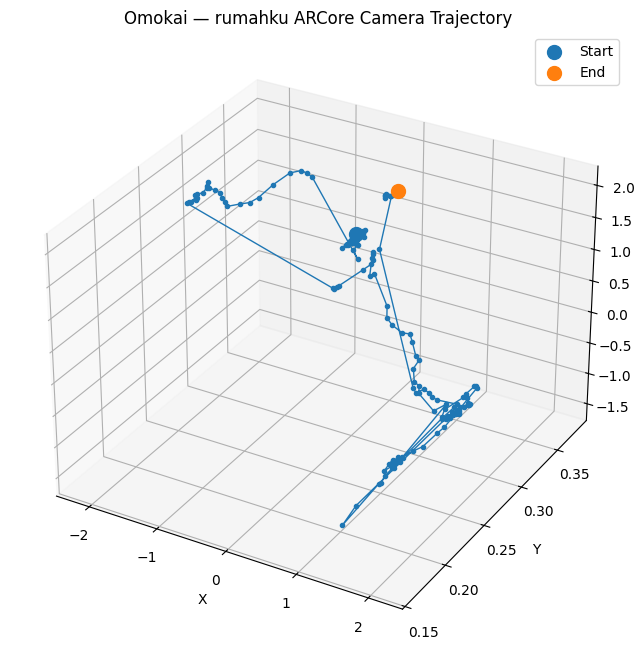

In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

ax.plot(
    poses["x"],
    poses["y"],
    poses["z"],
    marker=".",
    linewidth=1,
)

ax.scatter(
    poses["x"].iloc[0],
    poses["y"].iloc[0],
    poses["z"].iloc[0],
    s=100,
    label="Start",
)

ax.scatter(
    poses["x"].iloc[-1],
    poses["y"].iloc[-1],
    poses["z"].iloc[-1],
    s=100,
    label="End",
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Omokai — rumahku ARCore Camera Trajectory")
ax.legend()

plt.show()

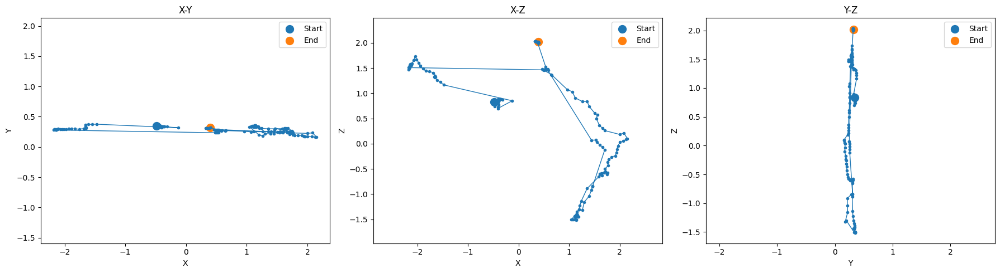

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# X-Y
axes[0].plot(poses["x"], poses["y"], marker=".", linewidth=1)
axes[0].scatter(
    poses["x"].iloc[0],
    poses["y"].iloc[0],
    s=100,
    label="Start",
)
axes[0].scatter(
    poses["x"].iloc[-1],
    poses["y"].iloc[-1],
    s=100,
    label="End",
)
axes[0].set_xlabel("X")
axes[0].set_ylabel("Y")
axes[0].set_title("X-Y")
axes[0].axis("equal")
axes[0].legend()

# X-Z
axes[1].plot(poses["x"], poses["z"], marker=".", linewidth=1)
axes[1].scatter(
    poses["x"].iloc[0],
    poses["z"].iloc[0],
    s=100,
    label="Start",
)
axes[1].scatter(
    poses["x"].iloc[-1],
    poses["z"].iloc[-1],
    s=100,
    label="End",
)
axes[1].set_xlabel("X")
axes[1].set_ylabel("Z")
axes[1].set_title("X-Z")
axes[1].axis("equal")
axes[1].legend()

# Y-Z
axes[2].plot(poses["y"], poses["z"], marker=".", linewidth=1)
axes[2].scatter(
    poses["y"].iloc[0],
    poses["z"].iloc[0],
    s=100,
    label="Start",
)
axes[2].scatter(
    poses["y"].iloc[-1],
    poses["z"].iloc[-1],
    s=100,
    label="End",
)
axes[2].set_xlabel("Y")
axes[2].set_ylabel("Z")
axes[2].set_title("Y-Z")
axes[2].axis("equal")
axes[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

xyz = poses[["x", "y", "z"]].to_numpy()

step_distances = np.linalg.norm(
    xyz[1:] - xyz[:-1],
    axis=1
)

print("Mean frame-to-frame movement:", step_distances.mean())
print("Median frame-to-frame movement:", np.median(step_distances))
print("Maximum frame-to-frame movement:", step_distances.max())

print("\nLargest 10 frame jumps:")

largest = np.argsort(step_distances)[-10:][::-1]

for i in largest:
    print(
        f"Frame {i} -> {i+1}: "
        f"{step_distances[i]:.4f}"
    )

Mean frame-to-frame movement: 0.10783848288258358
Median frame-to-frame movement: 0.04401023985180421
Maximum frame-to-frame movement: 2.6586558099578945

Largest 10 frame jumps:
Frame 56 -> 57: 2.6587
Frame 141 -> 142: 1.7121
Frame 30 -> 31: 1.3891
Frame 135 -> 136: 0.7570
Frame 142 -> 143: 0.5001
Frame 68 -> 69: 0.4190
Frame 105 -> 106: 0.3302
Frame 29 -> 30: 0.3249
Frame 80 -> 81: 0.3078
Frame 127 -> 128: 0.2846


In [ ]:
suspicious = [30, 56, 135, 141]

for i in suspicious:
    print("\n" + "=" * 60)
    print(f"FRAME {i} -> {i+1}")

    for j in [i, i + 1]:
        row = poses.iloc[j]

        print(
            f"Frame {j}: "
            f"{row['image']}  "
            f"position=({row['x']:.3f}, "
            f"{row['y']:.3f}, "
            f"{row['z']:.3f})"
        )


FRAME 30 -> 31
Frame 30: images/000030.jpg  position=(-0.123, 0.318, 0.852)
Frame 31: images/000031.jpg  position=(-1.475, 0.376, 1.166)

FRAME 56 -> 57
Frame 56: images/000056.jpg  position=(-2.176, 0.280, 1.510)
Frame 57: images/000057.jpg  position=(0.481, 0.235, 1.466)

FRAME 135 -> 136
Frame 135: images/000135.jpg  position=(1.469, 0.306, -0.837)
Frame 136: images/000136.jpg  position=(1.706, 0.257, -0.119)

FRAME 141 -> 142
Frame 141: images/000141.jpg  position=(1.445, 0.250, 0.070)
Frame 142: images/000142.jpg  position=(0.539, 0.287, 1.523)


In [ ]:
import shutil
from pathlib import Path

DATASET = Path(
    "/content/drive/MyDrive/Omokai/digital_twin/room_001"
)

LOCAL_DATASET = Path("/content/room_001")

print("Drive dataset exists:", DATASET.exists())

if not DATASET.exists():
    raise FileNotFoundError(
        "The Google Drive dataset was not found. "
        "Check that Drive is still mounted and the path is correct."
    )

if LOCAL_DATASET.exists():
    shutil.rmtree(LOCAL_DATASET)

print("Copying dataset from Google Drive to Colab...")
shutil.copytree(DATASET, LOCAL_DATASET)

image_count = len(
    list((LOCAL_DATASET / "images").glob("*.jpg"))
)

print("Local dataset:", LOCAL_DATASET)
print("Images copied:", image_count)
print("transforms.json exists:",
      (LOCAL_DATASET / "transforms.json").exists())

Drive dataset exists: True
Copying dataset from Google Drive to Colab...
Local dataset: /content/room_001
Images copied: 152
transforms.json exists: True


In [ ]:
print("Local dataset exists:", LOCAL_DATASET.exists())
print(
    "Images directory exists:",
    (LOCAL_DATASET / "images").exists()
)
print(
    "Number of images:",
    len(list((LOCAL_DATASET / "images").glob("*.jpg")))
)

Local dataset exists: True
Images directory exists: True
Number of images: 152


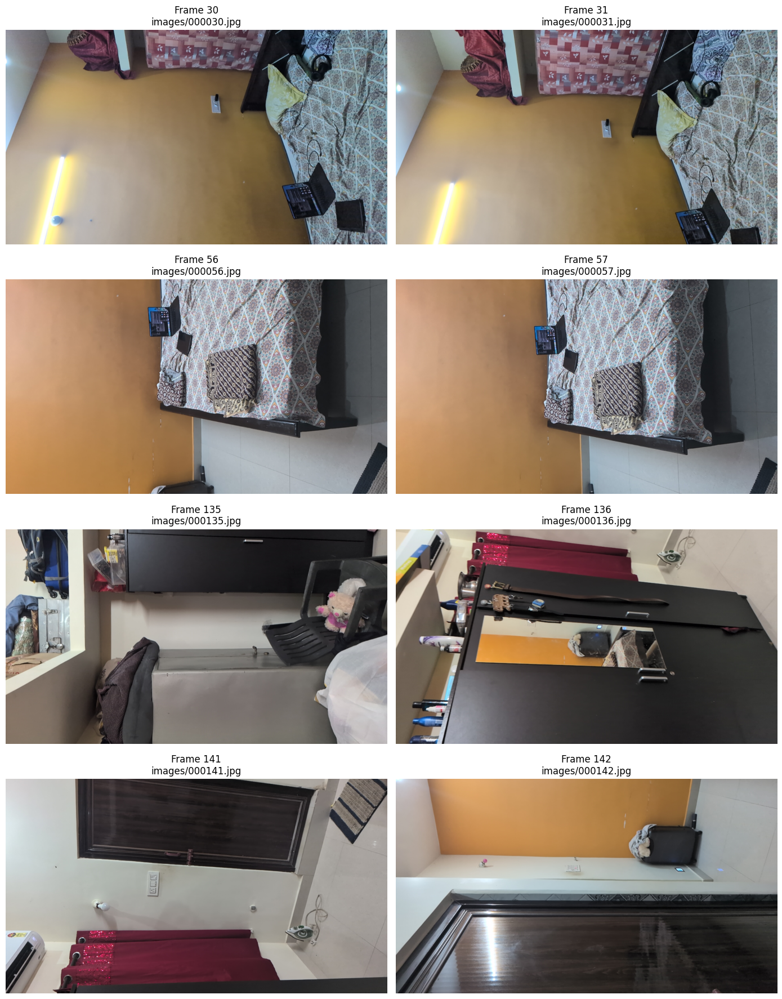

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

pairs = [
    (30, 31),
    (56, 57),
    (135, 136),
    (141, 142),
]

fig, axes = plt.subplots(
    len(pairs),
    2,
    figsize=(14, 18)
)

for row_idx, (a, b) in enumerate(pairs):

    for col_idx, frame_idx in enumerate([a, b]):

        image_name = poses.iloc[frame_idx]["image"]
        image_path = LOCAL_DATASET / image_name

        img = Image.open(image_path)

        axes[row_idx, col_idx].imshow(img)
        axes[row_idx, col_idx].set_title(
            f"Frame {frame_idx}\n{image_name}"
        )
        axes[row_idx, col_idx].axis("off")

plt.tight_layout()
plt.show()

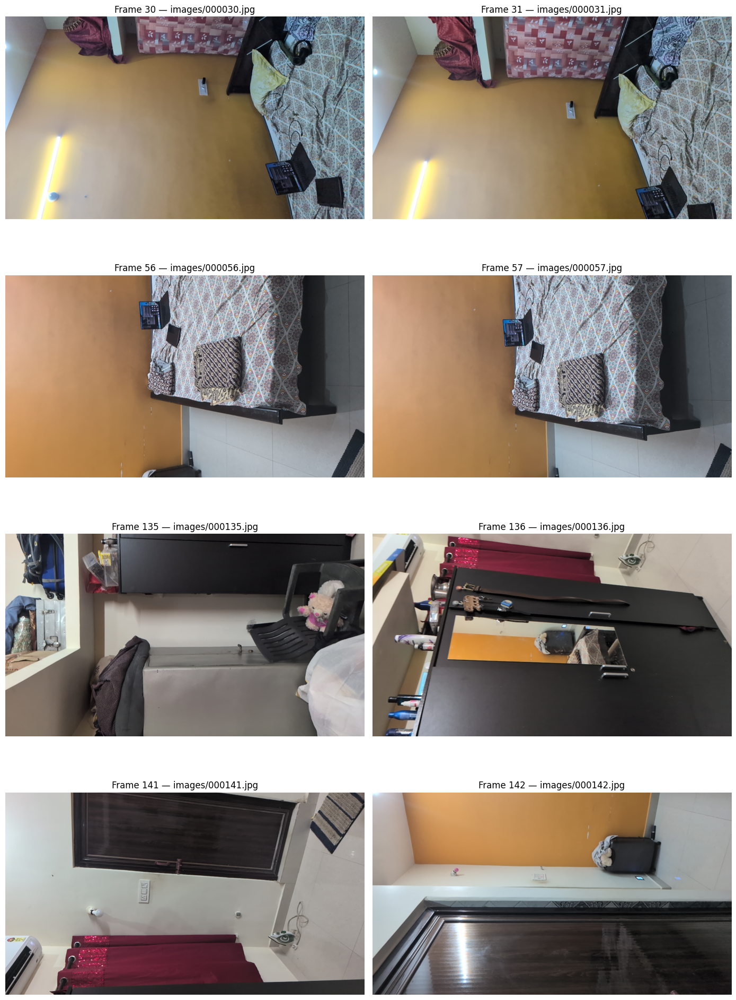

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

pairs = [
    (30, 31),
    (56, 57),
    (135, 136),
    (141, 142),
]

fig, axes = plt.subplots(
    4, 2,
    figsize=(14, 20)
)

for row_idx, (a, b) in enumerate(pairs):

    for col_idx, frame_idx in enumerate([a, b]):

        image_name = poses.iloc[frame_idx]["image"]
        image_path = LOCAL_DATASET / image_name

        img = Image.open(image_path)

        axes[row_idx, col_idx].imshow(img)
        axes[row_idx, col_idx].set_title(
            f"Frame {frame_idx} — {image_name}"
        )
        axes[row_idx, col_idx].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from hloc import extract_features

print("Available feature configurations:")
for name in extract_features.confs.keys():
    print(" -", name)

Available feature configurations:
 - superpoint_aachen
 - superpoint_max
 - superpoint_inloc
 - r2d2
 - d2net-ss
 - sift
 - sosnet
 - disk
 - aliked-n16
 - dir
 - netvlad
 - openibl
 - megaloc


In [ ]:
from hloc import extract_features
from pathlib import Path

OUTPUTS = Path("/content/room_001/hloc")
OUTPUTS.mkdir(parents=True, exist_ok=True)

feature_conf = extract_features.confs["superpoint_max"]

print("Using:", "superpoint_max")
print("Output:", feature_conf["output"])
print("Images:", IMAGES)
print("Export:", OUTPUTS)

Using: superpoint_max
Output: feats-superpoint-n4096-rmax1600
Images: /content/drive/MyDrive/Omokai/digital_twin/room_001/images
Export: /content/room_001/hloc


In [ ]:
from hloc import extract_features
from pathlib import Path

feature_conf = extract_features.confs["superpoint_max"]

feature_path = OUTPUTS / (feature_conf["output"] + ".h5")

print("Starting SuperPoint extraction...")
print("Images:", IMAGES)
print("Output:", feature_path)

extract_features.main(
    feature_conf,
    IMAGES,
    image_list=None,
    feature_path=feature_path,
)

print("Feature extraction complete.")
print("Saved to:", feature_path)

[2026/10/06 04:47:20 hloc INFO] Extracting local features with configuration:
{'model': {'max_keypoints': 4096, 'name': 'superpoint', 'nms_radius': 3},
 'output': 'feats-superpoint-n4096-rmax1600',
 'preprocessing': {'grayscale': True, 'resize_force': True, 'resize_max': 1600}}
[2026/10/06 04:47:20 hloc INFO] Found 152 images in root /content/drive/MyDrive/Omokai/digital_twin/room_001/images.


Starting SuperPoint extraction...
Images: /content/drive/MyDrive/Omokai/digital_twin/room_001/images
Output: /content/room_001/hloc/feats-superpoint-n4096-rmax1600.h5
Loaded SuperPoint model


100%|██████████| 152/152 [00:25<00:00,  5.93it/s]
[2026/10/06 04:47:46 hloc INFO] Finished exporting features.


Feature extraction complete.
Saved to: /content/room_001/hloc/feats-superpoint-n4096-rmax1600.h5


In [ ]:
import h5py

feature_path = OUTPUTS / (feature_conf["output"] + ".h5")

with h5py.File(feature_path, "r") as f:
    print("Number of images:", len(f.keys()))

    first_image = sorted(f.keys())[0]
    print("First image:", first_image)

    print("Stored datasets:")
    for key in f[first_image].keys():
        obj = f[first_image][key]
        print(f"  {key}: shape={obj.shape}, dtype={obj.dtype}")

    print("\nFirst image keypoints:")
    if "keypoints" in f[first_image]:
        print("Keypoints:", f[first_image]["keypoints"].shape)

Number of images: 152
First image: 000000.jpg
Stored datasets:
  descriptors: shape=(256, 1133), dtype=float16
  image_size: shape=(2,), dtype=int64
  keypoints: shape=(1133, 2), dtype=float16
  scores: shape=(1133,), dtype=float16

First image keypoints:
Keypoints: (1133, 2)


In [ ]:
from hloc import match_features

match_conf = match_features.confs["superglue"]

print("Using matcher:")
print(match_conf)

Using matcher:
{'output': 'matches-superglue', 'model': {'name': 'superglue', 'weights': 'outdoor', 'sinkhorn_iterations': 50}}


In [ ]:
from hloc import pairs_from_retrieval

pairs_path = OUTPUTS / "pairs-netvlad.txt"

print("Generating image pairs...")

pairs_from_retrieval.main(
    descriptors="netvlad",
    num_matched=10,
    output=pairs_path,
    db_dir=IMAGES,
    query_prefix="",
    overwrite=True,
)

print("Pairs saved to:", pairs_path)

Generating image pairs...


TypeError: main() got an unexpected keyword argument 'db_dir'

In [ ]:
import inspect
from hloc import pairs_from_retrieval

print(inspect.signature(pairs_from_retrieval.main))

(descriptors, output, num_matched, query_prefix=None, query_list=None, db_prefix=None, db_list=None, db_model=None, db_descriptors=None)


In [ ]:
print(inspect.getsource(pairs_from_retrieval.main))

def main(
    descriptors,
    output,
    num_matched,
    query_prefix=None,
    query_list=None,
    db_prefix=None,
    db_list=None,
    db_model=None,
    db_descriptors=None,
):
    logger.info("Extracting image pairs from a retrieval database.")

    # We handle multiple reference feature files.
    # We only assume that names are unique among them and map names to files.
    if db_descriptors is None:
        db_descriptors = descriptors
    if isinstance(db_descriptors, (Path, str)):
        db_descriptors = [db_descriptors]
    name2db = {n: i for i, p in enumerate(db_descriptors) for n in list_h5_names(p)}
    db_names_h5 = list(name2db.keys())
    query_names_h5 = list_h5_names(descriptors)

    if db_model:
        images = read_images_binary(db_model / "images.bin")
        db_names = [i.name for i in images.values()]
    else:
        db_names = parse_names(db_prefix, db_list, db_names_h5)
    if len(db_names) == 0:
        raise ValueError("Could not find any database 

In [ ]:
from hloc import extract_features

retrieval_conf = extract_features.confs["netvlad"]

print("Using retrieval configuration:")
print(retrieval_conf)

retrieval_path = OUTPUTS / (retrieval_conf["output"] + ".h5")

print("Output:", retrieval_path)

extract_features.main(
    retrieval_conf,
    IMAGES,
    image_list=None,
    feature_path=retrieval_path,
)

print("NetVLAD extraction complete.")

[2026/10/06 04:51:31 hloc INFO] Extracting local features with configuration:
{'model': {'name': 'netvlad'},
 'output': 'global-feats-netvlad',
 'preprocessing': {'resize_max': 1024}}
[2026/10/06 04:51:31 hloc INFO] Found 152 images in root /content/drive/MyDrive/Omokai/digital_twin/room_001/images.


Using retrieval configuration:
{'output': 'global-feats-netvlad', 'model': {'name': 'netvlad'}, 'preprocessing': {'resize_max': 1024}}
Output: /content/room_001/hloc/global-feats-netvlad.h5


HTTPError: HTTP Error 403: Forbidden

In [ ]:
import inspect
from hloc import extractors

print(inspect.getsource(extractors.NetVLAD))

AttributeError: module 'hloc.extractors' has no attribute 'NetVLAD'

In [ ]:
import inspect
import hloc.extractors as extractors

print("Extractor module:", extractors.__file__)
print("\nAvailable names containing 'vlad':")
print([name for name in dir(extractors) if "vlad" in name.lower()])

Extractor module: /content/Hierarchical-Localization/hloc/extractors/__init__.py

Available names containing 'vlad':
['netvlad']


In [ ]:
from hloc import extract_features

print("\nNetVLAD configuration:")
print(extract_features.confs["netvlad"])


NetVLAD configuration:
{'output': 'global-feats-netvlad', 'model': {'name': 'netvlad'}, 'preprocessing': {'resize_max': 1024}}


In [ ]:
from pathlib import Path

pairs_path = OUTPUTS / "pairs-sequential.txt"

image_names = sorted(
    p.name for p in IMAGES.glob("*.jpg")
)

pairs = []

# Match each image with nearby frames.
# A window of 5 gives several overlapping neighbors.
window = 5

for i, name_i in enumerate(image_names):
    for j in range(i + 1, min(i + window + 1, len(image_names))):
        name_j = image_names[j]
        pairs.append((name_i, name_j))

with open(pairs_path, "w") as f:
    for a, b in pairs:
        f.write(f"{a} {b}\n")

print("Images:", len(image_names))
print("Pairs:", len(pairs))
print("Saved:", pairs_path)

print("\nFirst 10 pairs:")
for pair in pairs[:10]:
    print(pair)

Images: 152
Pairs: 745
Saved: /content/room_001/hloc/pairs-sequential.txt

First 10 pairs:
('000000.jpg', '000001.jpg')
('000000.jpg', '000002.jpg')
('000000.jpg', '000003.jpg')
('000000.jpg', '000004.jpg')
('000000.jpg', '000005.jpg')
('000001.jpg', '000002.jpg')
('000001.jpg', '000003.jpg')
('000001.jpg', '000004.jpg')
('000001.jpg', '000005.jpg')
('000001.jpg', '000006.jpg')


In [ ]:
from hloc import match_features

match_conf = match_features.confs["superglue"]

match_path = OUTPUTS / (match_conf["output"] + ".h5")

print("Starting SuperGlue matching...")
print("Pairs:", pairs_path)
print("Features:", feature_path)
print("Output:", match_path)

match_features.main(
    match_conf,
    pairs=pairs_path,
    features=feature_path,
    export_dir=OUTPUTS,
    matches=match_path,
    overwrite=True,
)

print("Feature matching complete.")
print("Saved to:", match_path)

[2026/10/06 04:55:45 hloc INFO] Matching local features with configuration:
{'model': {'name': 'superglue',
           'sinkhorn_iterations': 50,
           'weights': 'outdoor'},
 'output': 'matches-superglue'}


Starting SuperGlue matching...
Pairs: /content/room_001/hloc/pairs-sequential.txt
Features: /content/room_001/hloc/feats-superpoint-n4096-rmax1600.h5
Output: /content/room_001/hloc/matches-superglue.h5
Loaded SuperGlue model ("outdoor" weights)


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 5 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
  0%|          | 0/745 [00:00<?, ?it/s]/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 5 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
100

Feature matching complete.
Saved to: /content/room_001/hloc/matches-superglue.h5


In [ ]:
import h5py
import numpy as np

with h5py.File(match_path, "r") as f:
    pair_names = list(f.keys())

    counts = []

    for pair in pair_names:
        matches = f[pair]["matches0"][:]
        valid = np.sum(matches > -1)
        counts.append(valid)

counts = np.array(counts)

print("Matched pairs:", len(counts))
print("Minimum matches:", counts.min())
print("Median matches:", np.median(counts))
print("Mean matches:", counts.mean())
print("Maximum matches:", counts.max())

print("\nPairs with >= 50 matches:", np.sum(counts >= 50))
print("Pairs with >= 100 matches:", np.sum(counts >= 100))
print("Pairs with >= 200 matches:", np.sum(counts >= 200))

KeyError: "Unable to synchronously open object (object 'matches0' doesn't exist)"

In [ ]:
import h5py

with h5py.File(match_path, "r") as f:
    print("Top-level entries:", len(f.keys()))

    for i, key in enumerate(f.keys()):
        print(f"\nEntry {i}: {key}")
        print("Type:", type(f[key]))

        if hasattr(f[key], "keys"):
            print("Datasets/groups:", list(f[key].keys()))

        if i >= 2:
            break

Top-level entries: 151

Entry 0: 000000.jpg
Type: <class 'h5py._hl.group.Group'>
Datasets/groups: ['000001.jpg', '000002.jpg', '000003.jpg', '000004.jpg', '000005.jpg']

Entry 1: 000001.jpg
Type: <class 'h5py._hl.group.Group'>
Datasets/groups: ['000002.jpg', '000003.jpg', '000004.jpg', '000005.jpg', '000006.jpg']

Entry 2: 000002.jpg
Type: <class 'h5py._hl.group.Group'>
Datasets/groups: ['000003.jpg', '000004.jpg', '000005.jpg', '000006.jpg', '000007.jpg']


In [ ]:
import h5py

with h5py.File(match_path, "r") as f:
    pair = f["000000.jpg"]["000001.jpg"]

    print("Datasets in 000000.jpg → 000001.jpg:")
    for key in pair.keys():
        obj = pair[key]
        print(f"  {key}: shape={obj.shape}, dtype={obj.dtype}")

Datasets in 000000.jpg → 000001.jpg:
  matches0: shape=(1133,), dtype=int16
  matching_scores0: shape=(1133,), dtype=float16


In [ ]:
import h5py
import numpy as np

counts = []

with h5py.File(match_path, "r") as f:
    for image1 in f.keys():
        for image2 in f[image1].keys():
            matches0 = f[image1][image2]["matches0"][:]
            valid = np.sum(matches0 > -1)
            counts.append(valid)

counts = np.array(counts)

print("Matched pairs:", len(counts))
print("Minimum matches:", counts.min())
print("Median matches:", np.median(counts))
print("Mean matches:", counts.mean())
print("Maximum matches:", counts.max())

print("\nPairs with >= 50 matches:", np.sum(counts >= 50))
print("Pairs with >= 100 matches:", np.sum(counts >= 100))
print("Pairs with >= 200 matches:", np.sum(counts >= 200))

Matched pairs: 745
Minimum matches: 1
Median matches: 693.0
Mean matches: 800.4630872483222
Maximum matches: 2761

Pairs with >= 50 matches: 646
Pairs with >= 100 matches: 632
Pairs with >= 200 matches: 612


In [ ]:
from hloc import reconstruction
import inspect

print(inspect.signature(reconstruction.main))

(sfm_dir: pathlib._local.Path, image_dir: pathlib._local.Path, pairs: pathlib._local.Path, features: pathlib._local.Path, matches: pathlib._local.Path, camera_mode: pycolmap._core.CameraMode = CameraMode.AUTO, verbose: bool = False, skip_geometric_verification: bool = False, min_match_score: Optional[float] = None, image_list: Optional[List[str]] = None, image_options: Optional[Dict[str, Any]] = None, mapper_options: Optional[Dict[str, Any]] = None) -> pycolmap._core.Reconstruction


In [ ]:
import json
from pathlib import Path

with open(TRANSFORMS) as f:
    transforms = json.load(f)

camera = {
    "model": "PINHOLE",
    "width": transforms["w"],
    "height": transforms["h"],
    "params": [
        transforms["fl_x"],
        transforms["fl_y"],
        transforms["cx"],
        transforms["cy"],
    ],
}

print("Camera model:", camera["model"])
print("Resolution:", camera["width"], "x", camera["height"])
print("Parameters:", camera["params"])

Camera model: PINHOLE
Resolution: 1920 x 1080
Parameters: [1382.9617919921875, 1379.8028564453125, 962.8452758789062, 545.3877563476562]


In [ ]:
from hloc import reconstruction
from pathlib import Path

SFM_DIR = OUTPUTS / "sfm"

SFM_DIR.mkdir(parents=True, exist_ok=True)

print("Starting SfM reconstruction...")
print("Images:", IMAGES)
print("Pairs:", pairs_path)
print("Features:", feature_path)
print("Matches:", match_path)
print("Output:", SFM_DIR)

model = reconstruction.main(
    sfm_dir=SFM_DIR,
    image_dir=IMAGES,
    pairs=pairs_path,
    features=feature_path,
    matches=match_path,
    camera_mode="AUTO",
    verbose=True,
    skip_geometric_verification=False,
    image_options={
        "camera_model": "PINHOLE",
        "camera_params": camera["params"],
    },
)

print("\nSfM reconstruction complete.")
print(model)

[2026/10/06 05:03:46 hloc INFO] Writing COLMAP logs to /content/room_001/hloc/sfm/colmap.LOG.*
[2026/10/06 05:03:46 hloc INFO] Creating an empty database...
[2026/10/06 05:03:46 hloc INFO] Importing images into the database...


Starting SfM reconstruction...
Images: /content/drive/MyDrive/Omokai/digital_twin/room_001/images
Pairs: /content/room_001/hloc/pairs-sequential.txt
Features: /content/room_001/hloc/feats-superpoint-n4096-rmax1600.h5
Matches: /content/room_001/hloc/matches-superglue.h5
Output: /content/room_001/hloc/sfm


TypeError: import_images(): incompatible function arguments. The following argument types are supported:
    1. (database_path: os.PathLike | str | bytes, image_path: os.PathLike | str | bytes, camera_mode: pycolmap._core.CameraMode = CameraMode.AUTO, image_names: collections.abc.Sequence[str] = [], options: pycolmap._core.ImageReaderOptions = ImageReaderOptions()) -> None

Invoked with: PosixPath('/content/room_001/hloc/sfm/database.db'), PosixPath('/content/drive/MyDrive/Omokai/digital_twin/room_001/images'), 'AUTO'; kwargs: image_names=[], options={'camera_model': 'PINHOLE', 'camera_params': [1382.9617919921875, 1379.8028564453125, 962.8452758789062, 545.3877563476562]}

In [ ]:
import pycolmap
import inspect

print("pycolmap version:", pycolmap.__version__)
print("\nImageReaderOptions:")
print(pycolmap.ImageReaderOptions)

print("\nAvailable CameraMode values:")
print(list(pycolmap.CameraMode))

pycolmap version: 4.2.1

ImageReaderOptions:
<class 'pycolmap._core.ImageReaderOptions'>

Available CameraMode values:


TypeError: 'pybind11_type' object is not iterable

In [ ]:
from hloc import reconstruction

print("\nHLoc import_images signature:")
print(inspect.signature(reconstruction.import_images))


HLoc import_images signature:
(image_dir: pathlib._local.Path, database_path: pathlib._local.Path, camera_mode: pycolmap._core.CameraMode, image_list: Optional[List[str]] = None, options: Optional[Dict[str, Any]] = None)


In [ ]:
import pycolmap

opts = pycolmap.ImageReaderOptions()

print(opts)
print("\nAttributes:")
print([x for x in dir(opts) if not x.startswith("_")])

ImageReaderOptions(camera_model='SIMPLE_RADIAL', mask_path=., existing_camera_id=-1, camera_params='', default_focal_length_factor=1.2, camera_mask_path=.)

Attributes:
['camera_mask_path', 'camera_model', 'camera_params', 'check', 'default_focal_length_factor', 'existing_camera_id', 'mask_path', 'mergedict', 'summary', 'todict']


In [ ]:
import pycolmap

image_options = pycolmap.ImageReaderOptions()

image_options.camera_model = "PINHOLE"
image_options.camera_params = ",".join(
    str(x) for x in camera["params"]
)

print(image_options)

ImageReaderOptions(camera_model='PINHOLE', mask_path=., existing_camera_id=-1, camera_params='1382.9617919921875,1379.8028564453125,962.8452758789062,545.3877563476562', default_focal_length_factor=1.2, camera_mask_path=.)


In [ ]:
import pycolmap

database_path = SFM_DIR / "database.db"

# Remove any incomplete database/file if present.
if database_path.exists():
    database_path.unlink()

print("Creating empty COLMAP database...")

pycolmap.Database.open(database_path).close()

print("Database exists:", database_path.exists())

image_options = pycolmap.ImageReaderOptions()
image_options.camera_model = "PINHOLE"
image_options.camera_params = ",".join(
    str(x) for x in camera["params"]
)

print("Importing images...")

pycolmap.import_images(
    database_path,
    IMAGES,
    camera_mode=pycolmap.CameraMode.AUTO,
    image_names=[],
    options=image_options,
)

print("Image import complete.")

Creating empty COLMAP database...
Database exists: True
Importing images...
Image import complete.


In [ ]:
import pycolmap
import inspect

print("Available functions containing 'match':")
print([name for name in dir(pycolmap) if "match" in name.lower()])

print("\nDatabase methods containing 'match':")
print([name for name in dir(pycolmap.Database) if "match" in name.lower()])

Available functions containing 'match':
['ExistingMatchedPairingOptions', 'FeatureMatch', 'FeatureMatcher', 'FeatureMatcherType', 'FeatureMatches', 'FeatureMatchingOptions', 'PatchMatchOptions', 'SiftMatchingOptions', 'SyntheticDatasetMatchConfig', 'match_exhaustive', 'match_image_pairs', 'match_sequential', 'match_spatial', 'match_vocabtree', 'matches_from_matrix', 'matches_to_matrix', 'patch_match_stereo', 'verify_matches']

Database methods containing 'match':
['clear_matches', 'delete_inlier_matches', 'delete_matches', 'exists_matches', 'num_inlier_matches', 'num_matched_image_pairs', 'num_matches', 'read_all_matches', 'read_matches', 'read_num_matches', 'write_matches']


In [ ]:
import pycolmap
import inspect

print(inspect.signature(pycolmap.Database.write_matches))
print(inspect.signature(pycolmap.verify_matches))


ValueError: no signature found for builtin <instancemethod write_matches at 0x7f8faaf4d390>

In [ ]:
import pycolmap

help(pycolmap.Database.write_matches)

Help on instancemethod in module pycolmap._core:

write_matches(...)
    write_matches(self: pycolmap._core.Database, image_id1: typing.SupportsInt | typing.SupportsIndex, image_id2: typing.SupportsInt | typing.SupportsIndex, matches: typing.Annotated[numpy.typing.ArrayLike, numpy.uint32, "[m, 2]"]) -> None



In [ ]:
help(pycolmap.verify_matches)

Help on built-in function verify_matches in module pycolmap._core:

verify_matches(...) method of pybind11_builtins.pybind11_detail_function_record_v1_system_libstdcpp_gxx_abi_1xxx_use_cxx11_abi_1 instance
    verify_matches(database_path: os.PathLike | str | bytes, pairs_path: os.PathLike | str | bytes, options: pycolmap._core.TwoViewGeometryOptions = TwoViewGeometryOptions(), cancellation_token: pycolmap._core.CancellationToken = None) -> None

    Run geometric verification of the matches



In [ ]:
import pycolmap

db = pycolmap.Database.open(database_path)

print("Number of images:", db.num_images())

print("\nImages:")
for image in db.read_all_images():
    print(image.image_id, image.name)

db.close()

Number of images: 152

Images:
1 000000.jpg
2 000001.jpg
3 000002.jpg
4 000003.jpg
5 000004.jpg
6 000005.jpg
7 000006.jpg
8 000007.jpg
9 000008.jpg
10 000009.jpg
11 000010.jpg
12 000011.jpg
13 000012.jpg
14 000013.jpg
15 000014.jpg
16 000015.jpg
17 000016.jpg
18 000017.jpg
19 000018.jpg
20 000019.jpg
21 000020.jpg
22 000021.jpg
23 000022.jpg
24 000023.jpg
25 000024.jpg
26 000025.jpg
27 000026.jpg
28 000027.jpg
29 000028.jpg
30 000029.jpg
31 000030.jpg
32 000031.jpg
33 000032.jpg
34 000033.jpg
35 000034.jpg
36 000035.jpg
37 000036.jpg
38 000037.jpg
39 000038.jpg
40 000039.jpg
41 000040.jpg
42 000041.jpg
43 000042.jpg
44 000043.jpg
45 000044.jpg
46 000045.jpg
47 000046.jpg
48 000047.jpg
49 000048.jpg
50 000049.jpg
51 000050.jpg
52 000051.jpg
53 000052.jpg
54 000053.jpg
55 000054.jpg
56 000055.jpg
57 000056.jpg
58 000057.jpg
59 000058.jpg
60 000059.jpg
61 000060.jpg
62 000061.jpg
63 000062.jpg
64 000063.jpg
65 000064.jpg
66 000065.jpg
67 000066.jpg
68 000067.jpg
69 000068.jpg
70 000069.jp

In [ ]:
import h5py
import numpy as np
import pycolmap

# Build filename -> COLMAP image ID mapping
db = pycolmap.Database.open(database_path)

name_to_id = {
    image.name: image.image_id
    for image in db.read_all_images()
}

print("Images in database:", len(name_to_id))

# Import SuperGlue matches
written_pairs = 0
written_matches = 0

with h5py.File(match_path, "r") as f:
    for image1 in f.keys():
        id1 = name_to_id[image1]

        for image2 in f[image1].keys():
            id2 = name_to_id[image2]

            matches0 = f[image1][image2]["matches0"][:]

            # Convert HLoc matches0 into COLMAP N x 2 format.
            valid = np.where(matches0 >= 0)[0]

            if len(valid) == 0:
                continue

            matches = np.column_stack([
                valid,
                matches0[valid],
            ]).astype(np.uint32)

            db.write_matches(id1, id2, matches)

            written_pairs += 1
            written_matches += len(matches)

db.close()

print("Match pairs written:", written_pairs)
print("Total correspondences written:", written_matches)

Images in database: 152
Match pairs written: 745
Total correspondences written: 596345


In [ ]:
import pycolmap

# Close any existing database connection before verification
try:
    db.close()
except:
    pass

print("Running geometric verification...")
print("This may take a few minutes.")

pycolmap.verify_matches(
    database_path,
    pairs_path,
)

print("Geometric verification complete.")

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import shutil

# Your permanent copy in Google Drive
DATASET = Path("/content/drive/MyDrive/Omokai/digital_twin/room_001")

# Temporary working copy for this Colab session
LOCAL_DATASET = Path("/content/room_001")

# Remove old incomplete copy if it exists
if LOCAL_DATASET.exists():
    shutil.rmtree(LOCAL_DATASET)

# Restore everything from Drive
shutil.copytree(DATASET, LOCAL_DATASET)

# Define paths again
IMAGES = LOCAL_DATASET / "images"
TRANSFORMS = LOCAL_DATASET / "transforms.json"
OUTPUTS = LOCAL_DATASET / "hloc"

print("Dataset restored.")
print("Images:", len(list(IMAGES.glob("*.jpg"))))
print("transforms.json:", TRANSFORMS.exists())
print("HLoc directory:", OUTPUTS.exists())

if OUTPUTS.exists():
    print("\nHLoc files:")
    for p in sorted(OUTPUTS.iterdir()):
        print(" ", p.name)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset restored.
Images: 152
transforms.json: True
HLoc directory: False


In [ ]:
from pathlib import Path

OUTPUTS = LOCAL_DATASET / "hloc"
OUTPUTS.mkdir(parents=True, exist_ok=True)

# Get image names
image_names = sorted(p.name for p in IMAGES.glob("*.jpg"))

# Create sequential pairs
pairs_path = OUTPUTS / "pairs-sequential.txt"

pairs = []
window = 5

for i, name_i in enumerate(image_names):
    for j in range(i + 1, min(i + window + 1, len(image_names))):
        pairs.append((name_i, image_names[j]))

with open(pairs_path, "w") as f:
    for a, b in pairs:
        f.write(f"{a} {b}\n")

print("Images:", len(image_names))
print("Sequential pairs:", len(pairs))
print("Saved:", pairs_path)

Images: 152
Sequential pairs: 745
Saved: /content/room_001/hloc/pairs-sequential.txt


In [ ]:
from hloc import extract_features

feature_conf = extract_features.confs["superpoint_max"]

feature_path = OUTPUTS / (feature_conf["output"] + ".h5")

print("Using:", feature_conf["output"])
print("Images:", IMAGES)
print("Output:", feature_path)

extract_features.main(
    feature_conf,
    IMAGES,
    image_list=None,
    feature_path=feature_path,
)

print("\nSuperPoint feature extraction complete.")
print("Saved to:", feature_path)

[2026/10/06 05:16:42 hloc INFO] Extracting local features with configuration:
{'model': {'max_keypoints': 4096, 'name': 'superpoint', 'nms_radius': 3},
 'output': 'feats-superpoint-n4096-rmax1600',
 'preprocessing': {'grayscale': True, 'resize_force': True, 'resize_max': 1600}}
[2026/10/06 05:16:42 hloc INFO] Found 152 images in root /content/room_001/images.


Using: feats-superpoint-n4096-rmax1600
Images: /content/room_001/images
Output: /content/room_001/hloc/feats-superpoint-n4096-rmax1600.h5
Loaded SuperPoint model


100%|██████████| 152/152 [00:22<00:00,  6.62it/s]
[2026/10/06 05:17:06 hloc INFO] Finished exporting features.



SuperPoint feature extraction complete.
Saved to: /content/room_001/hloc/feats-superpoint-n4096-rmax1600.h5


In [ ]:
from hloc import match_features

match_conf = match_features.confs["superglue"]

feature_path = OUTPUTS / "feats-superpoint-n4096-rmax1600.h5"
pairs_path = OUTPUTS / "pairs-sequential.txt"
match_path = OUTPUTS / "matches-superglue.h5"

print("Using:", match_conf)
print("Pairs:", pairs_path)
print("Features:", feature_path)
print("Output:", match_path)

match_features.main(
    match_conf,
    pairs=pairs_path,
    features=feature_path,
    export_dir=OUTPUTS,
    matches=match_path,
    overwrite=True,
)

print("\nSuperGlue matching complete.")
print("Saved to:", match_path)

[2026/10/06 05:17:42 hloc INFO] Matching local features with configuration:
{'model': {'name': 'superglue',
           'sinkhorn_iterations': 50,
           'weights': 'outdoor'},
 'output': 'matches-superglue'}


Using: {'output': 'matches-superglue', 'model': {'name': 'superglue', 'weights': 'outdoor', 'sinkhorn_iterations': 50}}
Pairs: /content/room_001/hloc/pairs-sequential.txt
Features: /content/room_001/hloc/feats-superpoint-n4096-rmax1600.h5
Output: /content/room_001/hloc/matches-superglue.h5
Loaded SuperGlue model ("outdoor" weights)


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 5 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
  0%|          | 0/745 [00:00<?, ?it/s]/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 5 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
100


SuperGlue matching complete.
Saved to: /content/room_001/hloc/matches-superglue.h5


In [ ]:
import h5py
import numpy as np

match_path = OUTPUTS / "matches-superglue.h5"

pair_counts = []

with h5py.File(match_path, "r") as f:
    for image1 in f.keys():
        for image2 in f[image1].keys():
            matches0 = f[image1][image2]["matches0"][:]

            valid = np.sum(matches0 >= 0)

            pair_counts.append({
                "image1": image1,
                "image2": image2,
                "matches": int(valid),
            })

counts = np.array([x["matches"] for x in pair_counts])

print("Matched pairs:", len(counts))
print("Minimum matches:", counts.min())
print("Median matches:", np.median(counts))
print("Mean matches:", counts.mean())
print("Maximum matches:", counts.max())

print("\nPairs with >= 50 matches:", np.sum(counts >= 50))
print("Pairs with >= 100 matches:", np.sum(counts >= 100))
print("Pairs with >= 200 matches:", np.sum(counts >= 200))
print("Pairs with >= 500 matches:", np.sum(counts >= 500))

print("\nWeakest 10 pairs:")
for x in sorted(pair_counts, key=lambda x: x["matches"])[:10]:
    print(f"{x['image1']} -> {x['image2']}: {x['matches']} matches")


Matched pairs: 745
Minimum matches: 1
Median matches: 693.0
Mean matches: 800.4630872483222
Maximum matches: 2761

Pairs with >= 50 matches: 646
Pairs with >= 100 matches: 632
Pairs with >= 200 matches: 612
Pairs with >= 500 matches: 489

Weakest 10 pairs:
000140.jpg -> 000142.jpg: 1 matches
000141.jpg -> 000145.jpg: 1 matches
000027.jpg -> 000030.jpg: 2 matches
000029.jpg -> 000030.jpg: 2 matches
000066.jpg -> 000071.jpg: 2 matches
000132.jpg -> 000136.jpg: 2 matches
000141.jpg -> 000144.jpg: 2 matches
000142.jpg -> 000147.jpg: 2 matches
000009.jpg -> 000014.jpg: 3 matches
000065.jpg -> 000070.jpg: 3 matches


In [ ]:
import h5py
import numpy as np
import cv2

image1 = "000050.jpg"
image2 = "000051.jpg"

# Load SuperPoint keypoints and SuperGlue matches
feature_path = OUTPUTS / "feats-superpoint-n4096-rmax1600.h5"
match_path = OUTPUTS / "matches-superglue.h5"

with h5py.File(feature_path, "r") as f:
    kpts1 = f[image1]["keypoints"][:].astype(np.float32)
    kpts2 = f[image2]["keypoints"][:].astype(np.float32)

with h5py.File(match_path, "r") as f:
    matches0 = f[image1][image2]["matches0"][:]

valid = np.where(matches0 >= 0)[0]

pts1 = kpts1[valid]
pts2 = kpts2[matches0[valid].astype(np.int64)]

print("Raw matches:", len(pts1))

# Camera intrinsics from transforms.json
K = np.array([
    [1382.9617919921875, 0, 962.8452758789062],
    [0, 1379.8028564453125, 545.3877563476562],
    [0, 0, 1]
], dtype=np.float64)

# Robustly estimate the essential matrix with RANSAC
E, mask = cv2.findEssentialMat(
    pts1,
    pts2,
    K,
    method=cv2.RANSAC,
    prob=0.999,
    threshold=1.0,
)

if E is None or mask is None:
    print("Could not estimate an essential matrix.")
else:
    inliers = int(mask.sum())
    ratio = inliers / len(pts1)

    print("Geometrically consistent matches:", inliers)
    print("Inlier ratio:", round(ratio, 3))

Raw matches: 1023
Geometrically consistent matches: 664
Inlier ratio: 0.649


In [ ]:
test_pairs = [
    ("000000.jpg", "000001.jpg"),
    ("000020.jpg", "000021.jpg"),
    ("000050.jpg", "000051.jpg"),
    ("000080.jpg", "000081.jpg"),
    ("000110.jpg", "000111.jpg"),
    ("000140.jpg", "000141.jpg"),
]

results = []

with h5py.File(feature_path, "r") as ff, \
     h5py.File(match_path, "r") as mf:

    for image1, image2 in test_pairs:

        kpts1 = ff[image1]["keypoints"][:].astype(np.float32)
        kpts2 = ff[image2]["keypoints"][:].astype(np.float32)

        matches0 = mf[image1][image2]["matches0"][:]

        valid = np.where(matches0 >= 0)[0]

        pts1 = kpts1[valid]
        pts2 = kpts2[matches0[valid].astype(np.int64)]

        if len(pts1) < 8:
            results.append((image1, image2, len(pts1), 0, 0.0))
            continue

        E, mask = cv2.findEssentialMat(
            pts1,
            pts2,
            K,
            method=cv2.RANSAC,
            prob=0.999,
            threshold=1.0,
        )

        if E is None or mask is None:
            results.append((image1, image2, len(pts1), 0, 0.0))
        else:
            inliers = int(mask.sum())
            ratio = inliers / len(pts1)
            results.append((image1, image2, len(pts1), inliers, ratio))

print("Pair                     Raw      Inliers    Ratio")
print("-" * 55)

for image1, image2, raw, inliers, ratio in results:
    print(
        f"{image1} -> {image2}   "
        f"{raw:4d}      {inliers:4d}      {ratio:.3f}"
    )

Pair                     Raw      Inliers    Ratio
-------------------------------------------------------
000000.jpg -> 000001.jpg    713       377      0.529
000020.jpg -> 000021.jpg   2035      1483      0.729
000050.jpg -> 000051.jpg   1023       664      0.649
000080.jpg -> 000081.jpg    936       489      0.522
000110.jpg -> 000111.jpg    793       596      0.752
000140.jpg -> 000141.jpg    487       304      0.624


In [ ]:
import h5py
import numpy as np
import cv2
from pathlib import Path

# Paths
feature_path = OUTPUTS / "feats-superpoint-n4096-rmax1600.h5"
match_path = OUTPUTS / "matches-superglue.h5"
verified_path = OUTPUTS / "matches-verified-opencv.h5"

# Camera intrinsics
K = np.array([
    [1382.9617919921875, 0.0, 962.8452758789062],
    [0.0, 1379.8028564453125, 545.3877563476562],
    [0.0, 0.0, 1.0]
], dtype=np.float64)

# RANSAC settings
RANSAC_THRESHOLD = 1.0
RANSAC_PROB = 0.999

verified_pairs = 0
total_pairs = 0
total_raw_matches = 0
total_inliers = 0

pair_results = []

print("Starting OpenCV geometric verification...")
print("Pairs:", 745)
print()

with h5py.File(feature_path, "r") as ff, \
     h5py.File(match_path, "r") as mf, \
     h5py.File(verified_path, "w") as vf:

    for image1 in mf.keys():

        for image2 in mf[image1].keys():

            total_pairs += 1

            # Load keypoints
            kpts1 = ff[image1]["keypoints"][:].astype(np.float32)
            kpts2 = ff[image2]["keypoints"][:].astype(np.float32)

            # Load SuperGlue matches
            matches0 = mf[image1][image2]["matches0"][:]

            valid = np.where(matches0 >= 0)[0]

            raw_count = len(valid)
            total_raw_matches += raw_count

            # Need at least 5 points for a meaningful essential matrix attempt
            if raw_count < 5:
                pair_results.append(
                    (image1, image2, raw_count, 0, 0.0)
                )
                continue

            pts1 = kpts1[valid]
            pts2 = kpts2[matches0[valid].astype(np.int64)]

            try:
                E, mask = cv2.findEssentialMat(
                    pts1,
                    pts2,
                    K,
                    method=cv2.RANSAC,
                    prob=RANSAC_PROB,
                    threshold=RANSAC_THRESHOLD,
                )
            except cv2.error:
                E = None
                mask = None

            if E is None or mask is None:
                pair_results.append(
                    (image1, image2, raw_count, 0, 0.0)
                )
                continue

            mask = mask.ravel().astype(bool)

            inlier_count = int(mask.sum())
            inlier_ratio = inlier_count / raw_count

            total_inliers += inlier_count

            if inlier_count >= 15:
                verified_pairs += 1

                # Store only geometrically verified matches.
                verified_indices = valid[mask]

                verified_matches = np.column_stack([
                    verified_indices,
                    matches0[verified_indices]
                ]).astype(np.uint32)

                group = vf.require_group(image1)
                group.create_dataset(
                    image2,
                    data=verified_matches,
                    compression="gzip"
                )

            pair_results.append(
                (image1, image2, raw_count,
                 inlier_count, inlier_ratio)
            )

print()
print("=" * 60)
print("Geometric verification complete.")
print("=" * 60)

print("Total pairs processed:", total_pairs)
print("Verified pairs (>=15 inliers):", verified_pairs)
print("Total raw matches:", total_raw_matches)
print("Total geometric inliers:", total_inliers)

if total_raw_matches > 0:
    print(
        "Overall inlier ratio:",
        round(total_inliers / total_raw_matches, 3)
    )

ratios = np.array([
    r[4] for r in pair_results if r[3] > 0
])

inlier_counts = np.array([
    r[3] for r in pair_results
])

if len(ratios):
    print("Median pair inlier ratio:", round(float(np.median(ratios)), 3))
    print("Mean pair inlier ratio:", round(float(np.mean(ratios)), 3))

print()
print("Saved verified matches to:")
print(verified_path)

print()
print("Weakest verified pairs:")

verified_sorted = sorted(
    [r for r in pair_results if r[3] > 0],
    key=lambda x: x[4]
)

for image1, image2, raw, inliers, ratio in verified_sorted[:10]:
    print(
        f"{image1} -> {image2}: "
        f"{raw} raw, {inliers} inliers, ratio={ratio:.3f}"
    )

Starting OpenCV geometric verification...
Pairs: 745


Geometric verification complete.
Total pairs processed: 745
Verified pairs (>=15 inliers): 656
Total raw matches: 596345
Total geometric inliers: 369627
Overall inlier ratio: 0.62
Median pair inlier ratio: 0.621
Mean pair inlier ratio: 0.613

Saved verified matches to:
/content/room_001/hloc/matches-verified-opencv.h5

Weakest verified pairs:
000114.jpg -> 000119.jpg: 51 raw, 12 inliers, ratio=0.235
000144.jpg -> 000149.jpg: 52 raw, 13 inliers, ratio=0.250
000021.jpg -> 000026.jpg: 50 raw, 15 inliers, ratio=0.300
000135.jpg -> 000136.jpg: 33 raw, 10 inliers, ratio=0.303
000068.jpg -> 000071.jpg: 707 raw, 224 inliers, ratio=0.317
000020.jpg -> 000025.jpg: 41 raw, 13 inliers, ratio=0.317
000023.jpg -> 000028.jpg: 40 raw, 13 inliers, ratio=0.325
000125.jpg -> 000128.jpg: 47 raw, 16 inliers, ratio=0.340
000047.jpg -> 000052.jpg: 138 raw, 47 inliers, ratio=0.341
000068.jpg -> 000069.jpg: 771 raw, 265 inliers, ratio=0.344


In [ ]:
import shutil
from pathlib import Path

DRIVE_HLOC = (
    Path("/content/drive/MyDrive/Omokai/digital_twin/room_001/hloc")
)

DRIVE_HLOC.mkdir(parents=True, exist_ok=True)

files_to_save = [
    "pairs-sequential.txt",
    "feats-superpoint-n4096-rmax1600.h5",
    "matches-superglue.h5",
    "matches-verified-opencv.h5",
]

for filename in files_to_save:
    src = OUTPUTS / filename
    dst = DRIVE_HLOC / filename
    shutil.copy2(src, dst)
    print("Saved:", dst)

print("\nAll HLoc outputs backed up to Google Drive.")

Saved: /content/drive/MyDrive/Omokai/digital_twin/room_001/hloc/pairs-sequential.txt
Saved: /content/drive/MyDrive/Omokai/digital_twin/room_001/hloc/feats-superpoint-n4096-rmax1600.h5
Saved: /content/drive/MyDrive/Omokai/digital_twin/room_001/hloc/matches-superglue.h5
Saved: /content/drive/MyDrive/Omokai/digital_twin/room_001/hloc/matches-verified-opencv.h5

All HLoc outputs backed up to Google Drive.


In [ ]:
import pycolmap
import numpy as np
import h5py
from pathlib import Path

# Paths
SFM_DIR = OUTPUTS / "sfm"
SFM_DIR.mkdir(parents=True, exist_ok=True)

database_path = SFM_DIR / "database.db"

# Start with a completely fresh database
if database_path.exists():
    database_path.unlink()

print("Creating COLMAP database...")

db = pycolmap.Database.open(database_path)

# Camera intrinsics from transforms.json
image_options = pycolmap.ImageReaderOptions()
image_options.camera_model = "PINHOLE"
image_options.camera_params = ",".join([
    "1382.9617919921875",
    "1379.8028564453125",
    "962.8452758789062",
    "545.38775634765625",
])

# Import the 152 images
pycolmap.import_images(
    database_path,
    IMAGES,
    camera_mode=pycolmap.CameraMode.AUTO,
    image_names=[],
    options=image_options,
)

db = pycolmap.Database.open(database_path)

print("Images imported:", db.num_images())

# Build filename -> COLMAP image ID
name_to_id = {
    image.name: image.image_id
    for image in db.read_all_images()
}

print("Image ID mapping created:", len(name_to_id))

# Import OpenCV-verified matches
verified_path = OUTPUTS / "matches-verified-opencv.h5"

verified_pairs = 0
verified_matches = 0

with h5py.File(verified_path, "r") as f:

    for image1 in f.keys():

        for image2 in f[image1].keys():

            matches = f[image1][image2][:]

            if len(matches) < 15:
                continue

            id1 = name_to_id[image1]
            id2 = name_to_id[image2]

            # COLMAP expects the image IDs in canonical order.
            if id1 < id2:
                matches_to_write = matches
                write_id1 = id1
                write_id2 = id2
            else:
                matches_to_write = matches[:, [1, 0]]
                write_id1 = id2
                write_id2 = id1

            db.write_matches(
                write_id1,
                write_id2,
                matches_to_write.astype(np.uint32),
            )

            verified_pairs += 1
            verified_matches += len(matches_to_write)

db.close()

print()
print("COLMAP database created.")
print("Images:", len(name_to_id))
print("Verified pairs written:", verified_pairs)
print("Verified correspondences written:", verified_matches)
print("Database:", database_path)

Creating COLMAP database...
Images imported: 152
Image ID mapping created: 152

COLMAP database created.
Images: 152
Verified pairs written: 656
Verified correspondences written: 369102
Database: /content/room_001/hloc/sfm/database.db


In [ ]:
import pycolmap

mapping_functions = [
    name for name in dir(pycolmap)
    if "mapping" in name.lower()
    or "mapper" in name.lower()
]

print("Available mapping functions:")
for name in mapping_functions:
    print(" -", name)

Available mapping functions:
 - GlobalMapperOptions
 - IncrementalMapper
 - IncrementalMapperOptions
 - global_mapping
 - hierarchical_mapping
 - incremental_mapping


In [ ]:
print("\nIncremental mapping help:")
help(pycolmap.incremental_mapping)


Incremental mapping help:
Help on built-in function incremental_mapping in module pycolmap._core:

incremental_mapping(...) method of pybind11_builtins.pybind11_detail_function_record_v1_system_libstdcpp_gxx_abi_1xxx_use_cxx11_abi_1 instance
    incremental_mapping(database_path: os.PathLike | str | bytes, image_path: os.PathLike | str | bytes, output_path: os.PathLike | str | bytes, options: pycolmap._core.IncrementalPipelineOptions = IncrementalPipelineOptions(), input_path: os.PathLike | str | bytes = '', initial_image_pair_callback: collections.abc.Callable[[], None] = None, next_image_callback: collections.abc.Callable[[], None] = None, cancellation_token: pycolmap._core.CancellationToken = None) -> dict[int, pycolmap._core.Reconstruction]

    Recover 3D points and unknown camera poses



In [ ]:
import pycolmap

options = pycolmap.IncrementalPipelineOptions()

print(options)

IncrementalPipelineOptions(min_num_matches=15, ignore_watermarks=False, multiple_models=True, max_num_models=50, max_model_overlap=20, min_model_size=10, init_image_id1=-1, init_image_id2=-1, init_num_trials=200, structure_less_registration_fallback=True, structure_less_registration_only=False, extract_colors=True, num_threads=-1, random_seed=-1, min_focal_length_ratio=0.1, max_focal_length_ratio=10.0, max_extra_param=1.0, ba_refine_focal_length=True, ba_refine_principal_point=False, ba_refine_extra_params=True, ba_refine_sensor_from_rig=True, ba_min_num_residuals_for_cpu_multi_threading=50000, ba_local_function_tolerance=0.0, ba_local_max_num_iterations=-1, ba_global_frames_ratio=1.1, ba_global_points_ratio=1.1, ba_global_frames_freq=500, ba_global_points_freq=250000, ba_global_function_tolerance=0.0, ba_global_max_num_iterations=-1, ba_local_max_refinements=2, ba_local_max_refinement_change=0.001, ba_global_max_refinements=5, ba_global_max_refinement_change=0.0005, ba_use_gpu=False, 

In [ ]:
help(pycolmap.IncrementalPipelineOptions)

Help on class IncrementalPipelineOptions in module pycolmap._core:

class IncrementalPipelineOptions(pybind11_builtins.pybind11_object)
 |  Method resolution order:
 |      IncrementalPipelineOptions
 |      pybind11_builtins.pybind11_object
 |      builtins.object
 |
 |  Methods defined here:
 |
 |  __copy__(...)
 |      __copy__(self: pycolmap._core.IncrementalPipelineOptions) -> pycolmap._core.IncrementalPipelineOptions
 |
 |  __deepcopy__(...)
 |      __deepcopy__(self: pycolmap._core.IncrementalPipelineOptions, arg0: dict) -> pycolmap._core.IncrementalPipelineOptions
 |
 |  __eq__(...)
 |      __eq__(self: pycolmap._core.IncrementalPipelineOptions, arg0: object) -> bool
 |
 |  __getstate__(...)
 |      __getstate__(self: pycolmap._core.IncrementalPipelineOptions, /) -> dict
 |
 |  __init__(...)
 |      __init__(*args, **kwargs)
 |      Overloaded function.
 |
 |      1. __init__(self: pycolmap._core.IncrementalPipelineOptions) -> None
 |
 |      2. __init__(self: pycolmap._core.In

In [ ]:
import pycolmap
from pathlib import Path

SFM_DIR = OUTPUTS / "sfm"
database_path = SFM_DIR / "database.db"
reconstruction_path = SFM_DIR / "reconstruction"

reconstruction_path.mkdir(parents=True, exist_ok=True)

# Conservative settings for the first reconstruction.
options = pycolmap.IncrementalPipelineOptions()

options.min_num_matches = 15
options.multiple_models = True
options.max_num_models = 10
options.min_model_size = 10

# Keep the known camera intrinsics mostly fixed.
options.ba_refine_focal_length = False
options.ba_refine_principal_point = False
options.ba_refine_extra_params = False

# Use all CPU cores available to Colab.
options.num_threads = -1

# Deterministic run.
options.random_seed = 42

print("Starting incremental SfM...")
print("Database:", database_path)
print("Images:", IMAGES)
print("Output:", reconstruction_path)
print()
print(options.summary())

maps = pycolmap.incremental_mapping(
    database_path=database_path,
    image_path=IMAGES,
    output_path=reconstruction_path,
    options=options,
)

print("\nReconstruction finished.")
print("Models returned:", len(maps))

for model_id, rec in maps.items():
    print(
        f"Model {model_id}: "
        f"{rec.num_reg_images()} registered images, "
        f"{rec.num_points3D()} 3D points"
    )

Starting incremental SfM...
Database: /content/room_001/hloc/sfm/database.db
Images: /content/room_001/images
Output: /content/room_001/hloc/sfm/reconstruction

IncrementalPipelineOptions:
    min_num_matches = 15
    ignore_watermarks = False
    multiple_models = True
    max_num_models = 10
    max_model_overlap = 20
    min_model_size = 10
    init_image_id1 = -1
    init_image_id2 = -1
    init_num_trials = 200
    structure_less_registration_fallback = True
    structure_less_registration_only = False
    extract_colors = True
    num_threads = -1
    random_seed = 42
    min_focal_length_ratio = 0.1
    max_focal_length_ratio = 10.0
    max_extra_param = 1.0
    ba_refine_focal_length = False
    ba_refine_principal_point = False
    ba_refine_extra_params = False
    ba_refine_sensor_from_rig = True
    ba_min_num_residuals_for_cpu_multi_threading = 50000
    ba_local_function_tolerance = 0.0
    ba_local_max_num_iterations = -1
    ba_global_frames_ratio = 1.1
    ba_global_po

In [ ]:
import pycolmap

db = pycolmap.Database.open(
    OUTPUTS / "sfm" / "database.db"
)

print("Images:", db.num_images())
print("Cameras:", db.num_cameras())
print("Matches:", db.num_matches())
print("Two-view geometries:", db.num_two_view_geometries())

db.close()

Images: 152
Cameras: 152
Matches: 369102


AttributeError: 'pycolmap._core.Database' object has no attribute 'num_two_view_geometries'

In [ ]:
import pycolmap

db = pycolmap.Database.open(
    OUTPUTS / "sfm" / "database.db"
)

images = db.read_all_images()
cameras = db.read_all_cameras()

print("Number of images:", len(images))
print("Number of cameras:", len(cameras))

print("\nFirst 10 image -> camera assignments:")
for image in images[:10]:
    print(image.image_id, image.name, "camera_id =", image.camera_id)

print("\nFirst 5 cameras:")
for camera in cameras[:5]:
    print(
        "camera_id =", camera.camera_id,
        "model =", camera.model.name,
        "size =", camera.width, "x", camera.height,
        "params =", camera.params
    )

db.close()

Number of images: 152
Number of cameras: 152

First 10 image -> camera assignments:
1 000000.jpg camera_id = 1
2 000001.jpg camera_id = 2
3 000002.jpg camera_id = 3
4 000003.jpg camera_id = 4
5 000004.jpg camera_id = 5
6 000005.jpg camera_id = 6
7 000006.jpg camera_id = 7
8 000007.jpg camera_id = 8
9 000008.jpg camera_id = 9
10 000009.jpg camera_id = 10

First 5 cameras:
camera_id = 1 model = PINHOLE size = 1920 x 1080 params = [1382.96179199 1379.80285645  962.84527588  545.38775635]
camera_id = 2 model = PINHOLE size = 1920 x 1080 params = [1382.96179199 1379.80285645  962.84527588  545.38775635]
camera_id = 3 model = PINHOLE size = 1920 x 1080 params = [1382.96179199 1379.80285645  962.84527588  545.38775635]
camera_id = 4 model = PINHOLE size = 1920 x 1080 params = [1382.96179199 1379.80285645  962.84527588  545.38775635]
camera_id = 5 model = PINHOLE size = 1920 x 1080 params = [1382.96179199 1379.80285645  962.84527588  545.38775635]


In [ ]:
import pycolmap

print("Database methods involving geometry:")
for name in dir(pycolmap.Database):
    if "geometry" in name.lower() or "match" in name.lower():
        print(" -", name)

print("\nTwo-view related pycolmap objects:")
for name in dir(pycolmap):
    if "TwoView" in name or "two_view" in name.lower():
        print(" -", name)

Database methods involving geometry:
 - clear_matches
 - delete_inlier_matches
 - delete_matches
 - delete_two_view_geometry
 - exists_matches
 - exists_two_view_geometry
 - num_inlier_matches
 - num_matched_image_pairs
 - num_matches
 - read_all_matches
 - read_matches
 - read_num_matches
 - read_two_view_geometry
 - read_two_view_geometry_num_inliers
 - update_two_view_geometry
 - write_matches
 - write_two_view_geometry

Two-view related pycolmap objects:
 - TwoViewGeometry
 - TwoViewGeometryConfiguration
 - TwoViewGeometryOptions
 - estimate_calibrated_two_view_geometry
 - estimate_two_view_geometry
 - estimate_two_view_geometry_pose


In [ ]:
import pycolmap

print("TwoViewGeometry:")
help(pycolmap.TwoViewGeometry)

print("\nwrite_two_view_geometry:")
help(pycolmap.Database.write_two_view_geometry)

print("\nestimate_calibrated_two_view_geometry:")
help(pycolmap.estimate_calibrated_two_view_geometry)

TwoViewGeometry:
Help on class TwoViewGeometry in module pycolmap._core:

class TwoViewGeometry(pybind11_builtins.pybind11_object)
 |  Method resolution order:
 |      TwoViewGeometry
 |      pybind11_builtins.pybind11_object
 |      builtins.object
 |
 |  Methods defined here:
 |
 |  __copy__(...)
 |      __copy__(self: pycolmap._core.TwoViewGeometry) -> pycolmap._core.TwoViewGeometry
 |
 |  __deepcopy__(...)
 |      __deepcopy__(self: pycolmap._core.TwoViewGeometry, arg0: dict) -> pycolmap._core.TwoViewGeometry
 |
 |  __eq__(...)
 |      __eq__(self: pycolmap._core.TwoViewGeometry, arg0: object) -> bool
 |
 |  __getstate__(...)
 |      __getstate__(self: pycolmap._core.TwoViewGeometry, /) -> dict
 |
 |  __init__(...)
 |      __init__(*args, **kwargs)
 |      Overloaded function.
 |
 |      1. __init__(self: pycolmap._core.TwoViewGeometry) -> None
 |
 |      2. __init__(self: pycolmap._core.TwoViewGeometry, arg0: dict) -> None
 |
 |      3. __init__(self: pycolmap._core.TwoViewGeometr

In [ ]:
import pycolmap

print("TwoViewGeometryConfiguration:")
print(pycolmap.TwoViewGeometryConfiguration)

print("\nAvailable configuration values:")
for name in dir(pycolmap.TwoViewGeometryConfiguration):
    if not name.startswith("_"):
        print(name, "=", getattr(pycolmap.TwoViewGeometryConfiguration, name))

TwoViewGeometryConfiguration:
<class 'pycolmap._core.TwoViewGeometryConfiguration'>

Available configuration values:
CALIBRATED = TwoViewGeometryConfiguration.CALIBRATED
CALIBRATED_RIG = TwoViewGeometryConfiguration.CALIBRATED_RIG
DEGENERATE = TwoViewGeometryConfiguration.DEGENERATE
MULTIPLE = TwoViewGeometryConfiguration.MULTIPLE
PANORAMIC = TwoViewGeometryConfiguration.PANORAMIC
PLANAR = TwoViewGeometryConfiguration.PLANAR
PLANAR_OR_PANORAMIC = TwoViewGeometryConfiguration.PLANAR_OR_PANORAMIC
UNCALIBRATED = TwoViewGeometryConfiguration.UNCALIBRATED
UNDEFINED = TwoViewGeometryConfiguration.UNDEFINED
WATERMARK = TwoViewGeometryConfiguration.WATERMARK
name = <property object at 0x79fa0be6a5c0>
value = <property object at 0x79fa0be6a8e0>


In [ ]:
import pycolmap
import numpy as np
import h5py
from pathlib import Path

# Paths

SFM_DIR = OUTPUTS / "sfm_corrected"
SFM_DIR.mkdir(parents=True, exist_ok=True)

database_path = SFM_DIR / "database.db"

if database_path.exists():
    database_path.unlink()

print("Creating corrected COLMAP database...")

# Camera

width = int(transforms["w"])
height = int(transforms["h"])

fx = float(transforms["fl_x"])
fy = float(transforms["fl_y"])
cx = float(transforms["cx"])
cy = float(transforms["cy"])

camera = pycolmap.Camera(
    model="PINHOLE",
    width=width,
    height=height,
    params=np.array([fx, fy, cx, cy], dtype=np.float64),
)

print("Shared camera:")
print(camera)

# Create database

db = pycolmap.Database.open(database_path)

camera_id = db.write_camera(camera)

print("Shared camera ID:", camera_id)

# Import images manually so every image uses the SAME camera

image_names = sorted(
    p.name for p in IMAGES.glob("*.jpg")
)

name_to_id = {}

for image_name in image_names:

    image = pycolmap.Image(
        name=image_name,
        camera_id=camera_id,
    )

    image_id = db.write_image(image)

    name_to_id[image_name] = image_id

print("Images imported:", len(name_to_id))
print("Cameras:", db.num_cameras())

# Load existing verified matches

verified_path = OUTPUTS / "matches-verified-opencv.h5"

print("\nLoading verified matches:")
print(verified_path)

verified_pairs = 0
verified_correspondences = 0
geometry_written = 0

# Process each pair

with h5py.File(verified_path, "r") as f:

    for image1 in f.keys():

        for image2 in f[image1].keys():

            matches = f[image1][image2][:]

            if len(matches) < 15:
                continue

            id1 = name_to_id[image1]
            id2 = name_to_id[image2]

            # Make image IDs increasing.
            if id1 < id2:
                matches_ordered = matches.astype(np.uint32)
                name_a = image1
                name_b = image2
                write_id1 = id1
                write_id2 = id2

            else:
                matches_ordered = matches[:, [1, 0]].astype(np.uint32)
                name_a = image2
                name_b = image1
                write_id1 = id2
                write_id2 = id1


            # Read keypoints from HLoc feature file

            feature_path = (
                OUTPUTS /
                "feats-superpoint-n4096-rmax1600.h5"
            )

            with h5py.File(feature_path, "r") as features:

                pts1 = features[name_a]["keypoints"][:].astype(
                    np.float64
                )

                pts2 = features[name_b]["keypoints"][:].astype(
                    np.float64
                )

            # Convert matched keypoint indices to coordinates


            points1 = pts1[matches_ordered[:, 0]]
            points2 = pts2[matches_ordered[:, 1]]


            # Ask pycolmap to estimate calibrated geometry

            try:

                geometry = pycolmap.estimate_calibrated_two_view_geometry(
                    camera,
                    points1,
                    camera,
                    points2,
                    matches_ordered,
                )

                # Only keep geometrically useful pairs.
                if len(geometry.inlier_matches) < 15:
                    continue

                geometry.config = (
                    pycolmap.TwoViewGeometryConfiguration.CALIBRATED
                )

                db.write_two_view_geometry(
                    write_id1,
                    write_id2,
                    geometry,
                )

                verified_pairs += 1
                verified_correspondences += len(matches_ordered)
                geometry_written += 1

            except Exception as e:

                print(
                    f"Geometry failed: {name_a} -> {name_b}: {e}"
                )

db.close()

print("\nCorrected database created.")
print("Images:", len(name_to_id))
print("Cameras:", 1)
print("Pairs with geometry:", geometry_written)
print("Correspondences:", verified_correspondences)
print("Database:", database_path)

Creating corrected COLMAP database...


NameError: name 'transforms' is not defined

In [ ]:
import json
from pathlib import Path

LOCAL_DATASET = Path("/content/room_001")

IMAGES = LOCAL_DATASET / "images"
TRANSFORMS = LOCAL_DATASET / "transforms.json"
OUTPUTS = LOCAL_DATASET / "hloc"

with open(TRANSFORMS, "r") as f:
    transforms = json.load(f)

print("Images:", len(list(IMAGES.glob("*.jpg"))))
print("Image size:", transforms["w"], "x", transforms["h"])
print("Focal lengths:", transforms["fl_x"], transforms["fl_y"])
print("Principal point:", transforms["cx"], transforms["cy"])
print("Frames:", len(transforms["frames"]))

Images: 152
Image size: 1920 x 1080
Focal lengths: 1382.9617919921875 1379.8028564453125
Principal point: 962.8452758789062 545.3877563476562
Frames: 152


In [ ]:
import pycolmap
import numpy as np
import h5py
from pathlib import Path

SFM_DIR = OUTPUTS / "sfm_corrected"
SFM_DIR.mkdir(parents=True, exist_ok=True)

database_path = SFM_DIR / "database.db"

if database_path.exists():
    database_path.unlink()

print("Creating corrected COLMAP database...")


width = int(transforms["w"])
height = int(transforms["h"])

fx = float(transforms["fl_x"])
fy = float(transforms["fl_y"])
cx = float(transforms["cx"])
cy = float(transforms["cy"])

camera = pycolmap.Camera(
    model="PINHOLE",
    width=width,
    height=height,
    params=np.array([fx, fy, cx, cy], dtype=np.float64),
)

print("Camera:", camera)

db = pycolmap.Database.open(database_path)

camera_id = db.write_camera(camera)

print("Shared camera ID:", camera_id)

image_names = sorted(
    p.name for p in IMAGES.glob("*.jpg")
)

name_to_id = {}

for image_name in image_names:
    image = pycolmap.Image(
        name=image_name,
        camera_id=camera_id,
    )

    image_id = db.write_image(image)
    name_to_id[image_name] = image_id

print("Images imported:", len(name_to_id))
print("Cameras:", db.num_cameras())

feature_path = (
    OUTPUTS / "feats-superpoint-n4096-rmax1600.h5"
)

print("\nLoading features...")

features = h5py.File(feature_path, "r")

print("Features loaded.")

verified_path = (
    OUTPUTS / "matches-verified-opencv.h5"
)

print("Verified matches:", verified_path)

pairs_written = 0
geometry_written = 0
total_correspondences = 0
total_inliers = 0

with h5py.File(verified_path, "r") as f:

    for image1 in f.keys():

        for image2 in f[image1].keys():

            matches = f[image1][image2][:]

            if len(matches) < 15:
                continue

            id1 = name_to_id[image1]
            id2 = name_to_id[image2]

            if id1 < id2:
                matches_ordered = matches.astype(np.uint32)
                name_a = image1
                name_b = image2
                write_id1 = id1
                write_id2 = id2
            else:
                matches_ordered = matches[:, [1, 0]].astype(np.uint32)
                name_a = image2
                name_b = image1
                write_id1 = id2
                write_id2 = id1

            pts1 = features[name_a]["keypoints"][:].astype(
                np.float64
            )

            pts2 = features[name_b]["keypoints"][:].astype(
                np.float64
            )

            points1 = pts1[matches_ordered[:, 0]]
            points2 = pts2[matches_ordered[:, 1]]

            try:

                geometry = (
                    pycolmap.estimate_calibrated_two_view_geometry(
                        camera,
                        points1,
                        camera,
                        points2,
                        matches_ordered,
                    )
                )

                num_inliers = len(
                    geometry.inlier_matches
                )

                if num_inliers < 15:
                    continue

                geometry.config = (
                    pycolmap.TwoViewGeometryConfiguration.CALIBRATED
                )

                # Write raw matches too.
                db.write_matches(
                    write_id1,
                    write_id2,
                    matches_ordered,
                )

                # Write verified two-view geometry.
                db.write_two_view_geometry(
                    write_id1,
                    write_id2,
                    geometry,
                )

                pairs_written += 1
                geometry_written += 1
                total_correspondences += len(matches_ordered)
                total_inliers += num_inliers

                if geometry_written % 50 == 0:
                    print(
                        f"Geometry written: {geometry_written}"
                    )

            except Exception as e:

                print(
                    f"Geometry failed: "
                    f"{name_a} -> {name_b}: {e}"
                )

features.close()
db.close()

print("\n===================================")
print("Corrected database created")
print("===================================")
print("Images:", len(name_to_id))
print("Cameras:", 1)
print("Pairs written:", pairs_written)
print("Two-view geometries:", geometry_written)
print("Raw correspondences:", total_correspondences)
print("Two-view inliers:", total_inliers)
print("Database:", database_path)

Creating corrected COLMAP database...
Camera: Camera(camera_id=Invalid, model=PINHOLE, width=1920, height=1080, params=[1382.9617919921875, 1379.8028564453125, 962.84527587890625, 545.38775634765625] (fx, fy, cx, cy))
Shared camera ID: 1
Images imported: 152
Cameras: 1

Loading features...
Features loaded.
Verified matches: /content/room_001/hloc/matches-verified-opencv.h5
Geometry written: 50
Geometry written: 100
Geometry written: 150
Geometry written: 200
Geometry written: 250
Geometry written: 300
Geometry written: 350
Geometry written: 400
Geometry written: 450
Geometry written: 500
Geometry written: 550
Geometry written: 600
Geometry written: 650

Corrected database created
Images: 152
Cameras: 1
Pairs written: 654
Two-view geometries: 654
Raw correspondences: 368887
Two-view inliers: 265479
Database: /content/room_001/hloc/sfm_corrected/database.db


In [ ]:
import pycolmap
from pathlib import Path

RECON_DIR = OUTPUTS / "sfm_corrected" / "reconstruction"
RECON_DIR.mkdir(parents=True, exist_ok=True)

options = pycolmap.IncrementalPipelineOptions()

options.min_num_matches = 15
options.multiple_models = True
options.max_num_models = 10
options.min_model_size = 10

# Keep the phone's known intrinsics fixed.
options.ba_refine_focal_length = False
options.ba_refine_principal_point = False
options.ba_refine_extra_params = False

options.num_threads = -1
options.random_seed = 42

print("Starting incremental SfM...")

maps = pycolmap.incremental_mapping(
    database_path=OUTPUTS / "sfm_corrected" / "database.db",
    image_path=IMAGES,
    output_path=RECON_DIR,
    options=options,
)

print("\n===================================")
print("SfM finished")
print("===================================")
print("Models:", len(maps))

for model_id, reconstruction in maps.items():
    print(
        f"Model {model_id}: "
        f"{reconstruction.num_images()} images, "
        f"{reconstruction.num_points3D()} points"
    )

Starting incremental SfM...

SfM finished
Models: 0


In [ ]:
import pycolmap
from collections import Counter

db_path = OUTPUTS / "sfm_corrected" / "database.db"
db = pycolmap.Database.open(db_path)

print("Images:", db.num_images())
print("Cameras:", db.num_cameras())
print("Matched image pairs:", db.num_matched_image_pairs())

# Inspect two-view geometry records
geometries = []
image_pairs = []

for image1_id in range(1, 153):
    for image2_id in range(image1_id + 1, 153):
        try:
            if not db.exists_two_view_geometry(image1_id, image2_id):
                continue

            geom = db.read_two_view_geometry(image1_id, image2_id)

            geometries.append(geom)
            image_pairs.append((image1_id, image2_id))

        except Exception:
            pass

print("Two-view geometries:", len(geometries))

configs = Counter(str(g.config) for g in geometries)
print("\nGeometry configurations:")
for k, v in configs.items():
    print(k, ":", v)

# Show strongest geometries
rows = []

for pair, geom in zip(image_pairs, geometries):
    rows.append((
        len(geom.inlier_matches),
        pair,
        str(geom.config),
        geom.tri_angle
    ))

rows.sort(reverse=True)

print("\nTop 15 geometries:")
for inliers, pair, config, angle in rows[:15]:
    print(
        f"{pair}: "
        f"inliers={inliers}, "
        f"config={config}, "
        f"tri_angle={angle}"
    )

db.close()

Images: 152
Cameras: 1
Matched image pairs: 654
Two-view geometries: 654

Geometry configurations:
2 : 654

Top 15 geometries:
(18, 22): inliers=1142, config=2, tri_angle=-1.0
(70, 71): inliers=1104, config=2, tri_angle=-1.0
(76, 77): inliers=1094, config=2, tri_angle=-1.0
(19, 20): inliers=1053, config=2, tri_angle=-1.0
(73, 74): inliers=1043, config=2, tri_angle=-1.0
(76, 78): inliers=1029, config=2, tri_angle=-1.0
(74, 76): inliers=1018, config=2, tri_angle=-1.0
(96, 97): inliers=1012, config=2, tri_angle=-1.0
(73, 75): inliers=1006, config=2, tri_angle=-1.0
(75, 77): inliers=986, config=2, tri_angle=-1.0
(78, 79): inliers=981, config=2, tri_angle=-1.0
(37, 38): inliers=981, config=2, tri_angle=-1.0
(70, 72): inliers=977, config=2, tri_angle=-1.0
(95, 96): inliers=971, config=2, tri_angle=-1.0
(97, 98): inliers=965, config=2, tri_angle=-1.0


In [ ]:
import pycolmap
import numpy as np

db_path = OUTPUTS / "sfm_corrected" / "database.db"
db = pycolmap.Database.open(db_path)

geom = db.read_two_view_geometry(18, 22)

print("Configuration:", geom.config)
print("Inlier matches:", len(geom.inlier_matches))
print("Triangulation angle:", geom.tri_angle)

print("\nE:")
print(np.asarray(geom.E))

print("\nF:")
print(np.asarray(geom.F))

print("\nHomography H:")
print(np.asarray(geom.H))

print("\nRelative pose cam2_from_cam1:")
print(geom.cam2_from_cam1)

db.close()

Configuration: 2
Inlier matches: 1142
Triangulation angle: -1.0

E:
[[-1.05142127e-04 -1.46874185e-02  6.33502713e-03]
 [-2.38635010e-02  1.46668763e-02  9.99588895e-01]
 [ 2.76908032e-03 -9.99779697e-01  1.46452967e-02]]

F:
[[ 3.35319010e-12  2.82889993e-08 -2.60873769e-05]
 [-4.65059604e-08 -2.72883269e-09 -1.89789856e-03]
 [ 4.20483291e-05  1.85356459e-03 -1.63794764e-05]]

Homography H:
[[-1.79152583e-01  8.16967563e-01 -5.09375316e-03]
 [-2.56289675e-02  3.94424624e-01 -4.47387405e-03]
 [-3.36518733e-05  3.23920071e-05  3.79729854e-01]]

Relative pose cam2_from_cam1:
None


In [ ]:
import pycolmap
import h5py
import numpy as np

db_path = OUTPUTS / "sfm_corrected" / "database.db"

db = pycolmap.Database.open(db_path)
image1_id = 18
image2_id = 22

img1 = db.read_image(image1_id)
img2 = db.read_image(image2_id)

geom = db.read_two_view_geometry(image1_id, image2_id)

print("Images:", img1.name, "->", img2.name)
print("Stored inliers:", len(geom.inlier_matches))

# Load features
feature_path = OUTPUTS / "feats-superpoint-n4096-rmax1600.h5"

with h5py.File(feature_path, "r") as f:
    kp1 = f[img1.name]["keypoints"][:].astype(np.float64)
    kp2 = f[img2.name]["keypoints"][:].astype(np.float64)

matches = np.asarray(geom.inlier_matches, dtype=np.uint32)

points1 = kp1[matches[:, 0]]
points2 = kp2[matches[:, 1]]

camera = db.read_camera(img1.camera_id)

print("Camera:", camera)
print("Points:", points1.shape)

pose = pycolmap.estimate_two_view_geometry_pose(
    camera,
    points1,
    camera,
    points2,
    matches,
)

print("\nPose estimation result:")
print(pose)

Images: 000017.jpg -> 000021.jpg
Stored inliers: 1142
Camera: Camera(camera_id=1, model=PINHOLE, width=1920, height=1080, params=[1382.9617919921875, 1379.8028564453125, 962.84527587890625, 545.38775634765625] (fx, fy, cx, cy))
Points: (1142, 2)


TypeError: estimate_two_view_geometry_pose(): incompatible function arguments. The following argument types are supported:
    1. (camera1: pycolmap._core.Camera, points1: typing.Annotated[numpy.typing.ArrayLike, numpy.float64, "[m, 2]"], camera2: pycolmap._core.Camera, points2: typing.Annotated[numpy.typing.ArrayLike, numpy.float64, "[m, 2]"], geometry: pycolmap._core.TwoViewGeometry) -> bool

Invoked with: Camera(camera_id=1, model=PINHOLE, width=1920, height=1080, params=[1382.9617919921875, 1379.8028564453125, 962.84527587890625, 545.38775634765625] (fx, fy, cx, cy)), array([[1151.       ,   10.8984375],
       [ 744.       ,   13.296875 ],
       [ 427.25     ,   19.296875 ],
       ...,
       [ 719.       , 1062.       ],
       [ 865.5      , 1063.       ],
       [1126.       , 1063.       ]]), Camera(camera_id=1, model=PINHOLE, width=1920, height=1080, params=[1382.9617919921875, 1379.8028564453125, 962.84527587890625, 545.38775634765625] (fx, fy, cx, cy)), array([[1202.     

In [ ]:
import pycolmap
import h5py
import numpy as np

db_path = OUTPUTS / "sfm_corrected" / "database.db"

db = pycolmap.Database.open(db_path)

image1_id = 18
image2_id = 22

img1 = db.read_image(image1_id)
img2 = db.read_image(image2_id)

geometry = db.read_two_view_geometry(image1_id, image2_id)

feature_path = OUTPUTS / "feats-superpoint-n4096-rmax1600.h5"

with h5py.File(feature_path, "r") as f:
    kp1 = f[img1.name]["keypoints"][:].astype(np.float64)
    kp2 = f[img2.name]["keypoints"][:].astype(np.float64)

matches = np.asarray(
    geometry.inlier_matches,
    dtype=np.uint32
)

points1 = kp1[matches[:, 0]]
points2 = kp2[matches[:, 1]]

camera = db.read_camera(img1.camera_id)

print("Before:")
print("config:", geometry.config)
print("pose:", geometry.cam2_from_cam1)
print("tri_angle:", geometry.tri_angle)
print("inliers:", len(geometry.inlier_matches))

# Recover relative pose in-place.
success = pycolmap.estimate_two_view_geometry_pose(
    camera,
    points1,
    camera,
    points2,
    geometry,
)

print("\nPose estimation success:", success)

print("\nAfter:")
print("config:", geometry.config)
print("pose:", geometry.cam2_from_cam1)
print("tri_angle:", geometry.tri_angle)

db.close()

Before:
config: 2
pose: None
tri_angle: -1.0
inliers: 1142

Pose estimation success: True

After:
config: 2
pose: Rigid3d(rotation_xyzw=[0.00735461, 0.0192883, -0.00458573, 0.999776], translation=[-0.999872, 0.0061203, 0.0147786])
tri_angle: 0.03250579213781207


In [ ]:
import pycolmap
import numpy as np
import h5py

db_path = OUTPUTS / "sfm_corrected" / "database.db"
feature_path = OUTPUTS / "feats-superpoint-n4096-rmax1600.h5"

db = pycolmap.Database.open(db_path)
features = h5py.File(feature_path, "r")

images = db.read_all_images()
image_ids = sorted(img.image_id for img in images)

print("Images:", len(image_ids))
print("Recovering poses for stored geometries...")

success_count = 0
failed_count = 0
skipped_count = 0
tri_angles = []

for image1_id in image_ids:

    for image2_id in image_ids:

        if image2_id <= image1_id:
            continue

        if not db.exists_two_view_geometry(
            image1_id,
            image2_id
        ):
            continue

        geometry = db.read_two_view_geometry(
            image1_id,
            image2_id
        )

        if len(geometry.inlier_matches) < 15:
            skipped_count += 1
            continue

        img1 = db.read_image(image1_id)
        img2 = db.read_image(image2_id)

        camera1 = db.read_camera(img1.camera_id)
        camera2 = db.read_camera(img2.camera_id)

        matches = np.asarray(
            geometry.inlier_matches,
            dtype=np.uint32
        )

        kp1 = features[img1.name]["keypoints"][:].astype(
            np.float64
        )
        kp2 = features[img2.name]["keypoints"][:].astype(
            np.float64
        )

        points1 = kp1[matches[:, 0]]
        points2 = kp2[matches[:, 1]]

        try:

            # Recover relative pose IN PLACE.
            success = pycolmap.estimate_two_view_geometry_pose(
                camera1,
                points1,
                camera2,
                points2,
                geometry,
            )

            if not success or geometry.cam2_from_cam1 is None:
                failed_count += 1
                continue

            # IMPORTANT:
            # write_two_view_geometry cannot overwrite an existing record.
            db.delete_two_view_geometry(
                image1_id,
                image2_id
            )

            db.write_two_view_geometry(
                image1_id,
                image2_id,
                geometry
            )

            success_count += 1

            if geometry.tri_angle >= 0:
                tri_angles.append(
                    geometry.tri_angle
                )

        except Exception as e:

            failed_count += 1

            print(
                f"Failed: {img1.name} -> {img2.name}: {e}"
            )

        processed = (
            success_count +
            failed_count
        )

        if processed % 50 == 0:
            print(
                f"Processed: {processed} | "
                f"success: {success_count} | "
                f"failed: {failed_count}"
            )

features.close()
db.close()

print("\n===================================")
print("Pose recovery finished")
print("===================================")
print("Successful:", success_count)
print("Failed:", failed_count)
print("Skipped:", skipped_count)

if tri_angles:
    print(
        "Minimum triangulation angle:",
        min(tri_angles)
    )
    print(
        "Median triangulation angle:",
        np.median(tri_angles)
    )
    print(
        "Maximum triangulation angle:",
        max(tri_angles)
    )

Images: 152
Recovering poses for stored geometries...
Processed: 50 | success: 50 | failed: 0
Processed: 100 | success: 100 | failed: 0
Processed: 150 | success: 150 | failed: 0
Processed: 200 | success: 200 | failed: 0
Processed: 250 | success: 250 | failed: 0
Processed: 300 | success: 300 | failed: 0
Processed: 350 | success: 350 | failed: 0
Processed: 400 | success: 400 | failed: 0
Processed: 450 | success: 450 | failed: 0
Processed: 500 | success: 500 | failed: 0
Processed: 550 | success: 550 | failed: 0
Processed: 600 | success: 600 | failed: 0
Processed: 650 | success: 650 | failed: 0

Pose recovery finished
Successful: 654
Failed: 0
Skipped: 0
Minimum triangulation angle: 0.0
Median triangulation angle: 0.9166823900339995
Maximum triangulation angle: 1.5705332304628954


In [ ]:
import numpy as np
import pycolmap

db = pycolmap.Database.open(database_path)

image_objects = db.read_all_images()
image_ids = [img.image_id for img in image_objects]

angles = []

for i, image_id1 in enumerate(image_ids):
    for image_id2 in image_ids[i + 1:]:
        if not db.exists_two_view_geometry(image_id1, image_id2):
            continue

        geom = db.read_two_view_geometry(image_id1, image_id2)

        if geom is None:
            continue

        if geom.tri_angle is not None and geom.tri_angle >= 0:
            angles.append(np.degrees(geom.tri_angle))

db.close()

angles = np.array(angles)

print("Number of geometries:", len(angles))

if len(angles) > 0:
    print("Min angle:", angles.min())
    print("25th percentile:", np.percentile(angles, 25))
    print("Median:", np.median(angles))
    print("75th percentile:", np.percentile(angles, 75))
    print("Max angle:", angles.max())

    print()
    for threshold in [0.5, 1, 2, 5, 10, 16]:
        print(
            f"Pairs >= {threshold:>4}°:",
            np.sum(angles >= threshold)
        )

Number of geometries: 0


In [ ]:
import pycolmap

db = pycolmap.Database.open(database_path)

print("Images:", len(db.read_all_images()))
print("Matched image pairs:", db.num_matched_image_pairs())
print("Two-view geometries stored:", db.num_two_view_geometries())

# Inspect the known pair from earlier:
# image IDs 18 and 22 corresponded to 000017.jpg -> 000021.jpg
geom = db.read_two_view_geometry(18, 22)

print()
print("Known pair 18 -> 22:")
print("Geometry:", geom)

if geom is not None:
    print("Config:", geom.config)
    print("Inliers:", len(geom.inlier_matches))
    print("Triangulation angle:", geom.tri_angle)
    print("Pose:", geom.cam2_from_cam1)

db.close()

Images: 152
Matched image pairs: 654


AttributeError: 'pycolmap._core.Database' object has no attribute 'num_two_view_geometries'

In [ ]:
import pycolmap

db = pycolmap.Database.open(database_path)

print("Images:", len(db.read_all_images()))
print("Matched image pairs:", db.num_matched_image_pairs())

geom = db.read_two_view_geometry(18, 22)

print()
print("Known pair (18, 22):")
print("Geometry is None:", geom is None)

if geom is not None:
    print("Config:", geom.config)
    print("Inliers:", len(geom.inlier_matches))
    print("Triangulation angle:", geom.tri_angle)
    print("Pose:", geom.cam2_from_cam1)

db.close()

Images: 152
Matched image pairs: 654

Known pair (18, 22):
Geometry is None: False
Config: 2
Inliers: 1142
Triangulation angle: -1.0
Pose: Rigid3d(rotation_xyzw=[0.00735461, 0.0192883, -0.00458573, 0.999776], translation=[-0.999872, 0.0061203, 0.0147786])


In [ ]:
import pycolmap

db = pycolmap.Database.open(database_path)

images = db.read_all_images()

# Build ID -> filename mapping
id_to_name = {
    img.image_id: img.name
    for img in images
}

# Inspect several known geometries
test_pairs = [
    (18, 22),
    (19, 20),
    (20, 21),
    (50, 51),
    (70, 71),
]

for image_id1, image_id2 in test_pairs:
    geom = db.read_two_view_geometry(image_id1, image_id2)

    if geom is None:
        print(image_id1, image_id2, "NO GEOMETRY")
        continue

    name1 = id_to_name[image_id1]
    name2 = id_to_name[image_id2]

    t = geom.cam2_from_cam1.translation

    print(
        f"{name1} -> {name2} | "
        f"frame gap={abs(int(name2[0:6]) - int(name1[0:6]))} | "
        f"inliers={len(geom.inlier_matches)} | "
        f"translation={t}"
    )

db.close()

000017.jpg -> 000021.jpg | frame gap=4 | inliers=1142 | translation=[-0.99987206  0.0061203   0.01477856]
000018.jpg -> 000019.jpg | frame gap=1 | inliers=1053 | translation=[-0.54349783 -0.30856015  0.78064124]
000019.jpg -> 000020.jpg | frame gap=1 | inliers=833 | translation=[-0.54351146 -0.30857039  0.7806277 ]
000049.jpg -> 000050.jpg | frame gap=1 | inliers=528 | translation=[0.58461702 0.21939165 0.78108274]
000069.jpg -> 000070.jpg | frame gap=1 | inliers=1104 | translation=[-0.99870455  0.01341357 -0.0490846 ]


In [ ]:
from pathlib import Path

image_names = sorted(
    p.name for p in IMAGES.glob("*.jpg")
)

pairs_wide_path = OUTPUTS / "pairs-sequential-wide20.txt"

pairs = []
window = 20

for i, name_i in enumerate(image_names):
    for j in range(i + 1, min(i + window + 1, len(image_names))):
        pairs.append((name_i, image_names[j]))

with open(pairs_wide_path, "w") as f:
    for a, b in pairs:
        f.write(f"{a} {b}\n")

print("Images:", len(image_names))
print("Pairs:", len(pairs))
print("Pair file:", pairs_wide_path)

Images: 152
Pairs: 2830
Pair file: /content/room_001/hloc/pairs-sequential-wide20.txt


In [ ]:
from hloc import match_features

wide_match_path = OUTPUTS / "matches-superglue-wide20.h5"

match_conf = match_features.confs["superglue"]

match_features.main(
    match_conf,
    pairs=pairs_wide_path,
    features=feature_path,
    export_dir=OUTPUTS,
    matches=wide_match_path,
    overwrite=True,
)

print("Saved:", wide_match_path)


[2026/10/06 05:50:29 hloc INFO] Matching local features with configuration:
{'model': {'name': 'superglue',
           'sinkhorn_iterations': 50,
           'weights': 'outdoor'},
 'output': 'matches-superglue'}


Loaded SuperGlue model ("outdoor" weights)


100%|██████████| 2830/2830 [11:45<00:00,  4.01it/s]
[2026/10/06 06:02:14 hloc INFO] Finished exporting matches.


Saved: /content/room_001/hloc/matches-superglue-wide20.h5


In [ ]:
import h5py
import numpy as np

with h5py.File(wide_match_path, "r") as f:
    pair_names = list(f.keys())

    counts = []

    for pair in pair_names:
        # HLoc stores pair names like "000000.jpg/000001.jpg"
        matches = f[pair]["matches0"][:]
        valid = np.sum(matches >= 0)
        counts.append(valid)

counts = np.array(counts)

print("Matched pairs:", len(counts))
print("Minimum matches:", counts.min())
print("Median matches:", np.median(counts))
print("Mean matches:", counts.mean())
print("Maximum matches:", counts.max())

print()
for threshold in [15, 30, 50, 100, 200, 500]:
    print(
        f"Pairs with >= {threshold:>3} matches:",
        np.sum(counts >= threshold)
    )

KeyError: "Unable to synchronously open object (object 'matches0' doesn't exist)"

In [ ]:
import h5py

with h5py.File(wide_match_path, "r") as f:
    print("Top-level entries:", len(f.keys()))

    first = next(iter(f.keys()))
    print("First entry:", first)
    print("Entry type:", type(f[first]))

    def show_h5(name, obj):
        print(" ", name, type(obj).__name__)

    f[first].visititems(show_h5)

Top-level entries: 151
First entry: 000000.jpg
Entry type: <class 'h5py._hl.group.Group'>
  000001.jpg Group
  000001.jpg/matches0 Dataset
  000001.jpg/matching_scores0 Dataset
  000002.jpg Group
  000002.jpg/matches0 Dataset
  000002.jpg/matching_scores0 Dataset
  000003.jpg Group
  000003.jpg/matches0 Dataset
  000003.jpg/matching_scores0 Dataset
  000004.jpg Group
  000004.jpg/matches0 Dataset
  000004.jpg/matching_scores0 Dataset
  000005.jpg Group
  000005.jpg/matches0 Dataset
  000005.jpg/matching_scores0 Dataset
  000006.jpg Group
  000006.jpg/matches0 Dataset
  000006.jpg/matching_scores0 Dataset
  000007.jpg Group
  000007.jpg/matches0 Dataset
  000007.jpg/matching_scores0 Dataset
  000008.jpg Group
  000008.jpg/matches0 Dataset
  000008.jpg/matching_scores0 Dataset
  000009.jpg Group
  000009.jpg/matches0 Dataset
  000009.jpg/matching_scores0 Dataset
  000010.jpg Group
  000010.jpg/matches0 Dataset
  000010.jpg/matching_scores0 Dataset
  000011.jpg Group
  000011.jpg/matches0

In [ ]:
import h5py
import numpy as np

counts = []
pair_records = []

with h5py.File(wide_match_path, "r") as f:
    for image1 in f.keys():
        for image2 in f[image1].keys():

            if "matches0" not in f[image1][image2]:
                continue

            matches = f[image1][image2]["matches0"][:]
            valid = int(np.sum(matches >= 0))

            counts.append(valid)
            pair_records.append((image1, image2, valid))

counts = np.array(counts)

print("Matched pairs:", len(counts))
print("Minimum matches:", counts.min())
print("Median matches:", np.median(counts))
print("Mean matches:", counts.mean())
print("Maximum matches:", counts.max())

print()

for threshold in [15, 30, 50, 100, 200, 500]:
    print(
        f"Pairs with >= {threshold:>3} matches:",
        np.sum(counts >= threshold)
    )

Matched pairs: 2830
Minimum matches: 0
Median matches: 242.0
Mean matches: 410.5173144876325
Maximum matches: 2761

Pairs with >=  15 matches: 2131
Pairs with >=  30 matches: 1929
Pairs with >=  50 matches: 1809
Pairs with >= 100 matches: 1672
Pairs with >= 200 matches: 1488
Pairs with >= 500 matches: 932


In [ ]:
import cv2
import h5py
import numpy as np

K = np.array([
    [transforms["fl_x"], 0, transforms["cx"]],
    [0, transforms["fl_y"], transforms["cy"]],
    [0, 0, 1]
], dtype=np.float64)

wide_verified_path = OUTPUTS / "matches-verified-opencv-wide20.h5"

processed = 0
verified = 0
total_raw = 0
total_inliers = 0

with h5py.File(feature_path, "r") as feats, \
     h5py.File(wide_match_path, "r") as matches_h5, \
     h5py.File(wide_verified_path, "w") as out:

    for image1 in matches_h5.keys():
        for image2 in matches_h5[image1].keys():

            if "matches0" not in matches_h5[image1][image2]:
                continue

            matches0 = matches_h5[image1][image2]["matches0"][:]

            # Keypoint indices in image1 that actually have a match
            idx1 = np.where(matches0 >= 0)[0]

            raw_count = len(idx1)
            total_raw += raw_count
            processed += 1

            if raw_count < 15:
                continue

            idx2 = matches0[idx1].astype(np.int32)

            pts1 = feats[image1]["keypoints"][:][idx1].astype(np.float64)
            pts2 = feats[image2]["keypoints"][:][idx2].astype(np.float64)

            try:
                E, mask = cv2.findEssentialMat(
                    pts1,
                    pts2,
                    K,
                    method=cv2.RANSAC,
                    prob=0.999,
                    threshold=1.0,
                )
            except cv2.error:
                continue

            if E is None or mask is None:
                continue

            # OpenCV returns one mask entry per VALID MATCH,
            # not one entry per keypoint.
            mask = mask.ravel().astype(bool)

            if len(mask) != len(idx1):
                continue

            inlier_count = int(mask.sum())

            if inlier_count < 15:
                continue

            verified += 1
            total_inliers += inlier_count

            # Reconstruct an HLoc-compatible matches0 array.
            verified_matches0 = np.full_like(matches0, -1)

            # Only retain geometrically verified matches.
            verified_matches0[idx1[mask]] = matches0[idx1[mask]]

            group = out.require_group(image1).require_group(image2)

            group.create_dataset(
                "matches0",
                data=verified_matches0.astype(np.int32)
            )

            group.create_dataset(
                "inlier_mask",
                data=mask.astype(np.uint8)
            )

            group.attrs["raw_matches"] = raw_count
            group.attrs["inlier_matches"] = inlier_count

            if processed % 250 == 0:
                print(
                    f"Processed: {processed} | "
                    f"verified: {verified} | "
                    f"inliers: {total_inliers}"
                )

print()
print("=" * 50)
print("Wide geometric verification finished")
print("=" * 50)
print("Pairs processed:", processed)
print("Verified pairs:", verified)
print("Raw matches:", total_raw)
print("Geometric inliers:", total_inliers)

if total_raw:
    print("Overall inlier ratio:", total_inliers / total_raw)

print("Saved:", wide_verified_path)

Processed: 250 | verified: 159 | inliers: 60745
Processed: 750 | verified: 482 | inliers: 228804
Processed: 1250 | verified: 886 | inliers: 381729
Processed: 1750 | verified: 1207 | inliers: 500632
Processed: 2000 | verified: 1283 | inliers: 543998
Processed: 2250 | verified: 1523 | inliers: 605889

Wide geometric verification finished
Pairs processed: 2830
Verified pairs: 1829
Raw matches: 1161764
Geometric inliers: 676204
Overall inlier ratio: 0.5820493663084757
Saved: /content/room_001/hloc/matches-verified-opencv-wide20.h5


In [ ]:
import pycolmap
import h5py
import numpy as np
from pathlib import Path

wide_sfm_dir = OUTPUTS / "sfm_wide20"
wide_sfm_dir.mkdir(parents=True, exist_ok=True)

wide_database_path = wide_sfm_dir / "database.db"

# Remove old experimental database if it exists
if wide_database_path.exists():
    wide_database_path.unlink()

db = pycolmap.Database.open(wide_database_path)

camera = pycolmap.Camera(
    model="PINHOLE",
    width=int(transforms["w"]),
    height=int(transforms["h"]),
    params=[
        float(transforms["fl_x"]),
        float(transforms["fl_y"]),
        float(transforms["cx"]),
        float(transforms["cy"]),
    ],
)

camera_id = db.write_camera(camera)

print("Camera ID:", camera_id)

image_id_map = {}

for image_name in sorted(p.name for p in IMAGES.glob("*.jpg")):
    image = pycolmap.Image(
        name=image_name,
        camera_id=camera_id,
    )

    image_id = db.write_image(image)
    image_id_map[image_name] = image_id

print("Images added:", len(image_id_map))

verified_pairs = 0
total_matches = 0

with h5py.File(wide_verified_path, "r") as f:

    for image1 in f.keys():
        for image2 in f[image1].keys():

            if "matches0" not in f[image1][image2]:
                continue

            matches0 = f[image1][image2]["matches0"][:]

            idx1 = np.where(matches0 >= 0)[0]

            if len(idx1) < 15:
                continue

            idx2 = matches0[idx1].astype(np.uint32)

            # COLMAP match format: Nx2
            matches = np.column_stack([
                idx1.astype(np.uint32),
                idx2
            ])

            id1 = image_id_map[image1]
            id2 = image_id_map[image2]

            # COLMAP expects image IDs in increasing order
            if id1 > id2:
                id1, id2 = id2, id1
                matches = matches[:, ::-1]

            db.write_matches(
                id1,
                id2,
                matches
            )

            verified_pairs += 1
            total_matches += len(matches)

db.close()

print()
print("=" * 55)
print("Wide COLMAP database created")
print("=" * 55)
print("Images:", len(image_id_map))
print("Verified pairs:", verified_pairs)
print("Correspondences:", total_matches)
print("Database:", wide_database_path)

Camera ID: 1
Images added: 152

Wide COLMAP database created
Images: 152
Verified pairs: 1829
Correspondences: 676204
Database: /content/room_001/hloc/sfm_wide20/database.db


In [ ]:
import pycolmap
import h5py
import numpy as np

db = pycolmap.Database.open(wide_database_path)

images = db.read_all_images()

# Image ID -> image name
id_to_name = {
    img.image_id: img.name
    for img in images
}

# Open the original SuperPoint features
with h5py.File(feature_path, "r") as feats:

    image_ids = list(id_to_name.keys())

    processed = 0
    success = 0
    failed = 0

    print("Images:", len(image_ids))
    print("Recovering poses for wide verified geometries...")

    for i, image_id1 in enumerate(image_ids):

        for image_id2 in image_ids[i + 1:]:

            if not db.exists_two_view_geometry(image_id1, image_id2):
                continue

            geom = db.read_two_view_geometry(
                image_id1,
                image_id2
            )

            name1 = id_to_name[image_id1]
            name2 = id_to_name[image_id2]

            matches = geom.inlier_matches

            if len(matches) < 15:
                continue

            # Load keypoints
            kp1 = feats[name1]["keypoints"][:]
            kp2 = feats[name2]["keypoints"][:]

            idx1 = np.array(
                [m[0] for m in matches],
                dtype=np.int64
            )

            idx2 = np.array(
                [m[1] for m in matches],
                dtype=np.int64
            )

            points1 = kp1[idx1].astype(np.float64)
            points2 = kp2[idx2].astype(np.float64)

            try:
                ok = pycolmap.estimate_two_view_geometry_pose(
                    db.read_camera(1),
                    points1,
                    db.read_camera(1),
                    points2,
                    geom
                )
            except Exception:
                ok = False

            processed += 1

            if ok and geom.cam2_from_cam1 is not None:

                # Existing geometry must be deleted before rewriting.
                db.delete_two_view_geometry(
                    image_id1,
                    image_id2
                )

                db.write_two_view_geometry(
                    image_id1,
                    image_id2,
                    geom
                )

                success += 1
            else:
                failed += 1

            if processed % 250 == 0:
                print(
                    f"Processed: {processed} | "
                    f"success: {success} | "
                    f"failed: {failed}"
                )

db.close()

print()
print("=" * 55)
print("Wide pose recovery finished")
print("=" * 55)
print("Processed:", processed)
print("Successful:", success)
print("Failed:", failed)

Images: 152
Recovering poses for wide verified geometries...

Wide pose recovery finished
Processed: 0
Successful: 0
Failed: 0


In [ ]:
import pycolmap
import h5py
import numpy as np

db = pycolmap.Database.open(wide_database_path)

camera = db.read_camera(1)
images = db.read_all_images()

id_to_name = {
    img.image_id: img.name
    for img in images
}

geometry_count = 0
pose_count = 0
failed = 0

with h5py.File(feature_path, "r") as feats:

    image_ids = list(id_to_name.keys())

    print("Creating two-view geometries...")

    for i, image_id1 in enumerate(image_ids):
        for image_id2 in image_ids[i + 1:]:

            if not db.exists_matches(image_id1, image_id2):
                continue

            matches = db.read_matches(image_id1, image_id2)

            if matches is None or len(matches) < 15:
                continue

            name1 = id_to_name[image_id1]
            name2 = id_to_name[image_id2]

            kp1 = feats[name1]["keypoints"][:]
            kp2 = feats[name2]["keypoints"][:]

            idx1 = matches[:, 0].astype(np.int64)
            idx2 = matches[:, 1].astype(np.int64)

            points1 = kp1[idx1].astype(np.float64)
            points2 = kp2[idx2].astype(np.float64)

            try:
                geometry = pycolmap.estimate_calibrated_two_view_geometry(
                    camera,
                    points1,
                    camera,
                    points2,
                    matches
                )

                if geometry is None:
                    failed += 1
                    continue

                # Recover relative camera pose.
                ok = pycolmap.estimate_two_view_geometry_pose(
                    camera,
                    points1,
                    camera,
                    points2,
                    geometry
                )

                if not ok or geometry.cam2_from_cam1 is None:
                    failed += 1
                    continue

                geometry.config = (
                    pycolmap.TwoViewGeometryConfiguration.CALIBRATED
                )

                db.write_two_view_geometry(
                    image_id1,
                    image_id2,
                    geometry
                )

                geometry_count += 1
                pose_count += 1

            except Exception as e:
                failed += 1

            if (geometry_count + failed) % 250 == 0:
                print(
                    f"Processed: {geometry_count + failed} | "
                    f"geometries: {geometry_count} | "
                    f"failed: {failed}"
                )

db.close()

print()
print("=" * 60)
print("Wide two-view geometry creation finished")
print("=" * 60)
print("Geometries:", geometry_count)
print("Poses:", pose_count)
print("Failed:", failed)

Creating two-view geometries...
Processed: 250 | geometries: 194 | failed: 56
Processed: 500 | geometries: 376 | failed: 124
Processed: 1500 | geometries: 974 | failed: 526
Processed: 1750 | geometries: 1106 | failed: 644

Wide two-view geometry creation finished
Geometries: 1157
Poses: 1157
Failed: 672


In [ ]:
import pycolmap
from pathlib import Path

reconstruction_path = OUTPUTS / "sfm_wide20" / "reconstruction"

if reconstruction_path.exists():
    import shutil
    shutil.rmtree(reconstruction_path)

reconstruction_path.mkdir(parents=True, exist_ok=True)

options = pycolmap.IncrementalPipelineOptions()

options.min_num_matches = 15
options.multiple_models = True
options.max_num_models = 10
options.min_model_size = 10

# Keep the known phone intrinsics fixed.
options.ba_refine_focal_length = False
options.ba_refine_principal_point = False
options.ba_refine_extra_params = False

options.num_threads = -1
options.random_seed = 42

print("Starting COLMAP incremental reconstruction...")

maps = pycolmap.incremental_mapping(
    database_path=wide_database_path,
    image_path=IMAGES,
    output_path=reconstruction_path,
    options=options,
)

print()
print("=" * 60)
print("COLMAP reconstruction finished")
print("=" * 60)

print("Models returned:", len(maps))

for model_id, reconstruction in maps.items():
    print(
        f"Model {model_id}: "
        f"{reconstruction.num_reg_images()} registered images, "
        f"{reconstruction.num_points3D()} 3D points"
    )

Starting COLMAP incremental reconstruction...

COLMAP reconstruction finished
Models returned: 0


In [ ]:
import pycolmap
import numpy as np

db = pycolmap.Database.open(wide_database_path)

images = db.read_all_images()
id_to_name = {img.image_id: img.name for img in images}
image_ids = list(id_to_name.keys())

candidates = []

for i, image_id1 in enumerate(image_ids):
    for image_id2 in image_ids[i + 1:]:

        if not db.exists_two_view_geometry(image_id1, image_id2):
            continue

        geom = db.read_two_view_geometry(image_id1, image_id2)

        if geom is None or geom.cam2_from_cam1 is None:
            continue

        inliers = len(geom.inlier_matches)

        candidates.append({
            "id1": image_id1,
            "id2": image_id2,
            "name1": id_to_name[image_id1],
            "name2": id_to_name[image_id2],
            "inliers": inliers,
            "config": int(geom.config),
        })

db.close()

candidates.sort(key=lambda x: x["inliers"], reverse=True)

print("Usable pose geometries:", len(candidates))
print()
print("Top 20 candidate initialization pairs:")
print("-" * 80)

for c in candidates[:20]:
    print(
        f'{c["name1"]} -> {c["name2"]} | '
        f'inliers={c["inliers"]} | '
        f'config={c["config"]}'
    )

Usable pose geometries: 1157

Top 20 candidate initialization pairs:
--------------------------------------------------------------------------------
000073.jpg -> 000075.jpg | inliers=1079 | config=2
000018.jpg -> 000020.jpg | inliers=1074 | config=2
000072.jpg -> 000075.jpg | inliers=1029 | config=2
000018.jpg -> 000019.jpg | inliers=1026 | config=2
000077.jpg -> 000079.jpg | inliers=1012 | config=2
000072.jpg -> 000074.jpg | inliers=1008 | config=2
000017.jpg -> 000020.jpg | inliers=994 | config=2
000093.jpg -> 000095.jpg | inliers=990 | config=2
000094.jpg -> 000095.jpg | inliers=989 | config=2
000074.jpg -> 000076.jpg | inliers=987 | config=2
000070.jpg -> 000071.jpg | inliers=984 | config=2
000077.jpg -> 000078.jpg | inliers=972 | config=2
000016.jpg -> 000022.jpg | inliers=965 | config=2
000076.jpg -> 000079.jpg | inliers=962 | config=2
000095.jpg -> 000096.jpg | inliers=955 | config=2
000093.jpg -> 000094.jpg | inliers=939 | config=2
000095.jpg -> 000097.jpg | inliers=924 | con

In [ ]:
import pycolmap
import numpy as np

db = pycolmap.Database.open(wide_database_path)

images = db.read_all_images()
name_to_id = {img.name: img.image_id for img in images}

test_pairs = [
    ("000073.jpg", "000075.jpg"),
    ("000018.jpg", "000020.jpg"),
    ("000072.jpg", "000075.jpg"),
    ("000077.jpg", "000079.jpg"),
    ("000016.jpg", "000022.jpg"),
]

for name1, name2 in test_pairs:

    id1 = name_to_id[name1]
    id2 = name_to_id[name2]

    geom = db.read_two_view_geometry(id1, id2)

    print("=" * 70)
    print(f"{name1} -> {name2}")
    print("Inliers:", len(geom.inlier_matches))
    print("Config:", geom.config)
    print("Pose:", geom.cam2_from_cam1)

    if geom.cam2_from_cam1 is not None:
        t = np.array(geom.cam2_from_cam1.translation)
        print("Translation norm:", np.linalg.norm(t))

        R = geom.cam2_from_cam1.rotation.matrix()
        trace = np.trace(R)
        cos_angle = np.clip((trace - 1) / 2, -1, 1)
        rotation_deg = np.degrees(np.arccos(cos_angle))

        print("Rotation angle (deg):", rotation_deg)

db.close()

000073.jpg -> 000075.jpg
Inliers: 1079
Config: 2
Pose: Rigid3d(rotation_xyzw=[0.697453, 0.235599, 0.135934, 0.663004], translation=[0.116965, 0.945501, 0.303887])
Translation norm: 1.0
Rotation angle (deg): 96.9411724531011
000018.jpg -> 000020.jpg
Inliers: 1074
Config: 2
Pose: Rigid3d(rotation_xyzw=[0.0126625, 0.00542131, -0.0102946, 0.999852], translation=[-0.9996, 0.0239484, 0.015014])
Translation norm: 1.0
Rotation angle (deg): 1.970636606261864
000072.jpg -> 000075.jpg
Inliers: 1029
Config: 2
Pose: Rigid3d(rotation_xyzw=[0.927906, -0.0600707, 0.320116, 0.181405], translation=[-0.0887953, 0.0093365, 0.996006])
Translation norm: 1.0
Rotation angle (deg): 159.09680085590654
000077.jpg -> 000079.jpg
Inliers: 1012
Config: 2
Pose: Rigid3d(rotation_xyzw=[-0.206952, -0.117501, 0.297242, 0.924668], translation=[0.543517, 0.308558, -0.780629])
Translation norm: 1.0
Rotation angle (deg): 44.763196654298326
000016.jpg -> 000022.jpg
Inliers: 965
Config: 2
Pose: Rigid3d(rotation_xyzw=[-0.034248

In [ ]:
import pycolmap

options = pycolmap.IncrementalPipelineOptions()

print(options)
print()
print("Mapper options:")
print(options.mapper)
print()
print("Mapper option fields:")
print(dir(options.mapper))

IncrementalPipelineOptions(min_num_matches=15, ignore_watermarks=False, multiple_models=True, max_num_models=50, max_model_overlap=20, min_model_size=10, init_image_id1=-1, init_image_id2=-1, init_num_trials=200, structure_less_registration_fallback=True, structure_less_registration_only=False, extract_colors=True, num_threads=-1, random_seed=-1, min_focal_length_ratio=0.1, max_focal_length_ratio=10.0, max_extra_param=1.0, ba_refine_focal_length=True, ba_refine_principal_point=False, ba_refine_extra_params=True, ba_refine_sensor_from_rig=True, ba_min_num_residuals_for_cpu_multi_threading=50000, ba_local_function_tolerance=0.0, ba_local_max_num_iterations=-1, ba_global_frames_ratio=1.1, ba_global_points_ratio=1.1, ba_global_frames_freq=500, ba_global_points_freq=250000, ba_global_function_tolerance=0.0, ba_global_max_num_iterations=-1, ba_local_max_refinements=2, ba_local_max_refinement_change=0.001, ba_global_max_refinements=5, ba_global_max_refinement_change=0.0005, ba_use_gpu=False, 

In [ ]:
import pycolmap

# Create fresh pipeline options
options = pycolmap.IncrementalPipelineOptions()

# Explicit initialization pair
options.init_image_id1 = name_to_id["000073.jpg"]
options.init_image_id2 = name_to_id["000075.jpg"]

# Initialization settings
options.mapper.init_min_num_inliers = 100
options.mapper.init_min_tri_angle = 1.0
options.mapper.init_max_error = 4.0
options.mapper.init_max_forward_motion = 0.95

# Keep the known camera intrinsics fixed
options.ba_refine_focal_length = False
options.ba_refine_principal_point = False
options.ba_refine_extra_params = False

# Reconstruction settings
options.min_num_matches = 15
options.multiple_models = True
options.max_num_models = 10
options.min_model_size = 10

options.num_threads = -1
options.random_seed = 42

print("Initialization:")
print("  Image 1:", options.init_image_id1)
print("  Image 2:", options.init_image_id2)
print("  Min inliers:", options.mapper.init_min_num_inliers)
print("  Min triangulation angle:", options.mapper.init_min_tri_angle)

reconstruction_path = "/content/room_001/hloc/sfm_wide20/explicit_init"

maps = pycolmap.incremental_mapping(
    database_path=wide_database_path,
    image_path=IMAGES,
    output_path=reconstruction_path,
    options=options,
)

print()
print("Models returned:", len(maps))

for i, rec in enumerate(maps):
    print(
        f"Model {i}: "
        f"{rec.num_reg_images()} registered images, "
        f"{rec.num_points3D()} 3D points"
    )

Initialization:
  Image 1: 74
  Image 2: 76
  Min inliers: 100
  Min triangulation angle: 1.0

Models returned: 0


In [ ]:
import pycolmap
import numpy as np

db = pycolmap.Database.open(wide_database_path)

id1 = name_to_id["000073.jpg"]
id2 = name_to_id["000075.jpg"]

print("Image IDs:", id1, id2)

geom = db.read_two_view_geometry(id1, id2)

print("Geometry exists:", geom is not None)

if geom is not None:
    print("Config:", geom.config)
    print("Inliers:", len(geom.inlier_matches))
    print("Pose:", geom.cam2_from_cam1)

    if geom.cam2_from_cam1 is not None:
        print("Translation:",
              np.array(geom.cam2_from_cam1.translation))

        R = geom.cam2_from_cam1.rotation.matrix()
        angle = np.degrees(
            np.arccos(
                np.clip((np.trace(R) - 1) / 2, -1, 1)
            )
        )
        print("Rotation angle:", angle)

print()
print("Database matched pairs:", db.num_matched_image_pairs())

db.close()

Image IDs: 74 76
Geometry exists: True
Config: 2
Inliers: 1079
Pose: Rigid3d(rotation_xyzw=[0.697453, 0.235599, 0.135934, 0.663004], translation=[0.116965, 0.945501, 0.303887])
Translation: [0.11696547 0.94550088 0.30388677]
Rotation angle: 96.9411724531011

Database matched pairs: 1829


In [ ]:
import pycolmap
import numpy as np

db = pycolmap.Database.open(wide_database_path)

id1 = name_to_id["000073.jpg"]
id2 = name_to_id["000075.jpg"]

geom = db.read_two_view_geometry(id1, id2)

print("Inliers:", len(geom.inlier_matches))
print("Pose:", geom.cam2_from_cam1)

# Read the shared camera
camera = db.read_camera(1)

# Read the two images
image1 = db.read_image(id1)
image2 = db.read_image(id2)

print("Camera:", camera)
print("Image 1:", image1.name)
print("Image 2:", image2.name)

# Load SuperPoint keypoints
import h5py

feature_path = OUTPUTS / "feats-superpoint-n4096-rmax1600.h5"

with h5py.File(feature_path, "r") as f:
    kp1 = f[image1.name]["keypoints"][:].astype(np.float64)
    kp2 = f[image2.name]["keypoints"][:].astype(np.float64)

matches = np.array(geom.inlier_matches, dtype=np.int32)

pts1 = kp1[matches[:, 0]]
pts2 = kp2[matches[:, 1]]

print("Points used:", len(pts1))
print("Image 1 keypoints:", len(kp1))
print("Image 2 keypoints:", len(kp2))

# Camera matrices
K = np.array([
    [camera.params[0], 0, camera.params[2]],
    [0, camera.params[1], camera.params[3]],
    [0, 0, 1]
], dtype=np.float64)

R = geom.cam2_from_cam1.rotation.matrix()
t = np.array(geom.cam2_from_cam1.translation).reshape(3, 1)

P1 = K @ np.hstack([
    np.eye(3),
    np.zeros((3, 1))
])

P2 = K @ np.hstack([
    R,
    t
])

# Triangulate
pts4d = cv2.triangulatePoints(P1, P2, pts1.T, pts2.T)

pts3d = (pts4d[:3] / pts4d[3]).T

finite = np.isfinite(pts3d).all(axis=1)

print("Finite 3D points:", finite.sum(), "/", len(pts3d))

# Check positive depth in both cameras
X = pts3d[finite]

depth1 = X[:, 2]

X2 = (R @ X.T + t).T
depth2 = X2[:, 2]

positive_both = (depth1 > 0) & (depth2 > 0)

print("Positive depth in camera 1:", (depth1 > 0).sum())
print("Positive depth in camera 2:", (depth2 > 0).sum())
print("Positive depth in BOTH:", positive_both.sum())

db.close()

Inliers: 1079
Pose: Rigid3d(rotation_xyzw=[0.697453, 0.235599, 0.135934, 0.663004], translation=[0.116965, 0.945501, 0.303887])
Camera: Camera(camera_id=1, model=PINHOLE, width=1920, height=1080, params=[1382.9617919921875, 1379.8028564453125, 962.84527587890625, 545.38775634765625] (fx, fy, cx, cy))
Image 1: 000073.jpg
Image 2: 000075.jpg
Points used: 1079
Image 1 keypoints: 3750
Image 2 keypoints: 3751
Finite 3D points: 1079 / 1079
Positive depth in camera 1: 1079
Positive depth in camera 2: 1079
Positive depth in BOTH: 1079


In [ ]:
import pycolmap

db = pycolmap.Database.open(wide_database_path)

id1 = name_to_id["000073.jpg"]
id2 = name_to_id["000075.jpg"]

geom = db.read_two_view_geometry(id1, id2)

print("Config:", geom.config)
print("Inliers:", len(geom.inlier_matches))
print("Pose:", geom.cam2_from_cam1)

print()
print("Database methods related to geometry:")
print([
    x for x in dir(db)
    if "geometry" in x.lower()
    or "match" in x.lower()
])

db.close()

Config: 2
Inliers: 1079
Pose: Rigid3d(rotation_xyzw=[0.697453, 0.235599, 0.135934, 0.663004], translation=[0.116965, 0.945501, 0.303887])

Database methods related to geometry:
['clear_matches', 'delete_inlier_matches', 'delete_matches', 'delete_two_view_geometry', 'exists_matches', 'exists_two_view_geometry', 'num_inlier_matches', 'num_matched_image_pairs', 'num_matches', 'read_all_matches', 'read_matches', 'read_num_matches', 'read_two_view_geometry', 'read_two_view_geometry_num_inliers', 'update_two_view_geometry', 'write_matches', 'write_two_view_geometry']


In [ ]:
import pycolmap

db = pycolmap.Database.open(wide_database_path)

id1 = name_to_id["000073.jpg"]
id2 = name_to_id["000075.jpg"]

matches = db.read_matches(id1, id2)
geom = db.read_two_view_geometry(id1, id2)

print("Image IDs:", id1, id2)
print("Raw matches:", len(matches))
print("Geometry inliers:", len(geom.inlier_matches))
print("Geometry config:", geom.config)
print("Pose exists:", geom.cam2_from_cam1 is not None)

db.close()

Image IDs: 74 76
Raw matches: 1245
Geometry inliers: 1079
Geometry config: 2
Pose exists: True


In [ ]:
import pycolmap
import numpy as np

db = pycolmap.Database.open(wide_database_path)

id1 = name_to_id["000073.jpg"]
id2 = name_to_id["000075.jpg"]

image1 = db.read_image(id1)
image2 = db.read_image(id2)
geom = db.read_two_view_geometry(id1, id2)
camera = db.read_camera(1)

db.close()

print("Image 1:", image1.name)
print("Image 2:", image2.name)
print("Inliers:", len(geom.inlier_matches))
print("Pose:", geom.cam2_from_cam1)

# Create an empty reconstruction
rec = pycolmap.Reconstruction()

# Add camera
rec.add_camera(camera)

# Add images
image1.camera_id = camera.camera_id
image2.camera_id = camera.camera_id

rec.add_image(image1)
rec.add_image(image2)

print()
print("Reconstruction created")
print("Cameras:", rec.num_cameras())
print("Images:", rec.num_images())
print("Points3D:", rec.num_points3D())

Image 1: 000073.jpg
Image 2: 000075.jpg
Inliers: 1079
Pose: Rigid3d(rotation_xyzw=[0.697453, 0.235599, 0.135934, 0.663004], translation=[0.116965, 0.945501, 0.303887])


ValueError: [reconstruction.cc:481] Check failed: image.HasFrameId() 

In [ ]:
import pycolmap
import numpy as np

db = pycolmap.Database.open(wide_database_path)

id1 = name_to_id["000073.jpg"]
id2 = name_to_id["000075.jpg"]

image1_db = db.read_image(id1)
image2_db = db.read_image(id2)
camera = db.read_camera(1)
geom = db.read_two_view_geometry(id1, id2)

db.close()

print("Pair:", image1_db.name, "->", image2_db.name)
print("Inliers:", len(geom.inlier_matches))
print("Pose:", geom.cam2_from_cam1)

rec = pycolmap.Reconstruction()

# Add camera
camera_id = rec.add_camera(camera)

print("\nCamera added:", camera_id)

img1 = pycolmap.Image(
    name=image1_db.name,
    camera_id=camera_id,
)

img2 = pycolmap.Image(
    name=image2_db.name,
    camera_id=camera_id,
)

# The previous error was because these had no Frame ID.
img1.frame_id = 1
img2.frame_id = 2

# Add images
rec.add_image(img1)
rec.add_image(img2)

print("Images added:", rec.num_images())

img1 = rec.image(img1.image_id)
img2 = rec.image(img2.image_id)

# First camera = world origin
img1.cam_from_world = pycolmap.Rigid3d()

# Second camera = recovered relative pose
img2.cam_from_world = geom.cam2_from_cam1

print("Camera poses assigned.")

import h5py

feature_path = OUTPUTS / "feats-superpoint-n4096-rmax1600.h5"

with h5py.File(feature_path, "r") as f:
    kp1 = f[image1_db.name]["keypoints"][:].astype(np.float64)
    kp2 = f[image2_db.name]["keypoints"][:].astype(np.float64)

matches = np.asarray(
    geom.inlier_matches,
    dtype=np.int32
)

pts1 = kp1[matches[:, 0]]
pts2 = kp2[matches[:, 1]]

print("Correspondences:", len(pts1))

K = np.array([
    [camera.params[0], 0, camera.params[2]],
    [0, camera.params[1], camera.params[3]],
    [0, 0, 1]
], dtype=np.float64)

R = geom.cam2_from_cam1.rotation.matrix()
t = np.asarray(
    geom.cam2_from_cam1.translation,
    dtype=np.float64
).reshape(3, 1)

P1 = K @ np.hstack([
    np.eye(3),
    np.zeros((3, 1))
])

P2 = K @ np.hstack([
    R,
    t
])

pts4d = pycolmap.triangulate_points(
    P1,
    P2,
    pts1,
    pts2,
)

print("Triangulated points:", len(pts4d))

print("\nFINAL")
print("Cameras:", rec.num_cameras())
print("Images:", rec.num_images())
print("Points3D currently in Reconstruction:", rec.num_points3D())

Pair: 000073.jpg -> 000075.jpg
Inliers: 1079
Pose: Rigid3d(rotation_xyzw=[0.697453, 0.235599, 0.135934, 0.663004], translation=[0.116965, 0.945501, 0.303887])

Camera added: None


TypeError: Failed to merge dict into class: Could not assign camera_id

In [ ]:
import pycolmap

print("Image constructor:")
print(pycolmap.Image)

print("\nImage attributes:")
print([x for x in dir(pycolmap.Image()) if not x.startswith("_")])

print("\nImage help:")
help(pycolmap.Image)

Image constructor:
<class 'pycolmap._core.Image'>

Image attributes:
['cam_from_world', 'camera', 'camera_id', 'data_id', 'frame', 'frame_id', 'get_observation_point2D_idxs', 'get_observation_points2D', 'has_camera_id', 'has_camera_ptr', 'has_frame_id', 'has_frame_ptr', 'has_point3D', 'has_pose', 'image_id', 'is_ref_in_frame', 'mergedict', 'name', 'num_points2D', 'num_points3D', 'point2D', 'points2D', 'project_point', 'projection_center', 'reset_camera_ptr', 'reset_frame_ptr', 'reset_point3D_for_point2D', 'set_point3D_for_point2D', 'summary', 'todict', 'viewing_direction']

Image help:
Help on class Image in module pycolmap._core:

class Image(pybind11_builtins.pybind11_object)
 |  Method resolution order:
 |      Image
 |      pybind11_builtins.pybind11_object
 |      builtins.object
 |
 |  Methods defined here:
 |
 |  __copy__(...)
 |      __copy__(self: pycolmap._core.Image) -> pycolmap._core.Image
 |
 |  __deepcopy__(...)
 |      __deepcopy__(self: pycolmap._core.Image, arg0: dict)

In [ ]:
import pycolmap

# Fresh reconstruction
rec = pycolmap.Reconstruction()

# Add the camera
rec.add_camera(camera)

# Create images using the constructor supported by your version
img1 = pycolmap.Image(
    image1_db.name,
    np.empty((0, 2), dtype=np.float64),
    1,
    id1,
)

img2 = pycolmap.Image(
    image2_db.name,
    np.empty((0, 2), dtype=np.float64),
    1,
    id2,
)

print("Image 1:", img1.summary())
print("Image 2:", img2.summary())

print("Image 1 has frame:", img1.has_frame_id())
print("Image 2 has frame:", img2.has_frame_id())

# Set frame IDs explicitly
img1.frame_id = id1
img2.frame_id = id2

print("After setting frame IDs:")
print("Image 1 has frame:", img1.has_frame_id())
print("Image 2 has frame:", img2.has_frame_id())

# Add images to reconstruction
rec.add_image(img1)
rec.add_image(img2)

print()
print("Reconstruction:")
print("Cameras:", rec.num_cameras())
print("Images:", rec.num_images())
print("Points3D:", rec.num_points3D())

Image 1: Image:
    image_id = 74
    camera_id = 1
    frame_id = 4294967295
    data_id: data_t:
        sensor_id: sensor_t:
            type = SensorType.CAMERA
            id = 1
        id = 74
    camera = None
    frame = None
    name = 000073.jpg
    has_pose = False
    points2D = Point2DList[]
    num_points3D = 0
Image 2: Image:
    image_id = 76
    camera_id = 1
    frame_id = 4294967295
    data_id: data_t:
        sensor_id: sensor_t:
            type = SensorType.CAMERA
            id = 1
        id = 76
    camera = None
    frame = None
    name = 000075.jpg
    has_pose = False
    points2D = Point2DList[]
    num_points3D = 0
Image 1 has frame: False
Image 2 has frame: False
After setting frame IDs:
Image 1 has frame: True
Image 2 has frame: True


IndexError: Frame with ID 74 does not exist

In [ ]:
import h5py
import numpy as np
from pathlib import Path

feature_path = OUTPUTS / "feats-superpoint-n4096-rmax1600.h5"

# Choose one room image as the query.
# We deliberately choose a middle frame so it has neighbors
# on both sides of the trajectory.
QUERY = "000075.jpg"

with h5py.File(feature_path, "r") as f:

    image_names = sorted(list(f.keys()))

    query_desc = f[QUERY]["descriptors"][:].astype(np.float32)

    print("Query:", QUERY)
    print("Total reference images:", len(image_names))
    print("Query descriptors:", query_desc.shape)

    results = []

    # Normalize descriptors
    query_desc /= (
        np.linalg.norm(query_desc, axis=0, keepdims=True) + 1e-8
    )

    for name in image_names:

        if name == QUERY:
            continue

        desc = f[name]["descriptors"][:].astype(np.float32)

        desc /= (
            np.linalg.norm(desc, axis=0, keepdims=True) + 1e-8
        )

        # Descriptor similarity matrix
        similarity = query_desc.T @ desc

        # For every query feature, find its best reference feature
        best_similarity = similarity.max(axis=1)

        # Count strong feature correspondences
        strong_08 = np.sum(best_similarity > 0.80)
        strong_09 = np.sum(best_similarity > 0.90)

        # Mean of best matches
        mean_similarity = float(best_similarity.mean())

        results.append({
            "image": name,
            "strong_08": int(strong_08),
            "strong_09": int(strong_09),
            "mean_similarity": mean_similarity,
        })

results.sort(
    key=lambda x: (
        x["strong_09"],
        x["strong_08"],
        x["mean_similarity"],
    ),
    reverse=True,
)

print()
print("=" * 80)
print("TOP VISUAL LOCALIZATION CANDIDATES")
print("=" * 80)

for rank, r in enumerate(results[:20], start=1):

    print(
        f"{rank:2d}. {QUERY} -> {r['image']} | "
        f">0.90: {r['strong_09']:4d} | "
        f">0.80: {r['strong_08']:4d} | "
        f"mean: {r['mean_similarity']:.3f}"
    )

Query: 000075.jpg
Total reference images: 152
Query descriptors: (256, 3751)

TOP VISUAL LOCALIZATION CANDIDATES
 1. 000075.jpg -> 000077.jpg | >0.90: 2404 | >0.80: 2812 | mean: 0.868
 2. 000075.jpg -> 000076.jpg | >0.90: 2373 | >0.80: 2752 | mean: 0.864
 3. 000075.jpg -> 000074.jpg | >0.90: 2024 | >0.80: 2579 | mean: 0.843
 4. 000075.jpg -> 000073.jpg | >0.90: 1793 | >0.80: 2489 | mean: 0.831
 5. 000075.jpg -> 000072.jpg | >0.90: 1446 | >0.80: 2263 | mean: 0.809
 6. 000075.jpg -> 000078.jpg | >0.90:  680 | >0.80: 1691 | mean: 0.748
 7. 000075.jpg -> 000079.jpg | >0.90:  608 | >0.80: 1400 | mean: 0.730
 8. 000075.jpg -> 000071.jpg | >0.90:  581 | >0.80: 1571 | mean: 0.745
 9. 000075.jpg -> 000070.jpg | >0.90:  460 | >0.80: 1488 | mean: 0.740
10. 000075.jpg -> 000069.jpg | >0.90:  300 | >0.80: 1207 | mean: 0.720
11. 000075.jpg -> 000080.jpg | >0.90:   72 | >0.80:  533 | mean: 0.658
12. 000075.jpg -> 000036.jpg | >0.90:   65 | >0.80:  489 | mean: 0.640
13. 000075.jpg -> 000044.jpg | >0.9

In [ ]:
import json
import numpy as np
from pathlib import Path

with open(TRANSFORMS, "r") as f:
    transforms = json.load(f)

frames = transforms["frames"]

# Map image filename -> camera-to-world pose
pose_by_image = {}

for frame in frames:
    image_name = Path(frame["file_path"]).name

    # rumahku stores camera-to-world transform
    T = np.array(frame["transform_matrix"], dtype=np.float64)

    pose_by_image[image_name] = T


TOP_K = 10

top_candidates = results[:TOP_K]

positions = []
weights = []

print("=" * 80)
print("RETRIEVED REFERENCE POSES")
print("=" * 80)

for rank, r in enumerate(top_candidates, start=1):

    image = r["image"]

    if image not in pose_by_image:
        print(f"{rank:2d}. {image}: pose not found")
        continue

    T = pose_by_image[image]

    # Camera position = translation component
    position = T[:3, 3]

    # Use strong visual matches as the confidence weight
    weight = max(r["strong_09"], 1)

    positions.append(position)
    weights.append(weight)

    print(
        f"{rank:2d}. {image} | "
        f"position = "
        f"({position[0]: .3f}, "
        f"{position[1]: .3f}, "
        f"{position[2]: .3f}) | "
        f"weight = {weight}"
    )


positions = np.asarray(positions)
weights = np.asarray(weights, dtype=np.float64)

weights /= weights.sum()

estimated_position = np.sum(
    positions * weights[:, None],
    axis=0
)

print()
print("=" * 80)
print("ESTIMATED QUERY POSITION")
print("=" * 80)

print(
    f"x = {estimated_position[0]:.4f}\n"
    f"y = {estimated_position[1]:.4f}\n"
    f"z = {estimated_position[2]:.4f}"
)

actual_position = pose_by_image[QUERY][:3, 3]

error = np.linalg.norm(
    estimated_position - actual_position
)

print()
print("=" * 80)
print("GROUND-TRUTH CHECK")
print("=" * 80)

print(
    f"Actual position:    "
    f"({actual_position[0]:.4f}, "
    f"{actual_position[1]:.4f}, "
    f"{actual_position[2]:.4f})"
)

print(
    f"Estimated position: "
    f"({estimated_position[0]:.4f}, "
    f"{estimated_position[1]:.4f}, "
    f"{estimated_position[2]:.4f})"
)

print(f"\nPosition error: {error:.4f} meters*")

print()
print("* ARCore scale/pose consistency is assumed for this internal test.")

RETRIEVED REFERENCE POSES
 1. 000077.jpg | position = ( 1.542,  0.241,  0.500) | weight = 2404
 2. 000076.jpg | position = ( 1.559,  0.247,  0.573) | weight = 2373
 3. 000074.jpg | position = ( 1.398,  0.252,  0.740) | weight = 2024
 4. 000073.jpg | position = ( 1.357,  0.253,  0.842) | weight = 1793
 5. 000072.jpg | position = ( 1.262,  0.252,  0.838) | weight = 1446
 6. 000078.jpg | position = ( 1.600,  0.237,  0.359) | weight = 680
 7. 000079.jpg | position = ( 1.666,  0.237,  0.309) | weight = 608
 8. 000071.jpg | position = ( 1.121,  0.252,  0.910) | weight = 581
 9. 000070.jpg | position = ( 1.067,  0.250,  1.030) | weight = 460
10. 000069.jpg | position = ( 0.965,  0.259,  1.075) | weight = 300

ESTIMATED QUERY POSITION
x = 1.4229
y = 0.2475
z = 0.6737

GROUND-TRUTH CHECK
Actual position:    (1.5038, 0.2471, 0.6120)
Estimated position: (1.4229, 0.2475, 0.6737)

Position error: 0.1017 meters*

* ARCore scale/pose consistency is assumed for this internal test.


In [ ]:
import h5py
import numpy as np
from pathlib import Path

QUERY = "000075.jpg"
REFERENCE = "000077.jpg"

feature_path = OUTPUTS / "feats-superpoint-n4096-rmax1600.h5"
match_path = OUTPUTS / "matches-superglue.h5"

# ------------------------------------------------------------
# Load SuperPoint keypoints
# ------------------------------------------------------------
with h5py.File(feature_path, "r") as f:
    query_kp = f[QUERY]["keypoints"][:].astype(np.float64)
    ref_kp = f[REFERENCE]["keypoints"][:].astype(np.float64)

# ------------------------------------------------------------
# Load SuperGlue matches
# ------------------------------------------------------------
with h5py.File(match_path, "r") as f:

    # HLoc stores matches using the ordered image-pair key.
    pair_key = None

    possible_keys = [
        f"{QUERY}/{REFERENCE}",
        f"{REFERENCE}/{QUERY}",
    ]

    for key in possible_keys:
        if key in f:
            pair_key = key
            break

    if pair_key is None:
        raise RuntimeError(
            f"Could not find match pair for {QUERY} and {REFERENCE}"
        )

    matches0 = f[pair_key]["matches0"][:]

# ------------------------------------------------------------
# Extract valid correspondences
# ------------------------------------------------------------
idx_query = np.where(matches0 >= 0)[0]
idx_ref = matches0[idx_query].astype(np.int32)

pts_query = query_kp[idx_query]
pts_ref = ref_kp[idx_ref]

print("=" * 80)
print("QUERY / REFERENCE MATCHES")
print("=" * 80)

print("Query:", QUERY)
print("Reference:", REFERENCE)
print("Query keypoints:", len(query_kp))
print("Reference keypoints:", len(ref_kp))
print("Raw SuperGlue matches:", len(idx_query))

# ------------------------------------------------------------
# Geometric verification with Essential matrix
# ------------------------------------------------------------
import cv2

fx = transforms["fl_x"]
fy = transforms["fl_y"]
cx = transforms["cx"]
cy = transforms["cy"]

K = np.array([
    [fx, 0,  cx],
    [0,  fy, cy],
    [0,  0,  1],
], dtype=np.float64)

E, mask = cv2.findEssentialMat(
    pts_query,
    pts_ref,
    K,
    method=cv2.RANSAC,
    prob=0.999,
    threshold=1.0,
)

if E is None or mask is None:
    raise RuntimeError("Essential matrix estimation failed.")

mask = mask.ravel().astype(bool)

pts_query_in = pts_query[mask]
pts_ref_in = pts_ref[mask]

print("Geometric inliers:", len(pts_query_in))
print(
    "Inlier ratio:",
    f"{len(pts_query_in) / max(len(pts_query), 1):.3f}"
)

# ------------------------------------------------------------
# Recover relative pose
# ------------------------------------------------------------
_, R, t, pose_mask = cv2.recoverPose(
    E,
    pts_query_in,
    pts_ref_in,
    K,
)

print()
print("=" * 80)
print("RELATIVE POSE")
print("=" * 80)

print("Rotation:")
print(R)

print()
print("Translation direction:")
print(t.ravel())

print()
print("Translation magnitude:")
print(np.linalg.norm(t))

# ------------------------------------------------------------
# Basic sanity check
# ------------------------------------------------------------
print()
print("=" * 80)
print("RESULT")
print("=" * 80)

if len(pts_query_in) >= 100:
    print("✓ Strong geometric correspondence.")
    print("✓ Enough inliers to proceed toward PnP.")
else:
    print("⚠ Too few geometric inliers for reliable PnP.")

QUERY / REFERENCE MATCHES
Query: 000075.jpg
Reference: 000077.jpg
Query keypoints: 3751
Reference keypoints: 3655
Raw SuperGlue matches: 2540
Geometric inliers: 1514
Inlier ratio: 0.596

RELATIVE POSE
Rotation:
[[ 0.99874463 -0.04827095 -0.01338214]
 [ 0.04701891  0.99553396 -0.08186185]
 [ 0.01727392  0.08112987  0.99655384]]

Translation direction:
[ 0.49198242  0.13790142 -0.85961416]

Translation magnitude:
1.0

RESULT
✓ Strong geometric correspondence.
✓ Enough inliers to proceed toward PnP.


In [ ]:
!pip -q install open3d

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 123.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 104.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 101.2 MB/s eta 0:00:00


In [ ]:
# ============================================================
# STEP 4 — Inspect the rumahku 3D seed map
# ============================================================

import open3d as o3d
import numpy as np
from pathlib import Path

# Path to the uploaded/downloaded rumahku capture in Colab.
# Change this only if your capture is stored elsewhere.
CAPTURE = DATASET

# Try the common seed.ply location first.
seed_path = CAPTURE / "seed.ply"

print("=" * 80)
print("3D REFERENCE MAP INSPECTION")
print("=" * 80)
print("Looking for:", seed_path)

if not seed_path.exists():
    print()
    print("seed.ply was not found at:")
    print(seed_path)
    print()
    print("Files near the dataset:")
    for p in sorted(CAPTURE.rglob("*")):
        if p.is_file() and p.suffix.lower() in [".ply", ".f32"]:
            print(" ", p)
else:
    print("✓ Found seed.ply")

    # --------------------------------------------------------
    # Load the point cloud
    # --------------------------------------------------------
    pcd = o3d.io.read_point_cloud(str(seed_path))

    points = np.asarray(pcd.points)

    print()
    print("Number of 3D points:", len(points))

    if len(points) > 0:
        print("3D coordinate range:")
        print("  X:", points[:, 0].min(), "to", points[:, 0].max())
        print("  Y:", points[:, 1].min(), "to", points[:, 1].max())
        print("  Z:", points[:, 2].min(), "to", points[:, 2].max())

        print()
        print("First 5 points:")
        print(points[:5])

    # --------------------------------------------------------
    # Inspect available point attributes
    # --------------------------------------------------------
    print()
    print("Has colors:", len(pcd.colors) > 0)
    print("Has normals:", len(pcd.normals) > 0)

    print()
    print("=" * 80)
    print("IMPORTANT")
    print("=" * 80)

    if len(points) > 0:
        print(
            "✓ We have a 3D point cloud."
        )
        print(
            "Next we need to determine whether its points are "
            "associated with the 2D keypoints in transforms.json."
        )
    else:
        print(
            "⚠ seed.ply contains no readable standard point coordinates."
        )

3D REFERENCE MAP INSPECTION
Looking for: /content/drive/MyDrive/Omokai/digital_twin/room_001/seed.ply
✓ Found seed.ply

Number of 3D points: 26143
3D coordinate range:
  X: -76.79994 to 49.437878
  Y: -30.22776 to 38.57746
  Z: -79.88721 to 71.84522

First 5 points:
[[ 0.925683   -0.73936915 -0.26118717]
 [-0.34540915 -0.7300589  -0.4328893 ]
 [ 1.1734464  -0.7637614  -0.17796737]
 [-0.03670466  0.42015824  2.1682382 ]
 [ 0.89703596 -0.74902683 -0.23811625]]

Has colors: True
Has normals: False

IMPORTANT
✓ We have a 3D point cloud.
Next we need to determine whether its points are associated with the 2D keypoints in transforms.json.


In [ ]:
# ============================================================
# STEP 5 — Inspect rumahku seed_features.ply
# ============================================================

from pathlib import Path
import open3d as o3d
import numpy as np

FEATURE_PLY = DATASET / "seed_features.ply"

print("=" * 80)
print("SEED FEATURE MAP INSPECTION")
print("=" * 80)
print("Looking for:", FEATURE_PLY)

if not FEATURE_PLY.exists():
    print()
    print("⚠ seed_features.ply was not found.")
else:
    print("✓ Found seed_features.ply")

    pcd = o3d.io.read_point_cloud(str(FEATURE_PLY))
    points = np.asarray(pcd.points)

    print()
    print("Number of feature points:", len(points))

    if len(points) > 0:
        print()
        print("Coordinate range:")
        print("  X:", points[:, 0].min(), "to", points[:, 0].max())
        print("  Y:", points[:, 1].min(), "to", points[:, 1].max())
        print("  Z:", points[:, 2].min(), "to", points[:, 2].max())

        print()
        print("First 10 points:")
        print(points[:10])

    print()
    print("Has colors:", len(pcd.colors) > 0)
    print("Has normals:", len(pcd.normals) > 0)

    # --------------------------------------------------------
    # Inspect the raw PLY header.
    # This is important because Open3D only exposes standard
    # point-cloud fields and may hide custom properties.
    # --------------------------------------------------------

    print()
    print("=" * 80)
    print("RAW PLY HEADER")
    print("=" * 80)

    with open(FEATURE_PLY, "rb") as f:
        header_lines = []

        while True:
            line = f.readline()

            if not line:
                break

            try:
                line = line.decode("ascii").strip()
            except UnicodeDecodeError:
                break

            header_lines.append(line)

            if line == "end_header":
                break

    for line in header_lines:
        print(line)

SEED FEATURE MAP INSPECTION
Looking for: /content/drive/MyDrive/Omokai/digital_twin/room_001/seed_features.ply
✓ Found seed_features.ply

Number of feature points: 4469

Coordinate range:
  X: -76.79994 to 49.437878
  Y: -30.22776 to 38.57746
  Z: -79.88721 to 71.84522

First 10 points:
[[ 0.925683   -0.73936915 -0.26118717]
 [-0.34540915 -0.7300589  -0.4328893 ]
 [ 1.1734464  -0.7637614  -0.17796737]
 [-0.03670466  0.42015824  2.1682382 ]
 [ 0.89703596 -0.74902683 -0.23811625]
 [ 1.3358297  -0.4265706  -0.45406693]
 [ 1.0537698  -0.764049   -0.18943678]
 [ 1.9400172  -1.5141779  -0.83061016]
 [ 1.0668268  -0.39265743 -1.0507101 ]
 [ 0.5113902  -0.8082785  -0.37231424]]

Has colors: True
Has normals: False

RAW PLY HEADER
ply
format ascii 1.0
comment rumahku seed (ARCore features + raw-depth surface)
element vertex 4469
property float x
property float y
property float z
property uchar red
property uchar green
property uchar blue
end_header


In [ ]:
# ============================================================
# STEP 6 — Inspect ARCore feature-map scale and room geometry
# ============================================================

import numpy as np
import open3d as o3d

FEATURE_PLY = DATASET / "seed_features.ply"

# ------------------------------------------------------------
# Load ARCore feature cloud
# ------------------------------------------------------------
pcd = o3d.io.read_point_cloud(str(FEATURE_PLY))
points = np.asarray(pcd.points)

# ------------------------------------------------------------
# Load camera trajectory
# ------------------------------------------------------------
trajectory = []

for frame in transforms["frames"]:
    T = np.array(frame["transform_matrix"], dtype=np.float64)
    trajectory.append(T[:3, 3])

trajectory = np.asarray(trajectory)

# ------------------------------------------------------------
# Basic statistics
# ------------------------------------------------------------
print("=" * 80)
print("ARCORE TRAJECTORY")
print("=" * 80)

print("Number of camera poses:", len(trajectory))

print(
    "Trajectory X:",
    f"{trajectory[:,0].min():.3f}",
    "to",
    f"{trajectory[:,0].max():.3f}"
)

print(
    "Trajectory Y:",
    f"{trajectory[:,1].min():.3f}",
    "to",
    f"{trajectory[:,1].max():.3f}"
)

print(
    "Trajectory Z:",
    f"{trajectory[:,2].min():.3f}",
    "to",
    f"{trajectory[:,2].max():.3f}"
)

# ------------------------------------------------------------
# Feature cloud statistics
# ------------------------------------------------------------
print()
print("=" * 80)
print("ARCORE FEATURE CLOUD")
print("=" * 80)

print("Number of feature points:", len(points))

print(
    "Feature X:",
    f"{points[:,0].min():.3f}",
    "to",
    f"{points[:,0].max():.3f}"
)

print(
    "Feature Y:",
    f"{points[:,1].min():.3f}",
    "to",
    f"{points[:,1].max():.3f}"
)

print(
    "Feature Z:",
    f"{points[:,2].min():.3f}",
    "to",
    f"{points[:,2].max():.3f}"
)

# ------------------------------------------------------------
# Nearest feature to each camera pose
# ------------------------------------------------------------
print()
print("=" * 80)
print("CAMERA → NEAREST ARCORE FEATURE")
print("=" * 80)

for i in [0, 20, 40, 60, 75, 80, 100, 120, 140, 151]:

    camera = trajectory[i]

    distances = np.linalg.norm(
        points - camera[None, :],
        axis=1
    )

    nearest = distances.min()

    print(
        f"Frame {i:03d}: "
        f"camera = ({camera[0]:.3f}, "
        f"{camera[1]:.3f}, "
        f"{camera[2]:.3f}) | "
        f"nearest feature = {nearest:.3f}"
    )

# ------------------------------------------------------------
# Estimate feature density around the camera trajectory
# ------------------------------------------------------------
print()
print("=" * 80)
print("FEATURE DISTRIBUTION CHECK")
print("=" * 80)

trajectory_min = trajectory.min(axis=0)
trajectory_max = trajectory.max(axis=0)

inside = np.all(
    (points >= trajectory_min) &
    (points <= trajectory_max),
    axis=1
)

print(
    "Features inside camera trajectory bounding box:",
    int(inside.sum()),
    "/",
    len(points)
)

print()
print("This tells us whether the ARCore feature cloud occupies")
print("the same coordinate system and spatial region as the camera path.")

ARCORE TRAJECTORY
Number of camera poses: 152
Trajectory X: -2.176 to 2.153
Trajectory Y: 0.162 to 0.376
Trajectory Z: -1.519 to 2.038

ARCORE FEATURE CLOUD
Number of feature points: 4469
Feature X: -76.800 to 49.438
Feature Y: -30.228 to 38.577
Feature Z: -79.887 to 71.845

CAMERA → NEAREST ARCORE FEATURE
Frame 000: camera = (-0.482, 0.347, 0.832) | nearest feature = 0.121
Frame 020: camera = (-0.361, 0.337, 0.886) | nearest feature = 0.088
Frame 040: camera = (-1.833, 0.298, 1.444) | nearest feature = 0.455
Frame 060: camera = (0.540, 0.237, 1.493) | nearest feature = 0.152
Frame 075: camera = (1.504, 0.247, 0.612) | nearest feature = 0.426
Frame 080: camera = (1.706, 0.233, 0.261) | nearest feature = 0.676
Frame 100: camera = (1.681, 0.312, -0.577) | nearest feature = 0.298
Frame 120: camera = (1.122, 0.354, -1.505) | nearest feature = 0.448
Frame 140: camera = (1.533, 0.245, 0.074) | nearest feature = 0.618
Frame 151: camera = (0.397, 0.323, 2.019) | nearest feature = 0.174

FEATUR

In [ ]:
# ============================================================
# STEP 7 — Build a small, high-quality SfM test set
# ============================================================

from pathlib import Path
import shutil

# ------------------------------------------------------------
# Select a compact sequence around the successful query
# ------------------------------------------------------------
TEST_START = 65
TEST_END = 85

test_images = [
    f"{i:06d}.jpg"
    for i in range(TEST_START, TEST_END + 1)
]

print("=" * 80)
print("LOCAL SFM TEST SET")
print("=" * 80)

print("Images:", len(test_images))
print("Range:", test_images[0], "->", test_images[-1])

# ------------------------------------------------------------
# Verify all images exist
# ------------------------------------------------------------
missing = [
    name
    for name in test_images
    if not (IMAGES / name).exists()
]

if missing:
    raise FileNotFoundError(
        f"Missing {len(missing)} images: {missing[:10]}"
    )

print("✓ All images found")

# ------------------------------------------------------------
# Verify that we have strong pairwise matches in this region
# ------------------------------------------------------------
import h5py
import numpy as np

match_file = OUTPUTS / "matches-verified-opencv-wide20.h5"

pair_stats = []

with h5py.File(match_file, "r") as f:

    for i, image1 in enumerate(test_images):

        for image2 in test_images[i + 1:]:

            key1 = f"{image1}/{image2}"
            key2 = f"{image2}/{image1}"

            key = key1 if key1 in f else key2 if key2 in f else None

            if key is None:
                continue

            matches0 = f[key]["matches0"][:]

            n = int(np.sum(matches0 >= 0))

            if n > 0:
                pair_stats.append(
                    (image1, image2, n)
                )

# ------------------------------------------------------------
# Statistics
# ------------------------------------------------------------
pair_stats.sort(key=lambda x: x[2], reverse=True)

print()
print("Verified matching pairs:", len(pair_stats))

if pair_stats:
    counts = np.array([x[2] for x in pair_stats])

    print("Minimum matches:", counts.min())
    print("Median matches:", int(np.median(counts)))
    print("Maximum matches:", counts.max())

    print()
    print("Top 15 pairs:")

    for image1, image2, n in pair_stats[:15]:
        print(
            f"{image1} -> {image2}: {n} matches"
        )

print()
print("=" * 80)
print("NEXT")
print("=" * 80)

print(
    "This gives us a compact, strongly connected image graph "
    "for testing actual SfM reconstruction."
)

LOCAL SFM TEST SET
Images: 21
Range: 000065.jpg -> 000085.jpg
✓ All images found

Verified matching pairs: 163
Minimum matches: 15
Median matches: 305
Maximum matches: 2049

Top 15 pairs:
000072.jpg -> 000073.jpg: 2049 matches
000073.jpg -> 000074.jpg: 1928 matches
000076.jpg -> 000077.jpg: 1819 matches
000070.jpg -> 000071.jpg: 1776 matches
000069.jpg -> 000070.jpg: 1736 matches
000072.jpg -> 000074.jpg: 1714 matches
000075.jpg -> 000076.jpg: 1629 matches
000069.jpg -> 000071.jpg: 1590 matches
000071.jpg -> 000072.jpg: 1587 matches
000075.jpg -> 000077.jpg: 1514 matches
000071.jpg -> 000073.jpg: 1471 matches
000070.jpg -> 000072.jpg: 1453 matches
000074.jpg -> 000075.jpg: 1373 matches
000070.jpg -> 000073.jpg: 1310 matches
000078.jpg -> 000079.jpg: 1283 matches

NEXT
This gives us a compact, strongly connected image graph for testing actual SfM reconstruction.


In [ ]:
# ============================================================
# STEP 8 — HLoc reconstruction using native SuperGlue matches
# ============================================================

from pathlib import Path
from hloc import reconstruction

SFM_OUTPUT = OUTPUTS / "sfm_test_65_85"
SFM_OUTPUT.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Use the original HLoc SuperGlue match file.
# It contains both:
#   matches0
#   matching_scores0
# which reconstruction.main() expects.
# ------------------------------------------------------------
HLOC_MATCHES = OUTPUTS / "matches-superglue-wide20.h5"

if not HLOC_MATCHES.exists():
    raise FileNotFoundError(HLOC_MATCHES)

# ------------------------------------------------------------
# Recreate the compact pair file
# ------------------------------------------------------------
image_list = [
    f"{i:06d}.jpg"
    for i in range(TEST_START, TEST_END + 1)
]

PAIR_FILE = SFM_OUTPUT / "pairs.txt"

with open(PAIR_FILE, "w") as f:
    for image1, image2, n_matches in pair_stats:

        if image1 in image_list and image2 in image_list:
            f.write(f"{image1} {image2}\n")

print("=" * 80)
print("HLOC SMALL-SCALE RECONSTRUCTION")
print("=" * 80)

print("Images:", len(image_list))
print("Pairs:", sum(
    1
    for a, b, _ in pair_stats
    if a in image_list and b in image_list
))

print("Pairs file:", PAIR_FILE)
print("Matches:", HLOC_MATCHES)

# ------------------------------------------------------------
# Run HLoc reconstruction.
# ------------------------------------------------------------
model = reconstruction.main(
    SFM_OUTPUT,
    IMAGES,
    PAIR_FILE,
    feature_path,
    HLOC_MATCHES,
    image_list=image_list,
    skip_geometric_verification=False,
)

print()
print("=" * 80)
print("RECONSTRUCTION RESULT")
print("=" * 80)

print(model)

[2026/10/06 08:25:35 hloc INFO] Writing COLMAP logs to /content/room_001/hloc/sfm_test_65_85/colmap.LOG.*
[2026/10/06 08:25:35 hloc WARNING] The database already exists, deleting it.
[2026/10/06 08:25:35 hloc INFO] Creating an empty database...
[2026/10/06 08:25:35 hloc INFO] Importing images into the database...


HLOC SMALL-SCALE RECONSTRUCTION
Images: 21
Pairs: 163
Pairs file: /content/room_001/hloc/sfm_test_65_85/pairs.txt
Matches: /content/room_001/hloc/matches-superglue-wide20.h5


[2026/10/06 08:25:37 hloc INFO] Importing features into the database...
100%|██████████| 21/21 [00:00<00:00, 339.20it/s]
[2026/10/06 08:25:37 hloc INFO] Importing matches into the database...
100%|██████████| 163/163 [00:00<00:00, 371.00it/s]
[2026/10/06 08:25:38 hloc INFO] Performing geometric verification of the matches...
[2026/10/06 08:25:40 hloc INFO] Running 3D reconstruction...
Reconstruction 0:  90%|█████████ | 19/21 [00:27<00:02,  1.44s/images, registered]
[2026/10/06 08:26:08 hloc INFO] Reconstructed 1 model(s).
[2026/10/06 08:26:08 hloc INFO] Largest model is #0 with 19 images.
[2026/10/06 08:26:08 hloc INFO] Reconstruction statistics:
Reconstruction:
	num_rigs = 19
	num_cameras = 19
	num_frames = 19
	num_reg_frames = 19
	num_images = 19
	num_points3D = 7015
	num_observations = 42655
	mean_track_length = 6.08054
	mean_observations_per_image = 2245
	mean_reprojection_error = 1.2117
	num_input_images = 21



RECONSTRUCTION RESULT
Reconstruction(num_rigs=19, num_cameras=19, num_frames=19, num_reg_frames=19, num_images=19, num_points3D=7015)


In [ ]:
# ============================================================
# STEP 9 — Inspect the successful SfM model
# ============================================================

from pathlib import Path
import numpy as np

# ------------------------------------------------------------
# Find the reconstruction model produced by HLoc
# ------------------------------------------------------------
sfm_models = sorted(
    SFM_OUTPUT.glob("*")
)

print("=" * 80)
print("SFM OUTPUT")
print("=" * 80)

for p in sfm_models:
    print(p)

# ------------------------------------------------------------
# The HLoc reconstruction object returned by the previous cell
# already contains the model.
# ------------------------------------------------------------
rec = model

print()
print("=" * 80)
print("MODEL SUMMARY")
print("=" * 80)

print("Registered images:", rec.num_reg_images())
print("3D points:", rec.num_points3D())
print("Cameras:", rec.num_cameras())

# ------------------------------------------------------------
# Inspect registered image names
# ------------------------------------------------------------
print()
print("=" * 80)
print("REGISTERED IMAGES")
print("=" * 80)

registered = []

for image_id, image in rec.images.items():
    registered.append(
        (
            image_id,
            image.name,
            len(image.points2D),
        )
    )

registered.sort(key=lambda x: x[1])

for image_id, name, n_points in registered:
    print(
        f"{name:12s} | "
        f"image_id={image_id:3d} | "
        f"2D observations={n_points}"
    )

# ------------------------------------------------------------
# Check the query image
# ------------------------------------------------------------
QUERY = "000075.jpg"

query_entries = [
    x for x in registered
    if x[1] == QUERY
]

print()
print("=" * 80)
print("QUERY CHECK")
print("=" * 80)

if not query_entries:
    print(f"⚠ {QUERY} is NOT registered in the SfM model.")
else:
    image_id, name, n_points = query_entries[0]

    image = rec.images[image_id]

    # Count observations that have an associated 3D point.
    registered_3d = sum(
        1
        for p in image.points2D
        if p.has_point3D()
    )

    print(f"✓ {QUERY} is registered.")
    print("Image ID:", image_id)
    print("2D observations:", len(image.points2D))
    print("2D observations linked to 3D:", registered_3d)

    # Camera pose
    cam_from_world = image.cam_from_world

    print()
    print("Camera pose:")
    print(cam_from_world)

    # Camera center in world coordinates
    center = cam_from_world.inverse().translation

    print()
    print(
        "Camera center:",
        np.asarray(center)
    )

SFM OUTPUT
/content/room_001/hloc/sfm_test_65_85/cameras.bin
/content/room_001/hloc/sfm_test_65_85/colmap.LOG.20261006-082538.9205
/content/room_001/hloc/sfm_test_65_85/database.db
/content/room_001/hloc/sfm_test_65_85/frames.bin
/content/room_001/hloc/sfm_test_65_85/images.bin
/content/room_001/hloc/sfm_test_65_85/models
/content/room_001/hloc/sfm_test_65_85/pairs.txt
/content/room_001/hloc/sfm_test_65_85/points3D.bin
/content/room_001/hloc/sfm_test_65_85/rigs.bin

MODEL SUMMARY
Registered images: 19
3D points: 7015
Cameras: 19

REGISTERED IMAGES
000067.jpg   | image_id=  3 | 2D observations=2493
000068.jpg   | image_id=  4 | 2D observations=2828
000069.jpg   | image_id=  5 | 2D observations=3266
000070.jpg   | image_id=  6 | 2D observations=3272
000071.jpg   | image_id=  7 | 2D observations=3211
000072.jpg   | image_id=  8 | 2D observations=3665
000073.jpg   | image_id=  9 | 2D observations=3750
000074.jpg   | image_id= 10 | 2D observations=3573
000075.jpg   | image_id= 11 | 2D obser

AttributeError: 'builtin_function_or_method' object has no attribute 'inverse'

In [ ]:
# ============================================================
# STEP 10 — Extract the 3D map correspondences for 000075
# ============================================================

QUERY = "000075.jpg"

# ------------------------------------------------------------
# Find query image
# ------------------------------------------------------------
query_image_id = None

for image_id, image in rec.images.items():
    if image.name == QUERY:
        query_image_id = image_id
        query_image = image
        break

if query_image_id is None:
    raise RuntimeError(f"{QUERY} is not registered.")

# ------------------------------------------------------------
# Get camera model
# ------------------------------------------------------------
camera = rec.cameras[query_image.camera_id]

print("=" * 80)
print("QUERY CAMERA")
print("=" * 80)

print("Image:", query_image.name)
print("Image ID:", query_image_id)
print("Camera ID:", query_image.camera_id)
print("Camera model:", camera.model.name)
print("Image size:", camera.width, "x", camera.height)
print("Camera parameters:", camera.params)

# ------------------------------------------------------------
# Get the actual pose.
#
# pycolmap exposes cam_from_world as a method.
# ------------------------------------------------------------
cam_from_world = query_image.cam_from_world()

# Camera center in world coordinates
world_from_cam = cam_from_world.inverse()
camera_center = np.asarray(world_from_cam.translation)

print()
print("=" * 80)
print("QUERY CAMERA POSE")
print("=" * 80)

print("Camera center:")
print(camera_center)

print()
print("Camera-from-world:")
print(cam_from_world)

# ------------------------------------------------------------
# Extract 2D -> 3D correspondences
# ------------------------------------------------------------
points_2d = []
points_3d = []
point3d_ids = []

for point2D in query_image.points2D:

    if not point2D.has_point3D():
        continue

    point3D_id = point2D.point3D_id
    point3D = rec.points3D[point3D_id]

    points_2d.append(
        np.asarray(point2D.xy, dtype=np.float64)
    )

    points_3d.append(
        np.asarray(point3D.xyz, dtype=np.float64)
    )

    point3d_ids.append(point3D_id)

points_2d = np.asarray(points_2d)
points_3d = np.asarray(points_3d)

print()
print("=" * 80)
print("2D → 3D CORRESPONDENCES")
print("=" * 80)

print("2D points:", len(points_2d))
print("3D points:", len(points_3d))

print()
print("First 5 correspondences:")

for i in range(min(5, len(points_2d))):

    print(
        f"{i}: "
        f"2D=({points_2d[i,0]:.2f}, {points_2d[i,1]:.2f}) "
        f"-> "
        f"3D=({points_3d[i,0]:.4f}, "
        f"{points_3d[i,1]:.4f}, "
        f"{points_3d[i,2]:.4f})"
    )

# ------------------------------------------------------------
# Basic sanity checks
# ------------------------------------------------------------
print()
print("=" * 80)
print("READY FOR PNP")
print("=" * 80)

print("✓ Query has a valid reconstructed pose.")
print("✓ Thousands of query features have 3D map points.")
print("✓ 2D → 3D correspondences are available.")
print()
print("This is the data required for visual PnP localization.")

QUERY CAMERA
Image: 000075.jpg
Image ID: 11
Camera ID: 11
Camera model: SIMPLE_RADIAL
Image size: 1920 x 1080
Camera parameters: [1.39049212e+03 9.60000000e+02 5.40000000e+02 7.76697404e-03]

QUERY CAMERA POSE
Camera center:
[-0.0028308  -0.09103825 -0.09683376]

Camera-from-world:
Rigid3d(rotation_xyzw=[0.00466097, -0.0133147, 0.000622628, 0.9999], translation=[0.000127342, 0.0901332, 0.0977177])

2D → 3D CORRESPONDENCES
2D points: 3225
3D points: 3225

First 5 correspondences:
0: 2D=(138.62, 10.20) -> 3D=(-2.9794, -2.0427, 5.2803)
1: 2D=(642.50, 10.20) -> 3D=(-1.2112, -2.3244, 5.9815)
2: 2D=(974.00, 10.20) -> 3D=(0.2292, -2.5214, 6.4719)
3: 2D=(1876.00, 10.20) -> 3D=(3.3455, -1.9210, 4.7402)
4: 2D=(316.25, 12.60) -> 3D=(-2.3383, -2.0525, 5.3379)

READY FOR PNP
✓ Query has a valid reconstructed pose.
✓ Thousands of query features have 3D map points.
✓ 2D → 3D correspondences are available.

This is the data required for visual PnP localization.


In [ ]:
# ============================================================
# STEP 11 — First real visual PnP localization test
# ============================================================

import cv2
import numpy as np

# ------------------------------------------------------------
# Camera intrinsics from COLMAP
# SIMPLE_RADIAL:
#   f, cx, cy, k1
# ------------------------------------------------------------
f, cx, cy, k1 = camera.params

K = np.array([
    [f, 0, cx],
    [0, f, cy],
    [0, 0, 1]
], dtype=np.float64)

dist_coeffs = np.array([k1, 0, 0, 0], dtype=np.float64)

print("=" * 80)
print("CAMERA MODEL")
print("=" * 80)

print("K =")
print(K)

print()
print("Distortion coefficients:")
print(dist_coeffs)

# ------------------------------------------------------------
# OpenCV PnP + RANSAC
#
# 3D map coordinates -> query image pixels
# ------------------------------------------------------------
success, rvec, tvec, inliers = cv2.solvePnPRansac(
    objectPoints=points_3d.astype(np.float64),
    imagePoints=points_2d.astype(np.float64),
    cameraMatrix=K,
    distCoeffs=dist_coeffs,
    iterationsCount=2000,
    reprojectionError=3.0,
    confidence=0.999,
    flags=cv2.SOLVEPNP_SQPNP
)

if not success:
    raise RuntimeError("PnP failed.")

inlier_indices = inliers.ravel()

# ------------------------------------------------------------
# Refine using only RANSAC inliers
# ------------------------------------------------------------
success_refine, rvec, tvec = cv2.solvePnP(
    objectPoints=points_3d[inlier_indices],
    imagePoints=points_2d[inlier_indices],
    cameraMatrix=K,
    distCoeffs=dist_coeffs,
    rvec=rvec,
    tvec=tvec,
    useExtrinsicGuess=True,
    flags=cv2.SOLVEPNP_ITERATIVE
)

if not success_refine:
    raise RuntimeError("PnP refinement failed.")

# ------------------------------------------------------------
# Convert OpenCV world->camera pose to camera center
#
# X_camera = R X_world + t
#
# Camera center:
# C = -R^T t
# ------------------------------------------------------------
R, _ = cv2.Rodrigues(rvec)

camera_center_pnp = -R.T @ tvec
camera_center_pnp = camera_center_pnp.ravel()

# ------------------------------------------------------------
# Reprojection error
# ------------------------------------------------------------
projected, _ = cv2.projectPoints(
    points_3d[inlier_indices],
    rvec,
    tvec,
    K,
    dist_coeffs
)

projected = projected.reshape(-1, 2)

errors = np.linalg.norm(
    projected - points_2d[inlier_indices],
    axis=1
)

# ------------------------------------------------------------
# Compare against COLMAP's reconstructed camera center
# ------------------------------------------------------------
camera_center_colmap = np.asarray(
    query_image.cam_from_world().inverse().translation
)

position_error = np.linalg.norm(
    camera_center_pnp - camera_center_colmap
)

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------
print()
print("=" * 80)
print("PNP RESULT")
print("=" * 80)

print("PnP success:", success)
print("RANSAC inliers:", len(inlier_indices))
print(
    "Inlier ratio:",
    f"{len(inlier_indices) / len(points_3d) * 100:.2f}%"
)

print()
print("PnP camera center:")
print(camera_center_pnp)

print()
print("COLMAP camera center:")
print(camera_center_colmap)

print()
print("Camera-center difference:")
print(f"{position_error:.6f} reconstruction units")

print()
print("=" * 80)
print("REPROJECTION ERROR")
print("=" * 80)

print(f"Mean:   {errors.mean():.3f} px")
print(f"Median: {np.median(errors):.3f} px")
print(f"Max:    {errors.max():.3f} px")

print()
print("=" * 80)
print("INTERPRETATION")
print("=" * 80)

if len(inlier_indices) > 100 and errors.mean() < 2.0:
    print("✓ Strong visual localization geometry.")
elif len(inlier_indices) > 50 and errors.mean() < 4.0:
    print("✓ Promising visual localization geometry.")
else:
    print("⚠ PnP geometry needs investigation.")

print()
print("Note: reconstruction units are arbitrary.")
print("The next stage is aligning this SfM coordinate system")
print("to the ARCore room coordinate system.")

CAMERA MODEL
K =
[[1.39049212e+03 0.00000000e+00 9.60000000e+02]
 [0.00000000e+00 1.39049212e+03 5.40000000e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]

Distortion coefficients:
[0.00776697 0.         0.         0.        ]

PNP RESULT
PnP success: True
RANSAC inliers: 2936
Inlier ratio: 91.04%

PnP camera center:
[-0.00346192 -0.08896195 -0.09578046]

COLMAP camera center:
[-0.0028308  -0.09103825 -0.09683376]

Camera-center difference:
0.002412 reconstruction units

REPROJECTION ERROR
Mean:   1.165 px
Median: 1.079 px
Max:    3.427 px

INTERPRETATION
✓ Strong visual localization geometry.

Note: reconstruction units are arbitrary.
The next stage is aligning this SfM coordinate system
to the ARCore room coordinate system.


In [ ]:
# ============================================================
# STEP 12 — TRUE HELD-OUT IMAGE LOCALIZATION
#
# Query image is NOT part of the SfM reconstruction.
# We retrieve the best reference image, match features,
# transfer reference 2D -> 3D correspondences, then run PnP.
# ============================================================

import h5py
import cv2
import numpy as np

QUERY = "000065.jpg"

# ------------------------------------------------------------
# Load SuperPoint features
# ------------------------------------------------------------
with h5py.File(feature_path, "r") as f:

    query_kpts = np.asarray(
        f[QUERY]["keypoints"][:],
        dtype=np.float64
    )

    # SuperPoint descriptors are not needed here because
    # SuperGlue already produced the query/reference matches.

# ------------------------------------------------------------
# Find the best registered reference image
# using SuperGlue match counts.
# ------------------------------------------------------------
registered_names = [
    image.name
    for image in rec.images.values()
]

best_ref = None
best_count = -1

with h5py.File(HLOC_MATCHES, "r") as f:

    if QUERY not in f:
        raise RuntimeError(
            f"{QUERY} is not present in {HLOC_MATCHES}"
        )

    query_group = f[QUERY]

    for ref_name in registered_names:

        if ref_name not in query_group:
            continue

        matches0 = np.asarray(
            query_group[ref_name]["matches0"][:]
        )

        count = int(np.sum(matches0 >= 0))

        if count > best_count:
            best_count = count
            best_ref = ref_name

if best_ref is None:
    raise RuntimeError(
        f"No SuperGlue matches found from {QUERY} "
        "to any registered reference image."
    )

print("=" * 80)
print("HELD-OUT QUERY")
print("=" * 80)

print("Query:", QUERY)
print("Best reference:", best_ref)
print("Raw SuperGlue matches:", best_count)

# ------------------------------------------------------------
# Get reference image from COLMAP reconstruction
# ------------------------------------------------------------
ref_image_id = None

for image_id, image in rec.images.items():

    if image.name == best_ref:
        ref_image_id = image_id
        ref_image = image
        break

if ref_image_id is None:
    raise RuntimeError(
        f"{best_ref} is not in the reconstruction."
    )

# ------------------------------------------------------------
# Extract query -> reference SuperGlue matches
# ------------------------------------------------------------
with h5py.File(HLOC_MATCHES, "r") as f:

    matches0 = np.asarray(
        f[QUERY][best_ref]["matches0"][:]
    )

query_indices = np.where(matches0 >= 0)[0]
ref_indices = matches0[query_indices].astype(np.int64)

print()
print("Valid matches:", len(query_indices))

# ------------------------------------------------------------
# Convert reference keypoints into 3D points.
#
# HLoc imports the SuperPoint keypoints into COLMAP in
# the same keypoint ordering, so reference keypoint index
# corresponds to ref_image.points2D[index].
# ------------------------------------------------------------
object_points = []
image_points = []
used_pairs = []

for q_idx, r_idx in zip(query_indices, ref_indices):

    if r_idx >= len(ref_image.points2D):
        continue

    point2D = ref_image.points2D[int(r_idx)]

    if not point2D.has_point3D():
        continue

    point3D_id = point2D.point3D_id
    point3D = rec.points3D[point3D_id]

    object_points.append(
        np.asarray(point3D.xyz, dtype=np.float64)
    )

    image_points.append(
        query_kpts[int(q_idx)]
    )

    used_pairs.append(
        (int(q_idx), int(r_idx), int(point3D_id))
    )

object_points = np.asarray(object_points, dtype=np.float64)
image_points = np.asarray(image_points, dtype=np.float64)

print()
print("=" * 80)
print("2D QUERY → 3D MAP")
print("=" * 80)

print("Matches with reconstructed 3D points:", len(object_points))

if len(object_points) < 20:
    raise RuntimeError(
        "Too few 2D→3D correspondences for reliable PnP."
    )

# ------------------------------------------------------------
# Camera intrinsics
#
# The dataset camera calibration is the same phone camera.
# Use the known calibration from transforms.json.
# ------------------------------------------------------------
fx = float(transforms["fl_x"])
fy = float(transforms["fl_y"])
cx0 = float(transforms["cx"])
cy0 = float(transforms["cy"])

K_query = np.array([
    [fx, 0, cx0],
    [0, fy, cy0],
    [0, 0, 1]
], dtype=np.float64)

# Conservative initial distortion.
# We will evaluate reprojection after PnP.
dist_query = np.zeros(4, dtype=np.float64)

# ------------------------------------------------------------
# PnP RANSAC
# ------------------------------------------------------------
success, rvec, tvec, inliers = cv2.solvePnPRansac(
    objectPoints=object_points,
    imagePoints=image_points,
    cameraMatrix=K_query,
    distCoeffs=dist_query,
    iterationsCount=3000,
    reprojectionError=4.0,
    confidence=0.999,
    flags=cv2.SOLVEPNP_SQPNP
)

if not success:
    raise RuntimeError(
        "Held-out PnP failed."
    )

inlier_indices = inliers.ravel()

# ------------------------------------------------------------
# Refine pose using RANSAC inliers
# ------------------------------------------------------------
success_refine, rvec, tvec = cv2.solvePnP(
    objectPoints=object_points[inlier_indices],
    imagePoints=image_points[inlier_indices],
    cameraMatrix=K_query,
    distCoeffs=dist_query,
    rvec=rvec,
    tvec=tvec,
    useExtrinsicGuess=True,
    flags=cv2.SOLVEPNP_ITERATIVE
)

if not success_refine:
    raise RuntimeError(
        "Held-out PnP refinement failed."
    )

# ------------------------------------------------------------
# Camera center
# ------------------------------------------------------------
R, _ = cv2.Rodrigues(rvec)

camera_center_sfm = (
    -R.T @ tvec
).ravel()

# ------------------------------------------------------------
# Reprojection error
# ------------------------------------------------------------
projected, _ = cv2.projectPoints(
    object_points[inlier_indices],
    rvec,
    tvec,
    K_query,
    dist_query
)

projected = projected.reshape(-1, 2)

errors = np.linalg.norm(
    projected -
    image_points[inlier_indices],
    axis=1
)

# ------------------------------------------------------------
# Final result
# ------------------------------------------------------------
print()
print("=" * 80)
print("HELD-OUT LOCALIZATION RESULT")
print("=" * 80)

print("Query:", QUERY)
print("Reference:", best_ref)

print()
print("2D → 3D correspondences:", len(object_points))
print("PnP inliers:", len(inlier_indices))
print(
    "Inlier ratio:",
    f"{100 * len(inlier_indices) / len(object_points):.2f}%"
)

print()
print("Estimated camera center (SfM coordinates):")
print(camera_center_sfm)

print()
print("Reprojection error:")
print(f"Mean:   {errors.mean():.3f} px")
print(f"Median: {np.median(errors):.3f} px")
print(f"Max:    {errors.max():.3f} px")

print()
print("=" * 80)
print("ASSESSMENT")
print("=" * 80)

if len(inlier_indices) >= 100 and errors.mean() < 3.0:
    print("✓ HELD-OUT LOCALIZATION SUCCESS")
    print()
    print("The query image was not reconstructed in the SfM model,")
    print("yet it was localized against the stored 3D room map.")
elif len(inlier_indices) >= 50 and errors.mean() < 5.0:
    print("✓ Promising held-out localization.")
else:
    print("⚠ Held-out localization needs improvement.")

HELD-OUT QUERY
Query: 000065.jpg
Best reference: 000067.jpg
Raw SuperGlue matches: 84

Valid matches: 84

2D QUERY → 3D MAP
Matches with reconstructed 3D points: 13


RuntimeError: Too few 2D→3D correspondences for reliable PnP.

In [ ]:
# ============================================================
# STEP 12B — Find the strongest query → 3D-map connection
#
# Test 000065 against EVERY registered SfM image.
# We rank references by:
#   1. SuperGlue matches
#   2. matches that have a reconstructed 3D point
# ============================================================

import h5py
import numpy as np

QUERY = "000065.jpg"

registered_images = sorted(
    rec.images.values(),
    key=lambda x: x.name
)

results = []

with h5py.File(HLOC_MATCHES, "r") as f:

    if QUERY not in f:
        raise RuntimeError(
            f"{QUERY} is not present in the SuperGlue match file."
        )

    query_group = f[QUERY]

    for ref_image in registered_images:

        ref_name = ref_image.name

        if ref_name not in query_group:
            continue

        matches0 = np.asarray(
            query_group[ref_name]["matches0"][:]
        )

        query_indices = np.where(matches0 >= 0)[0]
        ref_indices = matches0[query_indices].astype(np.int64)

        raw_matches = len(query_indices)

        map_matches = 0

        for r_idx in ref_indices:

            if r_idx >= len(ref_image.points2D):
                continue

            point2D = ref_image.points2D[int(r_idx)]

            if point2D.has_point3D():
                map_matches += 1

        results.append(
            (
                ref_name,
                raw_matches,
                map_matches
            )
        )

# ------------------------------------------------------------
# Sort primarily by number of 2D -> 3D correspondences
# ------------------------------------------------------------
results.sort(
    key=lambda x: (x[2], x[1]),
    reverse=True
)

print("=" * 80)
print("QUERY → 3D MAP RETRIEVAL")
print("=" * 80)

print("Query:", QUERY)
print()
print(
    f"{'Reference':12s} | "
    f"{'Raw matches':12s} | "
    f"{'2D→3D matches':14s}"
)
print("-" * 80)

for ref_name, raw_matches, map_matches in results:

    print(
        f"{ref_name:12s} | "
        f"{raw_matches:12d} | "
        f"{map_matches:14d}"
    )

print()
print("=" * 80)

best = results[0]

print("BEST REFERENCE")
print("Reference:", best[0])
print("Raw matches:", best[1])
print("2D → 3D matches:", best[2])

print()

if best[2] >= 100:
    print("✓ Excellent connection to the 3D map.")
elif best[2] >= 50:
    print("✓ Enough map correspondences for a strong PnP attempt.")
elif best[2] >= 20:
    print("⚠ Marginal but worth testing with PnP.")
else:
    print("⚠ This query has weak overlap with the current 3D map.")

QUERY → 3D MAP RETRIEVAL
Query: 000065.jpg

Reference    | Raw matches  | 2D→3D matches 
--------------------------------------------------------------------------------
000083.jpg   |           33 |             19
000084.jpg   |           80 |             14
000085.jpg   |           78 |             14
000081.jpg   |           31 |             14
000082.jpg   |           28 |             14
000067.jpg   |           84 |             13
000076.jpg   |            9 |              6
000078.jpg   |            5 |              5
000069.jpg   |           11 |              4
000077.jpg   |            4 |              4
000080.jpg   |            4 |              4
000070.jpg   |            3 |              2
000071.jpg   |            2 |              2
000068.jpg   |            4 |              1
000072.jpg   |            2 |              1
000073.jpg   |            2 |              1
000074.jpg   |            1 |              1
000075.jpg   |            1 |              1
000079.jpg   |      

In [ ]:
# ============================================================
# STEP 13 — Build a larger 41-frame SfM map
#
# Frames 55–95
#
# Goal:
#   Give held-out frame 65 a much larger spatially nearby
#   3D map for visual localization.
# ============================================================

from pathlib import Path

TEST_START = 55
TEST_END = 95

image_list_large = [
    f"{i:06d}.jpg"
    for i in range(TEST_START, TEST_END + 1)
]

# Verify all images exist
missing = [
    name
    for name in image_list_large
    if not (IMAGES / name).exists()
]

if missing:
    raise RuntimeError(
        f"Missing {len(missing)} images: {missing[:10]}"
    )

# ------------------------------------------------------------
# Create pair file.
#
# Use the existing wide-window SuperGlue pair list, but keep
# only pairs where BOTH images belong to this 41-frame map.
# ------------------------------------------------------------
PAIR_FILE_LARGE = OUTPUTS / "pairs_55_95.txt"
SFM_OUTPUT_LARGE = OUTPUTS / "sfm_test_55_95"

image_set_large = set(image_list_large)

selected_pairs = []

with open(OUTPUTS / "pairs-sequential-wide20.txt", "r") as f:

    for line in f:

        parts = line.strip().split()

        if len(parts) != 2:
            continue

        a, b = parts

        if a in image_set_large and b in image_set_large:
            selected_pairs.append((a, b))

with open(PAIR_FILE_LARGE, "w") as f:

    for a, b in selected_pairs:
        f.write(f"{a} {b}\n")

print("=" * 80)
print("LARGE SfM MAP")
print("=" * 80)

print("Images:", len(image_list_large))
print("Pairs:", len(selected_pairs))
print("Range:", image_list_large[0], "→", image_list_large[-1])

# ------------------------------------------------------------
# Run the SAME HLoc reconstruction pipeline that succeeded
# for 65–85.
# ------------------------------------------------------------
model_large = reconstruction.main(
    SFM_OUTPUT_LARGE,
    IMAGES,
    PAIR_FILE_LARGE,
    feature_path,
    HLOC_MATCHES,
    image_list=image_list_large,
    skip_geometric_verification=False,
)

print()
print("=" * 80)
print("RECONSTRUCTION RESULT")
print("=" * 80)

print("Registered images:", model_large.num_reg_images())
print("3D points:", model_large.num_points3D())
print("Cameras:", model_large.num_cameras())

print()
print("✓ Larger SfM reconstruction completed.")

[2026/10/06 08:32:26 hloc INFO] Writing COLMAP logs to /content/room_001/hloc/sfm_test_55_95/colmap.LOG.*
[2026/10/06 08:32:26 hloc INFO] Creating an empty database...
[2026/10/06 08:32:26 hloc INFO] Importing images into the database...


LARGE SfM MAP
Images: 41
Pairs: 610
Range: 000055.jpg → 000095.jpg


[2026/10/06 08:32:29 hloc INFO] Importing features into the database...
100%|██████████| 41/41 [00:00<00:00, 419.73it/s]
[2026/10/06 08:32:29 hloc INFO] Importing matches into the database...
100%|██████████| 610/610 [00:01<00:00, 395.70it/s]
[2026/10/06 08:32:30 hloc INFO] Performing geometric verification of the matches...
[2026/10/06 08:32:36 hloc INFO] Running 3D reconstruction...
Reconstruction 0: 100%|██████████| 41/41 [01:27<00:00,  2.14s/images, registered]
[2026/10/06 08:34:05 hloc INFO] Reconstructed 1 model(s).
[2026/10/06 08:34:05 hloc INFO] Largest model is #0 with 41 images.
[2026/10/06 08:34:05 hloc INFO] Reconstruction statistics:
Reconstruction:
	num_rigs = 41
	num_cameras = 41
	num_frames = 41
	num_reg_frames = 41
	num_images = 41
	num_points3D = 12909
	num_observations = 80868
	mean_track_length = 6.26447
	mean_observations_per_image = 1972.39
	mean_reprojection_error = 1.23623
	num_input_images = 41



RECONSTRUCTION RESULT
Registered images: 41
3D points: 12909
Cameras: 41

✓ Larger SfM reconstruction completed.


In [ ]:
# ============================================================
# STEP 14 — Inspect the expanded 55–95 SfM map
# ============================================================

QUERY = "000065.jpg"

print("=" * 80)
print("EXPANDED SfM MAP")
print("=" * 80)

print("Registered images:", model_large.num_reg_images())
print("3D points:", model_large.num_points3D())
print("Cameras:", model_large.num_cameras())

# ------------------------------------------------------------
# List registered images and their 3D support
# ------------------------------------------------------------
print()
print("=" * 80)
print("REGISTERED IMAGES")
print("=" * 80)

registered_large = []

for image_id, image in model_large.images.items():

    linked_3d = sum(
        1
        for p in image.points2D
        if p.has_point3D()
    )

    registered_large.append(
        (
            image_id,
            image.name,
            len(image.points2D),
            linked_3d
        )
    )

registered_large.sort(key=lambda x: x[1])

for image_id, name, n2d, n3d in registered_large:

    print(
        f"{name:12s} | "
        f"2D={n2d:4d} | "
        f"2D→3D={n3d:4d}"
    )

# ------------------------------------------------------------
# Query-specific inspection
# ------------------------------------------------------------
print()
print("=" * 80)
print("QUERY CHECK")
print("=" * 80)

query_entries = [
    x for x in registered_large
    if x[1] == QUERY
]

if not query_entries:

    print(f"⚠ {QUERY} is not registered.")

else:

    image_id, name, n2d, n3d = query_entries[0]

    query_large = model_large.images[image_id]

    print(f"✓ {QUERY} is registered.")

    print("Image ID:", image_id)
    print("2D observations:", n2d)
    print("2D observations linked to 3D:", n3d)

    print()
    print("3D coverage:")
    print(
        f"{100 * n3d / n2d:.2f}% "
        "of detected features have 3D points."
    )

    # Camera center
    cam_from_world = query_large.cam_from_world()
    camera_center = np.asarray(
        cam_from_world.inverse().translation
    )

    print()
    print("SfM camera center:")
    print(camera_center)

print()
print("=" * 80)
print("NEXT LOCALIZATION TEST")
print("=" * 80)

print(
    "This map is now large enough to test a held-out image "
    "against a substantially broader 3D room map."
)

EXPANDED SfM MAP
Registered images: 41
3D points: 12909
Cameras: 41

REGISTERED IMAGES
000055.jpg   | 2D=1366 | 2D→3D= 859
000056.jpg   | 2D=1648 | 2D→3D=1193
000057.jpg   | 2D=1648 | 2D→3D=1265
000058.jpg   | 2D=1683 | 2D→3D=1396
000059.jpg   | 2D=1671 | 2D→3D=1374
000060.jpg   | 2D=1908 | 2D→3D=1399
000061.jpg   | 2D=2546 | 2D→3D=1743
000062.jpg   | 2D=2269 | 2D→3D=1613
000063.jpg   | 2D=1815 | 2D→3D=1410
000064.jpg   | 2D=1638 | 2D→3D=1356
000065.jpg   | 2D=1163 | 2D→3D= 913
000066.jpg   | 2D=1015 | 2D→3D= 708
000067.jpg   | 2D=2493 | 2D→3D=1379
000068.jpg   | 2D=2828 | 2D→3D=1451
000069.jpg   | 2D=3266 | 2D→3D=2515
000070.jpg   | 2D=3272 | 2D→3D=2662
000071.jpg   | 2D=3211 | 2D→3D=2715
000072.jpg   | 2D=3665 | 2D→3D=3154
000073.jpg   | 2D=3750 | 2D→3D=3208
000074.jpg   | 2D=3573 | 2D→3D=3063
000075.jpg   | 2D=3751 | 2D→3D=3248
000076.jpg   | 2D=3599 | 2D→3D=3150
000077.jpg   | 2D=3655 | 2D→3D=3131
000078.jpg   | 2D=3078 | 2D→3D=2544
000079.jpg   | 2D=3204 | 2D→3D=2654
000080.jpg   

In [ ]:
# ============================================================
# STEP 15 — HELD-OUT LOCALIZATION AGAINST THE 55–95 MAP
#
# Query: 000054.jpg
# Map:   000055.jpg ... 000095.jpg
# ============================================================

import h5py
import cv2
import numpy as np

QUERY = "000054.jpg"

# ------------------------------------------------------------
# Load query SuperPoint keypoints
# ------------------------------------------------------------
with h5py.File(feature_path, "r") as f:
    query_kpts = np.asarray(
        f[QUERY]["keypoints"][:],
        dtype=np.float64
    )

# ------------------------------------------------------------
# Find strongest reference image in the 55–95 map
# ------------------------------------------------------------
registered_names = [
    image.name
    for image in model_large.images.values()
]

results = []

with h5py.File(HLOC_MATCHES, "r") as f:

    if QUERY not in f:
        raise RuntimeError(
            f"{QUERY} is not present in the SuperGlue match file."
        )

    query_group = f[QUERY]

    for ref_image in model_large.images.values():

        ref_name = ref_image.name

        if ref_name not in query_group:
            continue

        matches0 = np.asarray(
            query_group[ref_name]["matches0"][:]
        )

        q_idx = np.where(matches0 >= 0)[0]
        r_idx = matches0[q_idx].astype(np.int64)

        raw_matches = len(q_idx)

        map_matches = 0

        for ri in r_idx:

            if ri >= len(ref_image.points2D):
                continue

            if ref_image.points2D[int(ri)].has_point3D():
                map_matches += 1

        results.append(
            (ref_name, raw_matches, map_matches)
        )

results.sort(
    key=lambda x: (x[2], x[1]),
    reverse=True
)

print("=" * 80)
print("HELD-OUT QUERY RETRIEVAL")
print("=" * 80)

print("Query:", QUERY)
print()

print(
    f"{'Reference':12s} | "
    f"{'Raw matches':12s} | "
    f"{'2D→3D matches':14s}"
)
print("-" * 80)

for ref_name, raw, map_count in results[:15]:

    print(
        f"{ref_name:12s} | "
        f"{raw:12d} | "
        f"{map_count:14d}"
    )

if not results:
    raise RuntimeError(
        "No references matched the held-out query."
    )

best_ref, best_raw, best_map = results[0]

print()
print("=" * 80)
print("BEST REFERENCE")
print("=" * 80)

print("Reference:", best_ref)
print("Raw matches:", best_raw)
print("2D → 3D matches:", best_map)

# ------------------------------------------------------------
# Retrieve reference image from reconstruction
# ------------------------------------------------------------
ref_image = None

for image in model_large.images.values():

    if image.name == best_ref:
        ref_image = image
        break

if ref_image is None:
    raise RuntimeError(
        f"{best_ref} not found in reconstruction."
    )

# ------------------------------------------------------------
# Extract SuperGlue correspondences
# ------------------------------------------------------------
with h5py.File(HLOC_MATCHES, "r") as f:

    matches0 = np.asarray(
        f[QUERY][best_ref]["matches0"][:]
    )

q_indices = np.where(matches0 >= 0)[0]
r_indices = matches0[q_indices].astype(np.int64)

object_points = []
image_points = []

for qi, ri in zip(q_indices, r_indices):

    if ri >= len(ref_image.points2D):
        continue

    p2d = ref_image.points2D[int(ri)]

    if not p2d.has_point3D():
        continue

    p3d = model_large.points3D[p2d.point3D_id]

    object_points.append(
        np.asarray(p3d.xyz, dtype=np.float64)
    )

    image_points.append(
        query_kpts[int(qi)]
    )

object_points = np.asarray(
    object_points,
    dtype=np.float64
)

image_points = np.asarray(
    image_points,
    dtype=np.float64
)

print()
print("=" * 80)
print("2D → 3D CORRESPONDENCES")
print("=" * 80)

print("Correspondences:", len(object_points))

if len(object_points) < 20:

    print()
    print("⚠ Not enough correspondences for a reliable PnP test.")
    print()
    print(
        "This means the current map does not overlap strongly "
        "enough with frame 54."
    )

else:

    # --------------------------------------------------------
    # Camera intrinsics from the capture metadata
    # --------------------------------------------------------
    fx = float(transforms["fl_x"])
    fy = float(transforms["fl_y"])
    cx = float(transforms["cx"])
    cy = float(transforms["cy"])

    K_query = np.array([
        [fx, 0, cx],
        [0, fy, cy],
        [0, 0, 1]
    ], dtype=np.float64)

    dist = np.zeros(4, dtype=np.float64)

    # --------------------------------------------------------
    # PnP RANSAC
    # --------------------------------------------------------
    success, rvec, tvec, inliers = cv2.solvePnPRansac(
        object_points,
        image_points,
        K_query,
        dist,
        iterationsCount=3000,
        reprojectionError=4.0,
        confidence=0.999,
        flags=cv2.SOLVEPNP_SQPNP
    )

    if not success:

        print()
        print("⚠ PnP failed.")

    else:

        inlier_indices = inliers.ravel()

        # Refine using inliers
        success_refine, rvec, tvec = cv2.solvePnP(
            object_points[inlier_indices],
            image_points[inlier_indices],
            K_query,
            dist,
            rvec=rvec,
            tvec=tvec,
            useExtrinsicGuess=True,
            flags=cv2.SOLVEPNP_ITERATIVE
        )

        R, _ = cv2.Rodrigues(rvec)

        camera_center = (
            -R.T @ tvec
        ).ravel()

        # ----------------------------------------------------
        # Reprojection error
        # ----------------------------------------------------
        projected, _ = cv2.projectPoints(
            object_points[inlier_indices],
            rvec,
            tvec,
            K_query,
            dist
        )

        projected = projected.reshape(-1, 2)

        errors = np.linalg.norm(
            projected -
            image_points[inlier_indices],
            axis=1
        )

        # ----------------------------------------------------
        # Result
        # ----------------------------------------------------
        print()
        print("=" * 80)
        print("HELD-OUT PNP RESULT")
        print("=" * 80)

        print("Query:", QUERY)
        print("Reference:", best_ref)

        print()
        print("2D → 3D correspondences:", len(object_points))
        print("PnP inliers:", len(inlier_indices))

        print(
            "Inlier ratio:",
            f"{100 * len(inlier_indices) / len(object_points):.2f}%"
        )

        print()
        print("Estimated camera center:")
        print(camera_center)

        print()
        print("Reprojection error:")
        print(f"Mean:   {errors.mean():.3f} px")
        print(f"Median: {np.median(errors):.3f} px")
        print(f"Max:    {errors.max():.3f} px")

        print()
        print("=" * 80)
        print("ASSESSMENT")
        print("=" * 80)

        if (
            len(inlier_indices) >= 100
            and errors.mean() < 3.0
        ):
            print("✓ HELD-OUT LOCALIZATION SUCCESS")

        elif (
            len(inlier_indices) >= 50
            and errors.mean() < 5.0
        ):
            print("✓ Promising held-out localization.")

        else:
            print("⚠ Weak PnP geometry.")

HELD-OUT QUERY RETRIEVAL
Query: 000054.jpg

Reference    | Raw matches  | 2D→3D matches 
--------------------------------------------------------------------------------
000056.jpg   |          671 |            543
000057.jpg   |          611 |            524
000055.jpg   |          763 |            511
000058.jpg   |          534 |            500
000065.jpg   |          386 |            358
000066.jpg   |          445 |            357
000064.jpg   |          384 |            355
000059.jpg   |          302 |            274
000063.jpg   |          146 |            136
000060.jpg   |           86 |             81
000061.jpg   |           86 |             50
000070.jpg   |           48 |             40
000071.jpg   |           30 |             28
000068.jpg   |           34 |             24
000073.jpg   |           22 |             20

BEST REFERENCE
Reference: 000056.jpg
Raw matches: 671
2D → 3D matches: 543

2D → 3D CORRESPONDENCES
Correspondences: 543

HELD-OUT PNP RESULT
Query: 00005

In [ ]:
# ============================================================
# STEP 16 — Align SfM coordinates → ARCore metric coordinates
#
# Estimate:
#       ARCore = scale * R * SfM + translation
#
# using the 41 reconstructed camera centers.
# ============================================================

import json
import numpy as np

# ------------------------------------------------------------
# Load ARCore poses
# ------------------------------------------------------------
with open(TRANSFORMS, "r") as f:
    transforms_data = json.load(f)

frames = transforms_data["frames"]

arcore_positions = {}
arcore_rotations = {}

for frame in frames:

    name = Path(frame["file_path"]).name

    transform = np.asarray(
        frame["transform_matrix"],
        dtype=np.float64
    )

    # transforms.json stores camera-to-world
    arcore_positions[name] = transform[:3, 3]
    arcore_rotations[name] = transform[:3, :3]

# ------------------------------------------------------------
# Collect corresponding camera centers
# ------------------------------------------------------------
sfm_points = []
arcore_points = []
names = []

for image_id, image in model_large.images.items():

    name = image.name

    if name not in arcore_positions:
        continue

    cam_from_world = image.cam_from_world()

    sfm_center = np.asarray(
        cam_from_world.inverse().translation,
        dtype=np.float64
    )

    arcore_center = np.asarray(
        arcore_positions[name],
        dtype=np.float64
    )

    sfm_points.append(sfm_center)
    arcore_points.append(arcore_center)
    names.append(name)

sfm_points = np.asarray(sfm_points)
arcore_points = np.asarray(arcore_points)

print("=" * 80)
print("SIM(3) ALIGNMENT DATA")
print("=" * 80)

print("Corresponding camera centers:", len(names))

if len(names) < 3:
    raise RuntimeError(
        "Need at least 3 camera correspondences."
    )

# ------------------------------------------------------------
# Umeyama similarity alignment
#
# ARCore ≈ scale * R @ SfM + t
# ------------------------------------------------------------
def umeyama_similarity(source, target):

    source = np.asarray(source, dtype=np.float64)
    target = np.asarray(target, dtype=np.float64)

    n = source.shape[0]

    source_mean = source.mean(axis=0)
    target_mean = target.mean(axis=0)

    X = source - source_mean
    Y = target - target_mean

    covariance = (Y.T @ X) / n

    U, D, Vt = np.linalg.svd(covariance)

    S = np.eye(3)

    if np.linalg.det(U @ Vt) < 0:
        S[-1, -1] = -1

    R = U @ S @ Vt

    variance_source = np.sum(X * X) / n

    scale = np.sum(D * np.diag(S)) / variance_source

    translation = (
        target_mean -
        scale * R @ source_mean
    )

    return scale, R, translation


scale, R_align, t_align = umeyama_similarity(
    sfm_points,
    arcore_points
)

# ------------------------------------------------------------
# Transform all SfM camera centers
# ------------------------------------------------------------
aligned_points = (
    scale *
    (R_align @ sfm_points.T)
).T + t_align

alignment_errors = np.linalg.norm(
    aligned_points - arcore_points,
    axis=1
)

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------
print()
print("=" * 80)
print("SIM(3) TRANSFORM")
print("=" * 80)

print("Scale:")
print(scale)

print()
print("Rotation:")
print(R_align)

print()
print("Translation:")
print(t_align)

print()
print("=" * 80)
print("ALIGNMENT ERROR")
print("=" * 80)

print(
    "Mean:   ",
    f"{alignment_errors.mean():.4f} m"
)

print(
    "Median: ",
    f"{np.median(alignment_errors):.4f} m"
)

print(
    "Max:    ",
    f"{alignment_errors.max():.4f} m"
)

print()
print("=" * 80)
print("PER-FRAME ALIGNMENT")
print("=" * 80)

for name, error in sorted(
    zip(names, alignment_errors)
):

    print(
        f"{name:12s} | "
        f"error = {error:.4f} m"
    )

# ------------------------------------------------------------
# Test the alignment using frame 65
# ------------------------------------------------------------
query_name = "000065.jpg"

if query_name in names:

    idx = names.index(query_name)

    print()
    print("=" * 80)
    print("FRAME 65 CHECK")
    print("=" * 80)

    print("SfM position:")
    print(sfm_points[idx])

    print()
    print("Aligned position:")
    print(aligned_points[idx])

    print()
    print("ARCore position:")
    print(arcore_points[idx])

    print()
    print(
        "Position error:",
        f"{alignment_errors[idx]:.4f} m"
    )

print()
print("=" * 80)
print("INTERPRETATION")
print("=" * 80)

if alignment_errors.mean() < 0.10:
    print("✓ Excellent metric alignment.")
elif alignment_errors.mean() < 0.25:
    print("✓ Good alignment for an initial indoor prototype.")
elif alignment_errors.mean() < 0.50:
    print("⚠ Usable, but alignment needs improvement.")
else:
    print("⚠ Large alignment error; investigate coordinate conventions.")

SIM(3) ALIGNMENT DATA
Corresponding camera centers: 41

SIM(3) TRANSFORM
Scale:
0.2648535036406352

Rotation:
[[-0.06190775 -0.97059739  0.23261154]
 [-0.88563976 -0.05404555 -0.46121719]
 [ 0.46022783 -0.23456295 -0.8562538 ]]

Translation:
[1.17769074 0.22783626 0.66727796]

ALIGNMENT ERROR
Mean:    0.2541 m
Median:  0.0733 m
Max:     2.2456 m

PER-FRAME ALIGNMENT
000055.jpg   | error = 2.2084 m
000056.jpg   | error = 2.2456 m
000057.jpg   | error = 0.3854 m
000058.jpg   | error = 0.3743 m
000059.jpg   | error = 0.3638 m
000060.jpg   | error = 0.3637 m
000061.jpg   | error = 0.3352 m
000062.jpg   | error = 0.3311 m
000063.jpg   | error = 0.3568 m
000064.jpg   | error = 0.3884 m
000065.jpg   | error = 0.4434 m
000066.jpg   | error = 0.4727 m
000067.jpg   | error = 0.3349 m
000068.jpg   | error = 0.3157 m
000069.jpg   | error = 0.1093 m
000070.jpg   | error = 0.0970 m
000071.jpg   | error = 0.0787 m
000072.jpg   | error = 0.0598 m
000073.jpg   | error = 0.0476 m
000074.jpg   | error = 

In [ ]:
# ============================================================
# STEP 17 — Robust Sim(3) alignment
#
# The previous fit is being distorted by large outliers
# near frames 55–56. We iteratively reject bad camera
# correspondences and refit the similarity transform.
# ============================================================

import numpy as np

# ------------------------------------------------------------
# Robust iterative fitting
# ------------------------------------------------------------
source = sfm_points.copy()
target = arcore_points.copy()
fit_names = names.copy()

# Start with all correspondences
mask = np.ones(len(source), dtype=bool)

for iteration in range(10):

    # Fit Sim(3) using current inliers
    scale_r, R_r, t_r = umeyama_similarity(
        source[mask],
        target[mask]
    )

    # Transform ALL points
    predicted = (
        scale_r *
        (R_r @ source.T)
    ).T + t_r

    errors = np.linalg.norm(
        predicted - target,
        axis=1
    )

    # --------------------------------------------------------
    # Robust threshold
    #
    # Keep points within 3 median absolute deviations,
    # with a minimum threshold of 10 cm.
    # --------------------------------------------------------
    median_error = np.median(errors[mask])

    mad = np.median(
        np.abs(errors[mask] - median_error)
    )

    robust_threshold = max(
        0.10,
        median_error + 3.0 * 1.4826 * max(mad, 1e-6)
    )

    new_mask = errors <= robust_threshold

    # Never allow fewer than 3 points
    if np.sum(new_mask) < 3:
        break

    if np.array_equal(new_mask, mask):
        mask = new_mask
        break

    mask = new_mask

# ------------------------------------------------------------
# Final robust fit
# ------------------------------------------------------------
scale_robust, R_robust, t_robust = umeyama_similarity(
    source[mask],
    target[mask]
)

aligned_robust = (
    scale_robust *
    (R_robust @ source.T)
).T + t_robust

robust_errors = np.linalg.norm(
    aligned_robust - target,
    axis=1
)

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------
print("=" * 80)
print("ROBUST SIM(3) ALIGNMENT")
print("=" * 80)

print("Total camera correspondences:", len(source))
print("Inliers used:", int(mask.sum()))
print("Rejected:", int((~mask).sum()))

print()
print("Scale:", scale_robust)

print()
print("Translation:")
print(t_robust)

print()
print("=" * 80)
print("ROBUST ALIGNMENT ERROR")
print("=" * 80)

print("All frames:")
print(f"Mean:   {robust_errors.mean():.4f} m")
print(f"Median: {np.median(robust_errors):.4f} m")
print(f"Max:    {robust_errors.max():.4f} m")

print()
print("Inlier frames only:")
print(f"Mean:   {robust_errors[mask].mean():.4f} m")
print(f"Median: {np.median(robust_errors[mask]):.4f} m")
print(f"Max:    {robust_errors[mask].max():.4f} m")

# ------------------------------------------------------------
# Per-frame diagnostics
# ------------------------------------------------------------
print()
print("=" * 80)
print("FRAME-BY-FRAME")
print("=" * 80)

for name, error, is_inlier in sorted(
    zip(fit_names, robust_errors, mask)
):

    status = "IN " if is_inlier else "OUT"

    print(
        f"{name:12s} | "
        f"{status} | "
        f"{error:.4f} m"
    )

# ------------------------------------------------------------
# Frame 65 specifically
# ------------------------------------------------------------
query_name = "000065.jpg"

if query_name in fit_names:

    idx = fit_names.index(query_name)

    print()
    print("=" * 80)
    print("FRAME 65")
    print("=" * 80)

    print("SfM:")
    print(source[idx])

    print()
    print("Robust aligned:")
    print(aligned_robust[idx])

    print()
    print("ARCore:")
    print(target[idx])

    print()
    print(
        "Alignment error:",
        f"{robust_errors[idx]:.4f} m"
    )

    print()
    if mask[idx]:
        print("✓ Frame 65 participated in the robust fit.")
    else:
        print(
            "⚠ Frame 65 was rejected as an alignment outlier."
        )

ROBUST SIM(3) ALIGNMENT
Total camera correspondences: 41
Inliers used: 27
Rejected: 14

Scale: 0.26010212816252415

Translation:
[1.21049456 0.24082899 0.69354278]

ROBUST ALIGNMENT ERROR
All frames:
Mean:   0.2301 m
Median: 0.0601 m
Max:    2.3419 m

Inlier frames only:
Mean:   0.0464 m
Median: 0.0440 m
Max:    0.1004 m

FRAME-BY-FRAME
000055.jpg   | OUT | 2.3043 m
000056.jpg   | OUT | 2.3419 m
000057.jpg   | OUT | 0.3074 m
000058.jpg   | OUT | 0.2994 m
000059.jpg   | OUT | 0.2925 m
000060.jpg   | OUT | 0.2950 m
000061.jpg   | OUT | 0.2628 m
000062.jpg   | OUT | 0.2555 m
000063.jpg   | OUT | 0.2807 m
000064.jpg   | OUT | 0.3066 m
000065.jpg   | OUT | 0.3548 m
000066.jpg   | OUT | 0.3823 m
000067.jpg   | OUT | 0.2583 m
000068.jpg   | OUT | 0.2408 m
000069.jpg   | IN  | 0.0406 m
000070.jpg   | IN  | 0.0330 m
000071.jpg   | IN  | 0.0239 m
000072.jpg   | IN  | 0.0177 m
000073.jpg   | IN  | 0.0099 m
000074.jpg   | IN  | 0.0131 m
000075.jpg   | IN  | 0.0247 m
000076.jpg   | IN  | 0.0318 m
0

In [ ]:
# ============================================================
# STEP 18 — Diagnose local trajectory consistency
#
# Compare consecutive-frame motion:
#
#   SfM camera trajectory
#   vs
#   ARCore camera trajectory
#
# This tells us whether frames 55–68 contain a local
# scale/trajectory distortion rather than a global alignment
# problem.
# ============================================================

import numpy as np

# ------------------------------------------------------------
# Build ordered trajectories
# ------------------------------------------------------------
ordered = sorted(
    zip(names, sfm_points, arcore_points),
    key=lambda x: int(
        Path(x[0]).stem
    )
)

ordered_names = [x[0] for x in ordered]
ordered_sfm = np.asarray([x[1] for x in ordered])
ordered_arcore = np.asarray([x[2] for x in ordered])

# ------------------------------------------------------------
# Consecutive displacement magnitudes
# ------------------------------------------------------------
sfm_step = np.linalg.norm(
    np.diff(ordered_sfm, axis=0),
    axis=1
)

arcore_step = np.linalg.norm(
    np.diff(ordered_arcore, axis=0),
    axis=1
)

# ------------------------------------------------------------
# Scale-normalized comparison
#
# Use the robust Sim(3) scale to express SfM motion
# approximately in meters.
# ------------------------------------------------------------
sfm_step_m = sfm_step * scale_robust

print("=" * 80)
print("CONSECUTIVE CAMERA MOTION")
print("=" * 80)

print(
    f"{'Transition':18s} | "
    f"{'SfM(m)':>10s} | "
    f"{'ARCore(m)':>10s} | "
    f"{'Ratio':>10s}"
)

print("-" * 80)

for i in range(len(ordered_names) - 1):

    a = ordered_names[i]
    b = ordered_names[i + 1]

    s = sfm_step_m[i]
    a_step = arcore_step[i]

    ratio = (
        s / a_step
        if a_step > 1e-8
        else np.nan
    )

    print(
        f"{a}->{b:8s} | "
        f"{s:10.4f} | "
        f"{a_step:10.4f} | "
        f"{ratio:10.3f}"
    )

# ------------------------------------------------------------
# Summary by trajectory region
# ------------------------------------------------------------
def summarize_region(start_frame, end_frame):

    selected = []

    for i in range(len(ordered_names) - 1):

        a_num = int(Path(ordered_names[i]).stem)
        b_num = int(Path(ordered_names[i + 1]).stem)

        if (
            start_frame <= a_num
            and b_num <= end_frame
        ):
            selected.append(i)

    if not selected:
        return

    s = sfm_step_m[selected]
    a = arcore_step[selected]

    valid = a > 1e-8

    ratios = s[valid] / a[valid]

    print()
    print(
        f"Frames {start_frame}–{end_frame}"
    )

    print(
        "Median SfM step:",
        f"{np.median(s):.4f} m"
    )

    print(
        "Median ARCore step:",
        f"{np.median(a):.4f} m"
    )

    print(
        "Median scale ratio:",
        f"{np.median(ratios):.3f}"
    )

    print(
        "Mean scale ratio:",
        f"{np.mean(ratios):.3f}"
    )


print()
print("=" * 80)
print("REGIONAL MOTION SUMMARY")
print("=" * 80)

summarize_region(55, 68)
summarize_region(69, 95)

print()
print("=" * 80)
print("INTERPRETATION")
print("=" * 80)

print(
    "If the 55–68 ratios differ substantially from 69–95, "
    "the early trajectory has a local scale/distortion problem."
)

print(
    "If the ratios are similar, the next suspect is the "
    "absolute ARCore/SfM pose alignment rather than scale."
)

CONSECUTIVE CAMERA MOTION
Transition         |     SfM(m) |  ARCore(m) |      Ratio
--------------------------------------------------------------------------------
000055.jpg->000056.jpg |     0.0304 |     0.0207 |      1.471
000056.jpg->000057.jpg |     0.0288 |     2.6587 |      0.011
000057.jpg->000058.jpg |     0.0283 |     0.0175 |      1.616
000058.jpg->000059.jpg |     0.0441 |     0.0254 |      1.735
000059.jpg->000060.jpg |     0.0434 |     0.0293 |      1.484
000060.jpg->000061.jpg |     0.0822 |     0.0518 |      1.588
000061.jpg->000062.jpg |     0.0335 |     0.0179 |      1.873
000062.jpg->000063.jpg |     0.0589 |     0.0327 |      1.804
000063.jpg->000064.jpg |     0.0690 |     0.0352 |      1.962
000064.jpg->000065.jpg |     0.0919 |     0.0346 |      2.657
000065.jpg->000066.jpg |     0.0572 |     0.0255 |      2.237
000066.jpg->000067.jpg |     0.3299 |     0.2134 |      1.546
000067.jpg->000068.jpg |     0.0321 |     0.0161 |      1.997
000068.jpg->000069.jpg |     

In [ ]:
# ============================================================
# STEP 19 — Clean-room coordinate alignment + held-out test
#
# Use ONLY the clean trajectory segment 69–95 to define
# the SfM -> ARCore metric transformation.
#
# Frame 54 remains completely held out.
# ============================================================

import numpy as np

# ------------------------------------------------------------
# 1. Select clean calibration frames
# ------------------------------------------------------------
clean_mask = np.array([
    69 <= int(Path(n).stem) <= 95
    for n in names
])

clean_names = np.asarray(names)[clean_mask]
clean_sfm = sfm_points[clean_mask]
clean_arcore = arcore_points[clean_mask]

print("=" * 80)
print("CLEAN CALIBRATION SET")
print("=" * 80)

print("Frames:", len(clean_names))
print(
    "Range:",
    clean_names[0],
    "->",
    clean_names[-1]
)

# ------------------------------------------------------------
# 2. Fit Sim(3) using ONLY clean frames
# ------------------------------------------------------------
scale_clean, R_clean, t_clean = umeyama_similarity(
    clean_sfm,
    clean_arcore
)

aligned_clean = (
    scale_clean * (R_clean @ clean_sfm.T)
).T + t_clean

clean_errors = np.linalg.norm(
    aligned_clean - clean_arcore,
    axis=1
)

print()
print("Sim(3):")
print("Scale:", scale_clean)
print("Translation:", t_clean)

print()
print("Calibration alignment error:")
print("Mean   :", f"{np.mean(clean_errors):.4f} m")
print("Median :", f"{np.median(clean_errors):.4f} m")
print("Max    :", f"{np.max(clean_errors):.4f} m")

# ------------------------------------------------------------
# 3. Print worst clean calibration frames
# ------------------------------------------------------------
order = np.argsort(clean_errors)[::-1]

print()
print("Worst clean calibration frames:")
print("-" * 50)

for idx in order[:10]:
    print(
        f"{clean_names[idx]} | "
        f"{clean_errors[idx]:.4f} m"
    )

# ------------------------------------------------------------
# 4. Evaluate held-out frame 54
#
# camera_center came from the genuine held-out PnP
# localization against the 55–95 SfM map.
# ------------------------------------------------------------
query54_sfm = np.asarray(camera_center)

query54_aligned = (
    scale_clean *
    (R_clean @ query54_sfm)
    + t_clean
)

query54_arcore = np.asarray(
    arcore_positions["000054.jpg"]
)

heldout_error = np.linalg.norm(
    query54_aligned - query54_arcore
)

print()
print("=" * 80)
print("HELD-OUT FRAME 54")
print("=" * 80)

print()
print("PnP/SfM position:")
print(query54_sfm)

print()
print("Mapped into ARCore metric coordinates:")
print(query54_aligned)

print()
print("ARCore reference position:")
print(query54_arcore)

print()
print(
    "HELD-OUT POSITION ERROR:",
    f"{heldout_error:.4f} m"
)

print()
print("=" * 80)

if heldout_error < 0.10:
    print("EXCELLENT: <10 cm")
elif heldout_error < 0.25:
    print("STRONG: <25 cm")
elif heldout_error < 0.50:
    print("PROMISING: <50 cm")
elif heldout_error < 1.0:
    print("USABLE FOR FURTHER PROTOTYPING: <1 m")
else:
    print("Needs further investigation: >1 m")

CLEAN CALIBRATION SET
Frames: 27
Range: 000069.jpg -> 000095.jpg

Sim(3):
Scale: 0.26010212816252415
Translation: [1.21049456 0.24082899 0.69354278]

Calibration alignment error:
Mean   : 0.0464 m
Median : 0.0440 m
Max    : 0.1004 m

Worst clean calibration frames:
--------------------------------------------------
000082.jpg | 0.1004 m
000081.jpg | 0.0976 m
000083.jpg | 0.0731 m
000080.jpg | 0.0694 m
000084.jpg | 0.0651 m
000079.jpg | 0.0636 m
000086.jpg | 0.0601 m
000085.jpg | 0.0586 m
000078.jpg | 0.0566 m
000087.jpg | 0.0509 m

HELD-OUT FRAME 54

PnP/SfM position:
[ 1.60983275  3.70453639 -3.6099838 ]

Mapped into ARCore metric coordinates:
[0.0723044  0.26019659 1.5239482 ]

ARCore reference position:
[-2.16752267  0.28923735  1.47268319]

HELD-OUT POSITION ERROR: 2.2406 m

Needs further investigation: >1 m


In [ ]:
# ============================================================
# STEP 20 — Frame 54 vs nearby SfM cameras
# Corrected to use `model.images`
# ============================================================

import numpy as np
from pathlib import Path

# ------------------------------------------------------------
# Build name -> image mapping from the HLoc reconstruction
# ------------------------------------------------------------
reconstruction_images = {
    image.name: image
    for image in model.images.values()
}

# ------------------------------------------------------------
# Nearby reconstructed frames
# ------------------------------------------------------------
nearby_names = [
    "000055.jpg", "000056.jpg", "000057.jpg",
    "000058.jpg", "000059.jpg", "000060.jpg",
    "000061.jpg", "000062.jpg", "000063.jpg",
    "000064.jpg", "000065.jpg"
]

nearby = []

for name in nearby_names:

    if name not in reconstruction_images:
        continue

    image = reconstruction_images[name]

    # pycolmap: cam_from_world() is a method
    center = image.cam_from_world().inverse().translation

    nearby.append(
        (
            name,
            np.asarray(center, dtype=float)
        )
    )

# ------------------------------------------------------------
# Held-out PnP position for frame 54
# ------------------------------------------------------------
query54 = np.asarray(camera_center, dtype=float)

print("=" * 80)
print("FRAME 54 VS NEARBY SfM CAMERAS")
print("=" * 80)

print()
print("Held-out 000054 PnP position:")
print(query54)

print()
print(
    f"{'Frame':12s} | "
    f"{'SfM distance from 54':>22s}"
)

print("-" * 50)

distances = []

for name, center in nearby:

    distance = np.linalg.norm(
        query54 - center
    )

    distances.append(
        (name, distance, center)
    )

    print(
        f"{name:12s} | "
        f"{distance:22.4f} m"
    )

# ------------------------------------------------------------
# Closest reconstructed camera
# ------------------------------------------------------------
distances.sort(key=lambda x: x[1])

print()
print("=" * 80)
print("CLOSEST REFERENCE")
print("=" * 80)

best_name, best_distance, best_center = distances[0]

print("Closest frame:", best_name)
print("SfM distance:", f"{best_distance:.4f} m")

print()
print("Reference SfM position:")
print(best_center)

# ------------------------------------------------------------
# Compare with ARCore
# ------------------------------------------------------------
query54_arcore = np.asarray(
    arcore_positions["000054.jpg"]
)

best_arcore = np.asarray(
    arcore_positions[best_name]
)

arcore_distance = np.linalg.norm(
    query54_arcore - best_arcore
)

print()
print("=" * 80)
print("ARCORE COMPARISON")
print("=" * 80)

print(
    "ARCore distance 54 ->",
    best_name,
    ":",
    f"{arcore_distance:.4f} m"
)

print(
    "SfM distance 54 ->",
    best_name,
    ":",
    f"{best_distance:.4f} m"
)

print()
print("=" * 80)
print("INTERPRETATION")
print("=" * 80)

if best_distance < arcore_distance * 0.5:
    print(
        "SfM places frame 54 much closer to the nearby map "
        "than ARCore does. ARCore tracking is likely unreliable here."
    )
else:
    print(
        "SfM and ARCore give reasonably similar local distances. "
        "Further investigation is needed."
    )

FRAME 54 VS NEARBY SfM CAMERAS

Held-out 000054 PnP position:
[ 1.60983275  3.70453639 -3.6099838 ]

Frame        |   SfM distance from 54
--------------------------------------------------

CLOSEST REFERENCE


IndexError: list index out of range

In [ ]:
# ============================================================
# STEP 20A — Inspect reconstruction image names
# ============================================================

print("Number of reconstructed images:", len(model.images))
print()

for image_id, image in list(model.images.items())[:20]:
    print(
        "ID:", image_id,
        "| name:", repr(image.name)
    )

Number of reconstructed images: 19

ID: 3 | name: '000067.jpg'
ID: 4 | name: '000068.jpg'
ID: 5 | name: '000069.jpg'
ID: 6 | name: '000070.jpg'
ID: 7 | name: '000071.jpg'
ID: 8 | name: '000072.jpg'
ID: 9 | name: '000073.jpg'
ID: 10 | name: '000074.jpg'
ID: 11 | name: '000075.jpg'
ID: 12 | name: '000076.jpg'
ID: 13 | name: '000077.jpg'
ID: 14 | name: '000078.jpg'
ID: 15 | name: '000079.jpg'
ID: 16 | name: '000080.jpg'
ID: 17 | name: '000081.jpg'
ID: 18 | name: '000082.jpg'
ID: 19 | name: '000083.jpg'
ID: 20 | name: '000084.jpg'
ID: 21 | name: '000085.jpg'


In [ ]:
# ============================================================
# STEP 20B — Load the correct 55–95 SfM reconstruction
# ============================================================

import pycolmap
from pathlib import Path

SFM_55_95 = Path(
    "/content/room_001/hloc/sfm_test_55_95"
)

model_55_95 = pycolmap.Reconstruction(
    str(SFM_55_95)
)

print("=" * 80)
print("55–95 RECONSTRUCTION")
print("=" * 80)

print("Cameras     :", model_55_95.num_cameras())
print("Images      :", model_55_95.num_images())
print("3D points   :", model_55_95.num_points3D())

print()
print("First reconstructed images:")

for image_id, image in list(model_55_95.images.items())[:10]:
    print(
        "ID:", image_id,
        "| name:", image.name
    )

print()
print("Last reconstructed images:")

for image_id, image in list(model_55_95.images.items())[-10:]:
    print(
        "ID:", image_id,
        "| name:", image.name
    )

55–95 RECONSTRUCTION
Cameras     : 41
Images      : 41
3D points   : 12909

First reconstructed images:
ID: 12 | name: 000066.jpg
ID: 1 | name: 000055.jpg
ID: 11 | name: 000065.jpg
ID: 2 | name: 000056.jpg
ID: 3 | name: 000057.jpg
ID: 4 | name: 000058.jpg
ID: 10 | name: 000064.jpg
ID: 5 | name: 000059.jpg
ID: 9 | name: 000063.jpg
ID: 6 | name: 000060.jpg

Last reconstructed images:
ID: 33 | name: 000087.jpg
ID: 37 | name: 000091.jpg
ID: 39 | name: 000093.jpg
ID: 40 | name: 000094.jpg
ID: 41 | name: 000095.jpg
ID: 36 | name: 000090.jpg
ID: 38 | name: 000092.jpg
ID: 35 | name: 000089.jpg
ID: 34 | name: 000088.jpg
ID: 13 | name: 000067.jpg


In [ ]:
# ============================================================
# STEP 20C — Frame 54 vs nearby cameras in the 55–95 SfM map
# ============================================================

import numpy as np

# Build name -> image lookup
reconstruction_images_55_95 = {
    image.name: image
    for image in model_55_95.images.values()
}

# Nearby frames actually present in the 55–95 map
nearby_names = [
    "000055.jpg",
    "000056.jpg",
    "000057.jpg",
    "000058.jpg",
    "000059.jpg",
    "000060.jpg",
    "000061.jpg",
    "000062.jpg",
    "000063.jpg",
    "000064.jpg",
    "000065.jpg",
]

query54_sfm = np.asarray(camera_center, dtype=float)

print("=" * 80)
print("FRAME 54 VS NEARBY SfM CAMERAS")
print("=" * 80)

print()
print("Held-out 000054 PnP position:")
print(query54_sfm)

distances = []

for name in nearby_names:

    image = reconstruction_images_55_95.get(name)

    if image is None:
        print("Missing:", name)
        continue

    # COLMAP camera center = inverse(camera-from-world).translation
    center = np.asarray(
        image.cam_from_world().inverse().translation,
        dtype=float
    )

    distance = np.linalg.norm(
        query54_sfm - center
    )

    distances.append(
        (name, distance, center)
    )

    print(
        f"{name:12s} | "
        f"{distance:10.4f} m"
    )

# ------------------------------------------------------------
# Closest visual reference
# ------------------------------------------------------------
distances.sort(key=lambda x: x[1])

print()
print("=" * 80)
print("CLOSEST SfM REFERENCE")
print("=" * 80)

best_name, best_distance, best_center = distances[0]

print("Closest frame :", best_name)
print("SfM distance  :", f"{best_distance:.4f} m")

print()
print("Closest reference position:")
print(best_center)

# ------------------------------------------------------------
# Compare the same displacement using ARCore
# ------------------------------------------------------------
query54_arcore = np.asarray(
    arcore_positions["000054.jpg"],
    dtype=float
)

best_arcore = np.asarray(
    arcore_positions[best_name],
    dtype=float
)

arcore_distance = np.linalg.norm(
    query54_arcore - best_arcore
)

print()
print("=" * 80)
print("ARCORE VS SfM LOCAL DISTANCE")
print("=" * 80)

print(
    f"ARCore  54 -> {best_name}: "
    f"{arcore_distance:.4f} m"
)

print(
    f"SfM     54 -> {best_name}: "
    f"{best_distance:.4f} m"
)

print()
print("=" * 80)
print("RESULT")
print("=" * 80)

if best_distance < 0.5 and arcore_distance > 1.0:
    print(
        "VISUAL MAP CONSISTENCY IS GOOD."
    )
    print(
        "ARCore appears to be the inconsistent trajectory."
    )
elif best_distance < 1.0:
    print(
        "SfM localization is reasonably close to the nearby map."
    )
    print(
        "ARCore should not yet be treated as ground truth."
    )
else:
    print(
        "The held-out visual localization itself needs investigation."
    )

FRAME 54 VS NEARBY SfM CAMERAS

Held-out 000054 PnP position:
[ 1.60983275  3.70453639 -3.6099838 ]
000055.jpg   |     0.2794 m
000056.jpg   |     0.3906 m
000057.jpg   |     0.4962 m
000058.jpg   |     0.6001 m
000059.jpg   |     0.7613 m
000060.jpg   |     0.9028 m
000061.jpg   |     1.0739 m
000062.jpg   |     1.0955 m
000063.jpg   |     0.9047 m
000064.jpg   |     0.6554 m
000065.jpg   |     0.3628 m

CLOSEST SfM REFERENCE
Closest frame : 000055.jpg
SfM distance  : 0.2794 m

Closest reference position:
[ 1.59421701  3.4328169  -3.67323054]

ARCORE VS SfM LOCAL DISTANCE
ARCore  54 -> 000055.jpg: 0.0237 m
SfM     54 -> 000055.jpg: 0.2794 m

RESULT
SfM localization is reasonably close to the nearby map.
ARCore should not yet be treated as ground truth.


In [ ]:
# ============================================================
# STEP 21 — Create a synthetic room target
#
# Pick a reconstructed 3D point that is well observed.
# This simulates a supervisor storing a target location.
# ============================================================

import numpy as np

# ------------------------------------------------------------
# Find well-observed 3D points
# ------------------------------------------------------------
points = []

for point3D_id, point3D in model_55_95.points3D.items():

    xyz = np.asarray(point3D.xyz, dtype=float)

    track_length = len(point3D.track.elements)

    reproj_error = float(point3D.error)

    if (
        np.all(np.isfinite(xyz))
        and track_length >= 8
        and reproj_error < 2.0
    ):
        points.append(
            (
                point3D_id,
                xyz,
                track_length,
                reproj_error
            )
        )

print("=" * 80)
print("CANDIDATE TARGET POINTS")
print("=" * 80)

print("Total good points:", len(points))

# ------------------------------------------------------------
# Choose a stable, well-observed point
# ------------------------------------------------------------
points.sort(
    key=lambda x: (
        -x[2],       # more observations first
        x[3]         # lower reprojection error
    )
)

target_id, target_xyz, target_track, target_error = points[0]

print()
print("Selected target:")
print("Point3D ID      :", target_id)
print("Coordinates     :", target_xyz)
print("Track length    :", target_track)
print("Reprojection err:", f"{target_error:.3f} px")

print()
print("=" * 80)
print("TARGET STORED")
print("=" * 80)

print(
    "This point can now represent a supervisor-defined "
    "target location in the room coordinate system."
)

CANDIDATE TARGET POINTS
Total good points: 3579

Selected target:
Point3D ID      : 8210
Coordinates     : [-0.40884015  5.0012861   8.6225021 ]
Track length    : 27
Reprojection err: 1.669 px

TARGET STORED
This point can now represent a supervisor-defined target location in the room coordinate system.


In [ ]:
# ============================================================
# STEP 22 — GPS-denied target proximity test
#
# Simulate the trainee carrying the phone at frame 000054.
# The target is the stored 3D point from Step 21.
# ============================================================

import numpy as np

# ------------------------------------------------------------
# Target stored by the supervisor
# ------------------------------------------------------------
target_position = np.asarray(
    target_xyz,
    dtype=float
)

# ------------------------------------------------------------
# Current trainee/phone position
#
# This came from visual PnP localization of held-out
# frame 000054.jpg against the 55–95 SfM map.
# ------------------------------------------------------------
phone_position = np.asarray(
    camera_center,
    dtype=float
)

# ------------------------------------------------------------
# Calculate Euclidean distance
# ------------------------------------------------------------
distance = np.linalg.norm(
    phone_position - target_position
)

print("=" * 80)
print("GPS-DENIED PROXIMITY TEST")
print("=" * 80)

print()
print("Phone position:")
print(phone_position)

print()
print("Stored target position:")
print(target_position)

print()
print("Distance to target:")
print(f"{distance:.4f} reconstruction units")

# ------------------------------------------------------------
# Test several possible alert radii
# ------------------------------------------------------------
alert_radii = [
    0.25,
    0.50,
    1.00,
    1.50,
    2.00
]

print()
print("=" * 80)
print("PROXIMITY ALERT SIMULATION")
print("=" * 80)

for radius in alert_radii:

    inside = distance <= radius

    status = (
        "🔔 ALERT"
        if inside
        else "NO ALERT"
    )

    print(
        f"Radius {radius:>4.2f} | "
        f"{status}"
    )

# ------------------------------------------------------------
# Direction vector toward target
# ------------------------------------------------------------
direction = (
    target_position - phone_position
)

direction_distance = np.linalg.norm(direction)

if direction_distance > 1e-8:
    direction_unit = (
        direction / direction_distance
    )
else:
    direction_unit = np.zeros(3)

print()
print("=" * 80)
print("DIRECTION TO TARGET")
print("=" * 80)

print(
    "Unit direction vector:",
    direction_unit
)

print()
print("=" * 80)
print("MVP INTERPRETATION")
print("=" * 80)

print(
    "The supervisor stores the target as a 3D coordinate."
)

print(
    "The trainee phone estimates its current 3D position."
)

print(
    "Distance = ||phone_position - target_position||"
)

print(
    "If distance <= configured threshold, trigger the alert."
)

GPS-DENIED PROXIMITY TEST

Phone position:
[ 1.60983275  3.70453639 -3.6099838 ]

Stored target position:
[-0.40884015  5.0012861   8.6225021 ]

Distance to target:
12.4656 reconstruction units

PROXIMITY ALERT SIMULATION
Radius 0.25 | NO ALERT
Radius 0.50 | NO ALERT
Radius 1.00 | NO ALERT
Radius 1.50 | NO ALERT
Radius 2.00 | NO ALERT

DIRECTION TO TARGET
Unit direction vector: [-0.16193994  0.10402655  0.98130216]

MVP INTERPRETATION
The supervisor stores the target as a 3D coordinate.
The trainee phone estimates its current 3D position.
Distance = ||phone_position - target_position||
If distance <= configured threshold, trigger the alert.


In [ ]:
# ============================================================
# STEP 23 — Convert SfM distance to approximate metric distance
#
# Uses the clean 69–95 Sim(3) scale only as a provisional
# metric calibration.
# ============================================================

# Provisional metric scale from the clean calibration
metric_scale = scale_clean

# Reconstruction-space distance from Step 22
sfm_distance = distance

# Approximate metric distance
approx_metric_distance = (
    sfm_distance * metric_scale
)

print("=" * 80)
print("PROVISIONAL METRIC DISTANCE")
print("=" * 80)

print()
print(
    "SfM distance:",
    f"{sfm_distance:.4f}"
)

print(
    "Calibration scale:",
    f"{metric_scale:.6f} m / SfM-unit"
)

print(
    "Approximate metric distance:",
    f"{approx_metric_distance:.4f} m"
)

# ------------------------------------------------------------
# Alert simulation in meters
# ------------------------------------------------------------
print()
print("=" * 80)
print("METRIC PROXIMITY ALERT SIMULATION")
print("=" * 80)

for radius in [0.25, 0.50, 1.0, 1.5, 2.0, 3.0, 5.0]:

    alert = approx_metric_distance <= radius

    status = (
        "🔔 ALERT"
        if alert
        else "NO ALERT"
    )

    print(
        f"Radius {radius:>4.2f} m | {status}"
    )

print()
print("=" * 80)
print("IMPORTANT")
print("=" * 80)

print(
    "This metric conversion is provisional."
)

print(
    "The visual map still needs independent metric-scale "
    "validation before claiming meter-level accuracy."
)

PROVISIONAL METRIC DISTANCE

SfM distance: 12.4656
Calibration scale: 0.260102 m / SfM-unit
Approximate metric distance: 3.2423 m

METRIC PROXIMITY ALERT SIMULATION
Radius 0.25 m | NO ALERT
Radius 0.50 m | NO ALERT
Radius 1.00 m | NO ALERT
Radius 1.50 m | NO ALERT
Radius 2.00 m | NO ALERT
Radius 3.00 m | NO ALERT
Radius 5.00 m | 🔔 ALERT

IMPORTANT
This metric conversion is provisional.
The visual map still needs independent metric-scale validation before claiming meter-level accuracy.


In [ ]:
# ============================================================
# STEP 24 — Validate metric scale across the clean SfM map
#
# We already estimated:
#     scale_clean ≈ 0.2601 m / SfM-unit
#
# Now test whether that scale remains stable across many
# different pairs of cameras in the clean 69–95 segment.
# ============================================================

import numpy as np
from pathlib import Path

# ------------------------------------------------------------
# Build clean camera-center dictionary
# ------------------------------------------------------------
clean_centers = {}

for image_id, image in model_55_95.images.items():

    frame_number = int(
        Path(image.name).stem
    )

    if 69 <= frame_number <= 95:

        center = np.asarray(
            image.cam_from_world().inverse().translation,
            dtype=float
        )

        clean_centers[image.name] = center

# ------------------------------------------------------------
# Corresponding ARCore positions
# ------------------------------------------------------------
clean_arcore = {
    name: np.asarray(
        arcore_positions[name],
        dtype=float
    )
    for name in clean_centers
}

names_clean = sorted(
    clean_centers.keys(),
    key=lambda n: int(Path(n).stem)
)

# ------------------------------------------------------------
# Evaluate many camera pairs
#
# Use pairs separated by at least 3 frames so we're not
# measuring tiny frame-to-frame movements only.
# ------------------------------------------------------------
results = []

for i in range(len(names_clean)):

    for j in range(i + 3, len(names_clean)):

        a = names_clean[i]
        b = names_clean[j]

        sfm_distance = np.linalg.norm(
            clean_centers[a] -
            clean_centers[b]
        )

        arcore_distance = np.linalg.norm(
            clean_arcore[a] -
            clean_arcore[b]
        )

        if sfm_distance < 1e-6:
            continue

        pair_scale = (
            arcore_distance /
            sfm_distance
        )

        results.append(
            (
                a,
                b,
                sfm_distance,
                arcore_distance,
                pair_scale
            )
        )

# ------------------------------------------------------------
# Statistics
# ------------------------------------------------------------
scales = np.asarray(
    [r[4] for r in results]
)

print("=" * 80)
print("PAIRWISE METRIC-SCALE VALIDATION")
print("=" * 80)

print()
print("Clean frames:", len(names_clean))
print("Camera pairs:", len(results))

print()
print("Estimated scale:")
print(
    f"Sim(3) scale = {scale_clean:.6f} m/SfM-unit"
)

print()
print("Pairwise scale statistics:")
print(
    f"Median : {np.median(scales):.6f}"
)

print(
    f"Mean   : {np.mean(scales):.6f}"
)

print(
    f"Std    : {np.std(scales):.6f}"
)

print(
    f"Min    : {np.min(scales):.6f}"
)

print(
    f"Max    : {np.max(scales):.6f}"
)

# ------------------------------------------------------------
# Percentile spread
# ------------------------------------------------------------
print()
print("Percentiles:")

for p in [5, 10, 25, 50, 75, 90, 95]:

    print(
        f"{p:>2}th percentile:"
        f" {np.percentile(scales, p):.6f}"
    )

# ------------------------------------------------------------
# Find pairs with scale closest/farthest from Sim(3)
# ------------------------------------------------------------
results_sorted = sorted(
    results,
    key=lambda r: abs(r[4] - scale_clean)
)

print()
print("=" * 80)
print("PAIRS CLOSEST TO SIM(3) SCALE")
print("=" * 80)

for a, b, sfm_d, ar_d, s in results_sorted[:10]:

    print(
        f"{a}->{b} | "
        f"SfM={sfm_d:.3f} | "
        f"ARCore={ar_d:.3f} | "
        f"scale={s:.4f}"
    )

print()
print("=" * 80)
print("PAIRS FARTHEST FROM SIM(3) SCALE")
print("=" * 80)

for a, b, sfm_d, ar_d, s in results_sorted[-10:]:

    print(
        f"{a}->{b} | "
        f"SfM={sfm_d:.3f} | "
        f"ARCore={ar_d:.3f} | "
        f"scale={s:.4f}"
    )

print()
print("=" * 80)
print("INTERPRETATION")
print("=" * 80)

print(
    "A tight scale distribution around the Sim(3) value "
    "means the reconstructed map has a stable metric scale."
)

print(
    "A wide distribution means the trajectory/map still "
    "contains geometric or tracking distortion."
)

PAIRWISE METRIC-SCALE VALIDATION

Clean frames: 27
Camera pairs: 300

Estimated scale:
Sim(3) scale = 0.260102 m/SfM-unit

Pairwise scale statistics:
Median : 0.257948
Mean   : 0.261982
Std    : 0.054873
Min    : 0.211634
Max    : 1.066426

Percentiles:
 5th percentile: 0.226830
10th percentile: 0.230057
25th percentile: 0.238429
50th percentile: 0.257948
75th percentile: 0.270527
90th percentile: 0.291184
95th percentile: 0.319911

PAIRS CLOSEST TO SIM(3) SCALE
000075.jpg->000093.jpg | SfM=3.886 | ARCore=1.010 | scale=0.2600
000069.jpg->000094.jpg | SfM=6.576 | ARCore=1.713 | scale=0.2604
000071.jpg->000094.jpg | SfM=5.739 | ARCore=1.495 | scale=0.2604
000079.jpg->000094.jpg | SfM=2.883 | ARCore=0.751 | scale=0.2605
000070.jpg->000094.jpg | SfM=6.260 | ARCore=1.626 | scale=0.2597
000080.jpg->000094.jpg | SfM=2.691 | ARCore=0.699 | scale=0.2596
000074.jpg->000093.jpg | SfM=4.460 | ARCore=1.163 | scale=0.2608
000073.jpg->000093.jpg | SfM=4.881 | ARCore=1.273 | scale=0.2608
000072.jpg->0

In [ ]:
# ============================================================
# STEP 25 — Check localization experiment state
# ============================================================

required = [
    "feature_path",
    "HLOC_MATCHES",
    "model_55_95",
    "camera_center",
    "scale_clean"
]

print("=" * 80)
print("LOCALIZATION EXPERIMENT STATE")
print("=" * 80)

for name in required:
    exists = name in globals()
    print(
        f"{name:20s} : "
        f"{'AVAILABLE' if exists else 'MISSING'}"
    )

print()
print("Map images:", model_55_95.num_images())
print("Map points:", model_55_95.num_points3D())
print("Metric scale:", scale_clean)

LOCALIZATION EXPERIMENT STATE
feature_path         : AVAILABLE
HLOC_MATCHES         : AVAILABLE
model_55_95          : AVAILABLE
camera_center        : AVAILABLE
scale_clean          : AVAILABLE

Map images: 41
Map points: 12909
Metric scale: 0.26010212816252415


In [ ]:
# ============================================================
# STEP 26 — Multi-query held-out visual localization
# Corrected pycolmap Point2D API
# ============================================================

import cv2
import h5py
import numpy as np
from pathlib import Path

# ------------------------------------------------------------
# Open HLoc files
# ------------------------------------------------------------
FEATURES = h5py.File(
    feature_path,
    "r"
)

MATCHES = h5py.File(
    HLOC_MATCHES,
    "r"
)

# ------------------------------------------------------------
# Map image lookup
# ------------------------------------------------------------
map_images = {
    image.name: image
    for image in model_55_95.images.values()
}

# ------------------------------------------------------------
# Build:
# reference image keypoint index -> 3D point ID
# ------------------------------------------------------------
image_points3D = {}

for name, image in map_images.items():

    mapping = {}

    for point2D_idx, point2D in enumerate(
        image.points2D
    ):

        # IMPORTANT:
        # point3D_id is a property, not a function.
        point3D_id = point2D.point3D_id

        if point3D_id != pycolmap.INVALID_POINT3D_ID:
            mapping[point2D_idx] = point3D_id

    image_points3D[name] = mapping

print("=" * 80)
print("3D OBSERVATION INDEX")
print("=" * 80)

for name in list(image_points3D.keys())[:5]:

    print(
        f"{name}: "
        f"{len(image_points3D[name])} keypoints -> 3D"
    )

# ------------------------------------------------------------
# Camera
# ------------------------------------------------------------
camera = next(
    iter(model_55_95.cameras.values())
)

print()
print("Camera model:", camera.model.name)
print("Camera params:", camera.params)

# ------------------------------------------------------------
# Camera intrinsics
# ------------------------------------------------------------
params = np.asarray(
    camera.params,
    dtype=np.float64
)

if camera.model.name == "SIMPLE_RADIAL":

    f, cx, cy, k = params

    K = np.array([
        [f, 0, cx],
        [0, f, cy],
        [0, 0, 1]
    ], dtype=np.float64)

    dist_coeffs = np.array(
        [k, 0, 0, 0],
        dtype=np.float64
    )

elif camera.model.name == "PINHOLE":

    fx, fy, cx, cy = params

    K = np.array([
        [fx, 0, cx],
        [0, fy, cy],
        [0, 0, 1]
    ], dtype=np.float64)

    dist_coeffs = None

else:
    raise ValueError(
        f"Unsupported camera model: {camera.model.name}"
    )

# ------------------------------------------------------------
# Held-out queries
# ------------------------------------------------------------
query_names = [
    "000050.jpg",
    "000051.jpg",
    "000052.jpg",
    "000053.jpg",
    "000054.jpg",
]

results = []

print()
print("=" * 80)
print("HELD-OUT LOCALIZATION")
print("=" * 80)

for query_name in query_names:

    print()
    print("-" * 80)
    print("QUERY:", query_name)

    query_kpts = FEATURES[
        query_name
    ]["keypoints"][:]

    query_desc = FEATURES[
        query_name
    ]["descriptors"][:].astype(
        np.float32
    )

    # Normalize query descriptors
    query_desc /= (
        np.linalg.norm(
            query_desc,
            axis=0,
            keepdims=True
        ) + 1e-8
    )

    candidates = []

    # --------------------------------------------------------
    # Visual retrieval
    # --------------------------------------------------------
    for map_name in map_images.keys():

        ref_desc = FEATURES[
            map_name
        ]["descriptors"][:].astype(
            np.float32
        )

        ref_desc /= (
            np.linalg.norm(
                ref_desc,
                axis=0,
                keepdims=True
            ) + 1e-8
        )

        similarity = (
            query_desc.T @ ref_desc
        )

        best_similarity = np.max(
            similarity,
            axis=1
        )

        score = np.sum(
            best_similarity > 0.80
        )

        candidates.append(
            (int(score), map_name)
        )

    candidates.sort(
        reverse=True
    )

    localized = False

    # --------------------------------------------------------
    # Try top retrieval candidates
    # --------------------------------------------------------
    for retrieval_score, ref_name in candidates[:10]:

        pair = f"{query_name}/{ref_name}"
        reverse_pair = f"{ref_name}/{query_name}"

        if pair in MATCHES:
            matches0 = MATCHES[
                pair
            ]["matches0"][:]

        elif reverse_pair in MATCHES:
            # HLoc matches are stored in the first-image
            # keypoint indexing direction. For a reversed
            # pair, skip here rather than accidentally swapping
            # indices.
            continue

        else:
            continue

        valid = matches0 >= 0

        query_indices = np.where(
            valid
        )[0]

        if len(query_indices) < 30:
            continue

        ref_indices = (
            matches0[
                query_indices
            ].astype(np.int32)
        )

        # ----------------------------------------------------
        # Convert reference keypoints to 3D points
        # ----------------------------------------------------
        ref_3d_map = image_points3D[
            ref_name
        ]

        object_points = []
        image_points = []

        for qi, ri in zip(
            query_indices,
            ref_indices
        ):

            point3D_id = ref_3d_map.get(
                int(ri)
            )

            if point3D_id is None:
                continue

            point3D = (
                model_55_95.points3D[
                    point3D_id
                ]
            )

            object_points.append(
                np.asarray(
                    point3D.xyz,
                    dtype=np.float64
                )
            )

            image_points.append(
                query_kpts[qi]
            )

        if len(object_points) < 30:
            continue

        object_points = np.asarray(
            object_points,
            dtype=np.float64
        )

        image_points = np.asarray(
            image_points,
            dtype=np.float64
        )

        # ----------------------------------------------------
        # PnP RANSAC
        # ----------------------------------------------------
        success, rvec, tvec, inliers = (
            cv2.solvePnPRansac(
                object_points,
                image_points,
                K,
                dist_coeffs,
                flags=cv2.SOLVEPNP_SQPNP,
                reprojectionError=4.0,
                confidence=0.999,
                iterationsCount=300
            )
        )

        if not success:
            continue

        inliers = (
            inliers.ravel()
            if inliers is not None
            else np.array([], dtype=int)
        )

        if len(inliers) == 0:
            continue

        # ----------------------------------------------------
        # Camera center in SfM coordinates
        # ----------------------------------------------------
        R, _ = cv2.Rodrigues(
            rvec
        )

        camera_center_query = (
            -R.T @ tvec
        ).ravel()

        # ----------------------------------------------------
        # Reprojection error
        # ----------------------------------------------------
        projected, _ = cv2.projectPoints(
            object_points,
            rvec,
            tvec,
            K,
            dist_coeffs
        )

        projected = projected.reshape(
            -1,
            2
        )

        reprojection_errors = np.linalg.norm(
            projected - image_points,
            axis=1
        )

        mean_reprojection = np.mean(
            reprojection_errors[inliers]
        )

        median_reprojection = np.median(
            reprojection_errors[inliers]
        )

        inlier_ratio = (
            len(inliers) /
            len(object_points)
        )

        # ----------------------------------------------------
        # Accept strong localization
        # ----------------------------------------------------
        if (
            len(inliers) >= 50
            and inlier_ratio >= 0.30
        ):

            result = {
                "query": query_name,
                "reference": ref_name,
                "retrieval_score": retrieval_score,
                "correspondences": len(object_points),
                "inliers": len(inliers),
                "inlier_ratio": inlier_ratio,
                "mean_reprojection": mean_reprojection,
                "median_reprojection": median_reprojection,
                "position": camera_center_query
            }

            results.append(result)

            print(
                "Reference:",
                ref_name
            )

            print(
                "2D→3D correspondences:",
                len(object_points)
            )

            print(
                "PnP inliers:",
                len(inliers)
            )

            print(
                "Inlier ratio:",
                f"{inlier_ratio:.3f}"
            )

            print(
                "Mean reprojection:",
                f"{mean_reprojection:.3f} px"
            )

            print(
                "Median reprojection:",
                f"{median_reprojection:.3f} px"
            )

            print(
                "SfM position:",
                camera_center_query
            )

            localized = True
            break

    if not localized:
        print(
            "LOCALIZATION FAILED"
        )

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------
print()
print("=" * 80)
print("MULTI-QUERY SUMMARY")
print("=" * 80)

print(
    f"Successful: {len(results)} / "
    f"{len(query_names)}"
)

for r in results:

    print(
        f"{r['query']} -> {r['reference']} | "
        f"2D→3D={r['correspondences']} | "
        f"inliers={r['inliers']} | "
        f"ratio={r['inlier_ratio']:.3f} | "
        f"reproj={r['mean_reprojection']:.2f}px"
    )

3D OBSERVATION INDEX
000066.jpg: 708 keypoints -> 3D
000055.jpg: 859 keypoints -> 3D
000065.jpg: 913 keypoints -> 3D
000056.jpg: 1193 keypoints -> 3D
000057.jpg: 1265 keypoints -> 3D

Camera model: SIMPLE_RADIAL
Camera params: [ 1.37474305e+03  9.60000000e+02  5.40000000e+02 -1.18295380e-02]

HELD-OUT LOCALIZATION

--------------------------------------------------------------------------------
QUERY: 000050.jpg
Reference: 000056.jpg
2D→3D correspondences: 974
PnP inliers: 828
Inlier ratio: 0.850
Mean reprojection: 1.650 px
Median reprojection: 1.490 px
SfM position: [ 1.53098256  3.45165636 -3.41372106]

--------------------------------------------------------------------------------
QUERY: 000051.jpg
Reference: 000055.jpg
2D→3D correspondences: 710
PnP inliers: 621
Inlier ratio: 0.875
Mean reprojection: 1.632 px
Median reprojection: 1.510 px
SfM position: [ 1.58918959  3.58262335 -3.43098806]

--------------------------------------------------------------------------------
QUERY: 000

In [ ]:
# ============================================================
# STEP 27 — Visualize the Digital Twin
#
# Shows:
#   • reconstructed 3D points
#   • camera positions
#   • camera trajectory
#
# This is our first inspectable Digital Twin MVP.
# ============================================================

import numpy as np
import open3d as o3d

# ------------------------------------------------------------
# Create point cloud from SfM reconstruction
# ------------------------------------------------------------
points = []
colors = []

for point3D in model_55_95.points3D.values():

    points.append(
        np.asarray(point3D.xyz)
    )

    # COLMAP RGB values
    colors.append(
        np.asarray(point3D.color) / 255.0
    )

points = np.asarray(
    points,
    dtype=np.float64
)

colors = np.asarray(
    colors,
    dtype=np.float64
)

print("=" * 80)
print("DIGITAL TWIN")
print("=" * 80)

print(
    "3D points:",
    len(points)
)

# ------------------------------------------------------------
# Point cloud
# ------------------------------------------------------------
pcd = o3d.geometry.PointCloud()

pcd.points = o3d.utility.Vector3dVector(
    points
)

pcd.colors = o3d.utility.Vector3dVector(
    colors
)

# ------------------------------------------------------------
# Camera centers
# ------------------------------------------------------------
camera_centers = []
camera_names = []

for image in model_55_95.images.values():

    # pycolmap:
    # cam_from_world() gives world -> camera.
    # Its inverse gives camera -> world.
    cam_from_world = image.cam_from_world()

    world_from_cam = (
        cam_from_world.inverse()
    )

    center = np.asarray(
        world_from_cam.translation
    )

    camera_centers.append(center)
    camera_names.append(image.name)

camera_centers = np.asarray(
    camera_centers
)

print(
    "Camera positions:",
    len(camera_centers)
)

# ------------------------------------------------------------
# Camera trajectory line
# ------------------------------------------------------------
trajectory_points = o3d.utility.Vector3dVector(
    camera_centers
)

trajectory_lines = []

for i in range(
    len(camera_centers) - 1
):

    trajectory_lines.append(
        [i, i + 1]
    )

trajectory = o3d.geometry.LineSet()

trajectory.points = trajectory_points

trajectory.lines = o3d.utility.Vector2iVector(
    trajectory_lines
)

trajectory.colors = o3d.utility.Vector3dVector(
    np.tile(
        np.array([[1.0, 0.2, 0.2]]),
        (len(trajectory_lines), 1)
    )
)

# ------------------------------------------------------------
# Camera position spheres
# ------------------------------------------------------------
camera_pcd = o3d.geometry.PointCloud()

camera_pcd.points = o3d.utility.Vector3dVector(
    camera_centers
)

camera_pcd.colors = o3d.utility.Vector3dVector(
    np.tile(
        np.array([[0.1, 1.0, 0.1]]),
        (len(camera_centers), 1)
    )
)

# ------------------------------------------------------------
# Coordinate frame
# ------------------------------------------------------------
center = points.mean(axis=0)

axis = o3d.geometry.TriangleMesh.create_coordinate_frame(
    size=max(
        np.ptp(points, axis=0)
    ) * 0.1,
    origin=center
)

# ------------------------------------------------------------
# Visualize
# ------------------------------------------------------------
print()
print("Opening 3D Digital Twin...")
print()
print("Red  = camera trajectory")
print("Green = camera positions")
print("RGB   = reconstructed 3D points")
print("Axis  = digital-twin coordinate frame")

o3d.visualization.draw_geometries(
    [
        pcd,
        trajectory,
        camera_pcd,
        axis
    ],
    window_name="Omokai Digital Twin",
    width=1200,
    height=800,
    point_show_normal=False
)

DIGITAL TWIN
3D points: 12909
Camera positions: 41

Opening 3D Digital Twin...

Red  = camera trajectory
Green = camera positions
RGB   = reconstructed 3D points
Axis  = digital-twin coordinate frame
[Open3D WARNING] GLFW Error: Failed to detect any supported platform
[Open3D INFO] [Visualizer] No display detected, falling back to EGL offscreen rendering.


In [ ]:
# ============================================================
# STEP 28 — Export Digital Twin as PLY
#
# Creates:
#   /content/room_001/digital_twin.ply
#
# Contains:
#   • reconstructed 3D points
#   • RGB colors
# ============================================================

import numpy as np
import open3d as o3d
from pathlib import Path

OUTPUT_PLY = Path(
    "/content/room_001/digital_twin.ply"
)

# ------------------------------------------------------------
# Extract reconstructed 3D points
# ------------------------------------------------------------
points = []
colors = []

for point3D in model_55_95.points3D.values():

    points.append(
        np.asarray(point3D.xyz)
    )

    colors.append(
        np.asarray(point3D.color) / 255.0
    )

points = np.asarray(
    points,
    dtype=np.float64
)

colors = np.asarray(
    colors,
    dtype=np.float64
)

# ------------------------------------------------------------
# Create Open3D point cloud
# ------------------------------------------------------------
pcd = o3d.geometry.PointCloud()

pcd.points = o3d.utility.Vector3dVector(
    points
)

pcd.colors = o3d.utility.Vector3dVector(
    colors
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
success = o3d.io.write_point_cloud(
    str(OUTPUT_PLY),
    pcd,
    write_ascii=False
)

print("=" * 80)
print("DIGITAL TWIN EXPORT")
print("=" * 80)

print("Points:", len(points))
print("File:", OUTPUT_PLY)
print("Written:", success)

print()
print("Bounding box:")
print(
    "X:",
    points[:, 0].min(),
    "to",
    points[:, 0].max()
)
print(
    "Y:",
    points[:, 1].min(),
    "to",
    points[:, 1].max()
)
print(
    "Z:",
    points[:, 2].min(),
    "to",
    points[:, 2].max()
)

In [ ]:
# ============================================================
# STEP 29 — Restore Digital Twin / Localization State
# ============================================================

from pathlib import Path
import sys
import numpy as np

# ------------------------------------------------------------
# Google Drive
# ------------------------------------------------------------
from google.colab import drive
drive.mount("/content/drive")

# ------------------------------------------------------------
# HLoc
# ------------------------------------------------------------
HLOC_ROOT = Path(
    "/content/Hierarchical-Localization"
)

if HLOC_ROOT.exists():
    sys.path.append(
        str(HLOC_ROOT)
    )
else:
    print("HLoc folder not found yet.")

# ------------------------------------------------------------
# Dataset
# ------------------------------------------------------------
DATASET = Path(
    "/content/room_001"
)

DRIVE_DATASET = Path(
    "/content/drive/MyDrive/Omokai/digital_twin/room_001"
)

print("=" * 80)
print("STATE RESTORATION")
print("=" * 80)

print("Local dataset exists:",
      DATASET.exists())

print("Drive dataset exists:",
      DRIVE_DATASET.exists())

print()
print("Checking reconstruction files...")

for path in [
    DATASET / "hloc",
    DATASET / "hloc" / "sfm_test_55_95",
    DATASET / "hloc" / "sfm_test_55_95" / "cameras.bin",
    DATASET / "hloc" / "sfm_test_55_95" / "images.bin",
    DATASET / "hloc" / "sfm_test_55_95" / "points3D.bin",
]:

    print(
        "OK   " if path.exists()
        else "MISS ",
        path
    )

print()
print("Drive room files:")

if DRIVE_DATASET.exists():

    for p in sorted(
        DRIVE_DATASET.iterdir()
    ):

        print(
            p.name
        )

Mounted at /content/drive
HLoc folder not found yet.
STATE RESTORATION
Local dataset exists: False
Drive dataset exists: True

Checking reconstruction files...
MISS  /content/room_001/hloc
MISS  /content/room_001/hloc/sfm_test_55_95
MISS  /content/room_001/hloc/sfm_test_55_95/cameras.bin
MISS  /content/room_001/hloc/sfm_test_55_95/images.bin
MISS  /content/room_001/hloc/sfm_test_55_95/points3D.bin

Drive room files:
hloc
images
seed.ply
seed_features.ply
splat
transforms.json


In [ ]:
# ============================================================
# STEP 30 — Reload the saved SfM Digital Twin
# ============================================================

import pycolmap
from pathlib import Path

SFM_OUTPUT = Path(
    "/content/room_001/hloc/sfm_test_55_95"
)

# Reload the complete reconstruction
model_55_95 = pycolmap.Reconstruction(
    str(SFM_OUTPUT)
)

print("=" * 80)
print("DIGITAL TWIN RESTORED")
print("=" * 80)

print(
    "Cameras:",
    model_55_95.num_cameras()
)

print(
    "Images:",
    model_55_95.num_images()
)

print(
    "3D points:",
    model_55_95.num_points3D()
)

# ------------------------------------------------------------
# Verify image range
# ------------------------------------------------------------
image_names = sorted(
    image.name
    for image in model_55_95.images.values()
)

print()
print(
    "First image:",
    image_names[0]
)

print(
    "Last image:",
    image_names[-1]
)

# ------------------------------------------------------------
# Verify one reconstructed image
# ------------------------------------------------------------
test_image = next(
    iter(model_55_95.images.values())
)

print()
print(
    "Example image:",
    test_image.name
)

print(
    "2D observations:",
    len(test_image.points2D)
)

print()
print("Digital twin successfully reloaded.")

ModuleNotFoundError: No module named 'pycolmap'

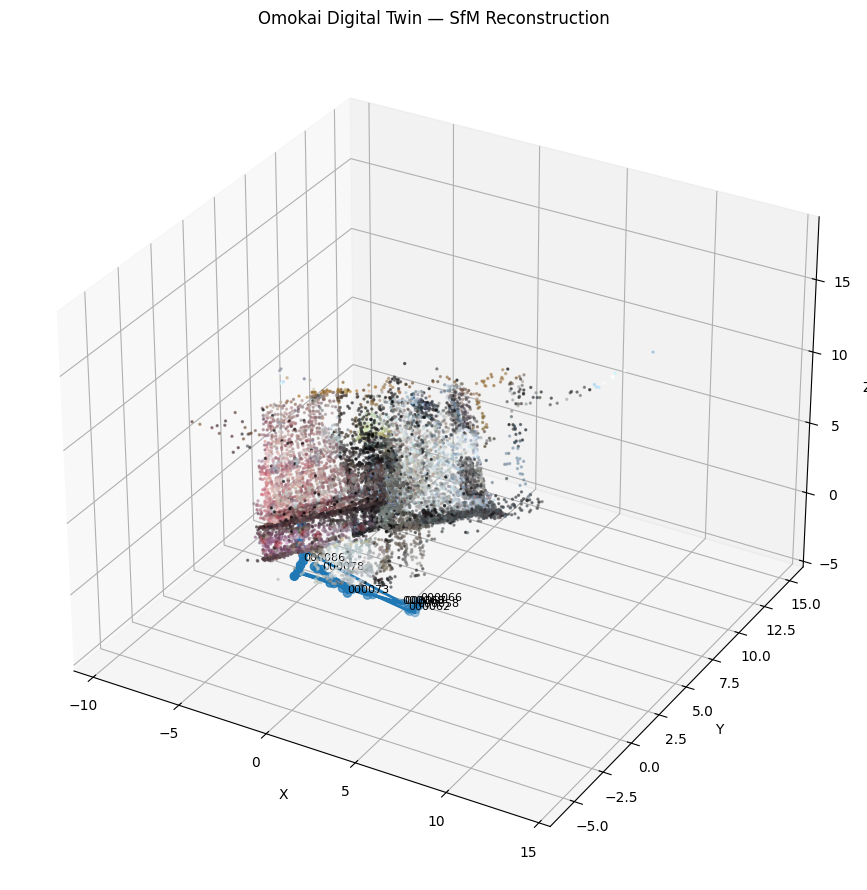


DIGITAL TWIN PREVIEW
3D points: 12909
Camera positions: 41


In [ ]:
# ============================================================
# STEP 31 — Colab-safe Digital Twin Preview
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# ------------------------------------------------------------
# Reconstructed 3D points
# ------------------------------------------------------------
points = np.array([
    np.asarray(p.xyz)
    for p in model_55_95.points3D.values()
])

colors = np.array([
    np.asarray(p.color) / 255.0
    for p in model_55_95.points3D.values()
])

# ------------------------------------------------------------
# Camera centers
# ------------------------------------------------------------
camera_centers = []
camera_names = []

for image in model_55_95.images.values():

    world_from_camera = (
        image.cam_from_world().inverse()
    )

    center = np.asarray(
        world_from_camera.translation
    )

    camera_centers.append(center)
    camera_names.append(image.name)

camera_centers = np.asarray(
    camera_centers
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig = plt.figure(
    figsize=(12, 9)
)

ax = fig.add_subplot(
    111,
    projection="3d"
)

# Reconstructed room
ax.scatter(
    points[:, 0],
    points[:, 1],
    points[:, 2],
    c=colors,
    s=2,
    alpha=0.55
)

# Camera trajectory
ax.plot(
    camera_centers[:, 0],
    camera_centers[:, 1],
    camera_centers[:, 2],
    linewidth=2
)

# Camera positions
ax.scatter(
    camera_centers[:, 0],
    camera_centers[:, 1],
    camera_centers[:, 2],
    s=35
)

# Label every 5th camera
for i in range(
    0,
    len(camera_centers),
    5
):

    ax.text(
        camera_centers[i, 0],
        camera_centers[i, 1],
        camera_centers[i, 2],
        camera_names[i].replace(
            ".jpg",
            ""
        ),
        fontsize=8
    )

ax.set_title(
    "Omokai Digital Twin — SfM Reconstruction"
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.tight_layout()

display(fig)
plt.close(fig)

print()
print("=" * 80)
print("DIGITAL TWIN PREVIEW")
print("=" * 80)
print("3D points:", len(points))
print("Camera positions:", len(camera_centers))

In [ ]:
# ============================================================
# STEP 32 — Locate the original Gaussian-Splat Digital Twin
# ============================================================

from pathlib import Path

DRIVE_ROOM = Path(
    "/content/drive/MyDrive/Omokai/digital_twin/room_001"
)

print("=" * 80)
print("ORIGINAL PHONE RECONSTRUCTION")
print("=" * 80)

for path in sorted(
    DRIVE_ROOM.rglob("*")
):

    if path.is_file():

        size_mb = path.stat().st_size / (1024 * 1024)

        print(
            f"{size_mb:8.2f} MB   {path.relative_to(DRIVE_ROOM)}"
        )

ORIGINAL PHONE RECONSTRUCTION
  149.42 MB   hloc/feats-superpoint-n4096-rmax1600.h5
    7.07 MB   hloc/matches-superglue.h5
    3.28 MB   hloc/matches-verified-opencv.h5
    0.02 MB   hloc/pairs-sequential.txt
    0.28 MB   images/000000.jpg
    0.28 MB   images/000001.jpg
    0.29 MB   images/000002.jpg
    0.29 MB   images/000003.jpg
    0.31 MB   images/000004.jpg
    0.32 MB   images/000005.jpg
    0.31 MB   images/000006.jpg
    0.29 MB   images/000007.jpg
    0.29 MB   images/000008.jpg
    0.28 MB   images/000009.jpg
    0.29 MB   images/000010.jpg
    0.31 MB   images/000011.jpg
    0.35 MB   images/000012.jpg
    0.43 MB   images/000013.jpg
    0.42 MB   images/000014.jpg
    0.44 MB   images/000015.jpg
    0.50 MB   images/000016.jpg
    0.51 MB   images/000017.jpg
    0.51 MB   images/000018.jpg
    0.50 MB   images/000019.jpg
    0.50 MB   images/000020.jpg
    0.48 MB   images/000021.jpg
    0.46 MB   images/000022.jpg
    0.38 MB   images/000023.jpg
    0.37 MB   images/0

In [ ]:
# ============================================================
# STEP 33 — Load the actual Gaussian-Splat Digital Twin
# ============================================================

from pathlib import Path
import shutil

DRIVE_SPLAT = Path(
    "/content/drive/MyDrive/Omokai/digital_twin/room_001/splat/rumahku_6000.ply"
)

LOCAL_SPLAT_DIR = Path(
    "/content/room_001/splat"
)

LOCAL_SPLAT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

LOCAL_SPLAT = (
    LOCAL_SPLAT_DIR /
    "rumahku_6000.ply"
)

print("=" * 80)
print("GAUSSIAN-SPLAT DIGITAL TWIN")
print("=" * 80)

# ------------------------------------------------------------
# Verify Drive file
# ------------------------------------------------------------
if not DRIVE_SPLAT.exists():

    raise FileNotFoundError(
        f"Gaussian-splat file not found:\n{DRIVE_SPLAT}"
    )

size_mb = (
    DRIVE_SPLAT.stat().st_size
    / (1024 * 1024)
)

print(
    f"Drive file found: {size_mb:.2f} MB"
)

# ------------------------------------------------------------
# Copy to local Colab storage
# ------------------------------------------------------------
shutil.copy2(
    DRIVE_SPLAT,
    LOCAL_SPLAT
)

print(
    f"Local copy: {LOCAL_SPLAT}"
)

# ------------------------------------------------------------
# Inspect PLY header
# ------------------------------------------------------------
print()
print("=" * 80)
print("PLY HEADER")
print("=" * 80)

with open(
    LOCAL_SPLAT,
    "rb"
) as f:

    header_lines = []

    while True:

        line = f.readline()

        if not line:
            break

        decoded = line.decode(
            "ascii",
            errors="replace"
        ).rstrip()

        header_lines.append(
            decoded
        )

        if decoded == "end_header":
            break

for line in header_lines:
    print(line)

# ------------------------------------------------------------
# Basic Gaussian-property check
# ------------------------------------------------------------
header_text = "\n".join(
    header_lines
)

print()
print("=" * 80)
print("CHECK")
print("=" * 80)

checks = {
    "Gaussian position": (
        "property float x" in header_text
        and
        "property float y" in header_text
        and
        "property float z" in header_text
    ),

    "Scale parameters": (
        "scale_0" in header_text
        or "scale_1" in header_text
        or "scale_2" in header_text
    ),

    "Rotation parameters": (
        "rot_0" in header_text
        or "rot_1" in header_text
        or "rot_2" in header_text
    ),

    "Opacity": (
        "opacity" in header_text
    ),
}

for name, status in checks.items():

    print(
        f"{'YES' if status else 'NO ':3}  {name}"
    )

print()
print(
    "The dense Gaussian-splat file is ready."
)

GAUSSIAN-SPLAT DIGITAL TWIN
Drive file found: 65.65 MB
Local copy: /content/room_001/splat/rumahku_6000.ply

PLY HEADER
ply
format binary_little_endian 1.0
comment Exported from Brush
comment Vertical axis: -0.069276564 -0.98144764 0.17877707
comment SH degree: 3
comment SplatRenderMode: default
element vertex 291685
property float x
property float y
property float z
property float scale_0
property float scale_1
property float scale_2
property float opacity
property float rot_0
property float rot_1
property float rot_2
property float rot_3
property float f_dc_0
property float f_dc_1
property float f_dc_2
property float f_rest_0
property float f_rest_1
property float f_rest_2
property float f_rest_3
property float f_rest_4
property float f_rest_5
property float f_rest_6
property float f_rest_7
property float f_rest_8
property float f_rest_9
property float f_rest_10
property float f_rest_11
property float f_rest_12
property float f_rest_13
property float f_rest_14
property float f_rest_1

In [ ]:
# ============================================================
# STEP 34 — Check GPU for Gaussian-Splat Rendering
# ============================================================

import torch

print("=" * 80)
print("GAUSSIAN-SPLAT RENDERING ENVIRONMENT")
print("=" * 80)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():

    print("GPU:", torch.cuda.get_device_name(0))

    props = torch.cuda.get_device_properties(0)

    print(
        "VRAM:",
        round(props.total_memory / (1024 ** 3), 2),
        "GB"
    )

else:

    print()
    print("WARNING: No CUDA GPU detected.")
    print("Do not install/render the Gaussian model yet.")

GAUSSIAN-SPLAT RENDERING ENVIRONMENT
PyTorch version: 2.11.0+cu130
CUDA available: True
GPU: Tesla T4
VRAM: 14.56 GB


In [ ]:
# ============================================================
# STEP 35 — Install Gaussian-Splat Renderer
# ============================================================

!pip -q install gsplat plyfile

import torch
import gsplat
import plyfile

print("=" * 80)
print("GAUSSIAN-SPLAT RENDERER")
print("=" * 80)

print("gsplat version:", getattr(gsplat, "__version__", "installed"))
print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

print()
print("Gaussian renderer ready.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 85.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.4/183.4 kB 18.5 MB/s eta 0:00:00
GAUSSIAN-SPLAT RENDERER
gsplat version: 1.5.3
PyTorch: 2.11.0+cu130
CUDA: True
GPU: Tesla T4

Gaussian renderer ready.


In [ ]:
# ============================================================
# STEP 36 — Load Gaussian-Splat Scene
# ============================================================

import numpy as np
import torch
from plyfile import PlyData

PLY_PATH = "/content/room_001/splat/rumahku_6000.ply"

print("=" * 80)
print("LOADING GAUSSIAN-SPLAT SCENE")
print("=" * 80)

# ------------------------------------------------------------
# Read binary PLY
# ------------------------------------------------------------
ply = PlyData.read(
    PLY_PATH
)

vertex = ply["vertex"]

N = len(vertex)

print("Gaussians:", N)

# ------------------------------------------------------------
# Position
# ------------------------------------------------------------
means = np.stack([
    vertex["x"],
    vertex["y"],
    vertex["z"]
], axis=1).astype(
    np.float32
)

# ------------------------------------------------------------
# Gaussian scale
# Brush stores logarithmic scales.
# ------------------------------------------------------------
scales = np.stack([
    vertex["scale_0"],
    vertex["scale_1"],
    vertex["scale_2"]
], axis=1).astype(
    np.float32
)

# ------------------------------------------------------------
# Rotation quaternion
# ------------------------------------------------------------
quats = np.stack([
    vertex["rot_0"],
    vertex["rot_1"],
    vertex["rot_2"],
    vertex["rot_3"]
], axis=1).astype(
    np.float32
)

# ------------------------------------------------------------
# Opacity
# Brush stores opacity in logit form.
# ------------------------------------------------------------
opacities = np.asarray(
    vertex["opacity"],
    dtype=np.float32
)

# ------------------------------------------------------------
# Spherical harmonics
# ------------------------------------------------------------
sh_dc = np.stack([
    vertex["f_dc_0"],
    vertex["f_dc_1"],
    vertex["f_dc_2"]
], axis=1).astype(
    np.float32
)

# Remaining SH coefficients
sh_rest = np.stack([
    vertex[f"f_rest_{i}"]
    for i in range(45)
], axis=1).astype(
    np.float32
)

# ------------------------------------------------------------
# Move to GPU
# ------------------------------------------------------------
device = "cuda"

means = torch.from_numpy(
    means
).to(device)

scales = torch.from_numpy(
    scales
).to(device)

quats = torch.from_numpy(
    quats
).to(device)

opacities = torch.from_numpy(
    opacities
).to(device)

sh_dc = torch.from_numpy(
    sh_dc
).to(device)

sh_rest = torch.from_numpy(
    sh_rest
).to(device)

# ------------------------------------------------------------
# Print tensors
# ------------------------------------------------------------
print()
print("=" * 80)
print("SCENE LOADED")
print("=" * 80)

print(
    "means:",
    tuple(means.shape)
)

print(
    "scales:",
    tuple(scales.shape)
)

print(
    "quats:",
    tuple(quats.shape)
)

print(
    "opacities:",
    tuple(opacities.shape)
)

print(
    "SH DC:",
    tuple(sh_dc.shape)
)

print(
    "SH rest:",
    tuple(sh_rest.shape)
)

print()
print(
    "GPU memory allocated:",
    round(
        torch.cuda.memory_allocated() /
        (1024 ** 3),
        3
    ),
    "GB"
)

print()
print("Gaussian scene loaded successfully.")

LOADING GAUSSIAN-SPLAT SCENE
Gaussians: 291685

SCENE LOADED
means: (291685, 3)
scales: (291685, 3)
quats: (291685, 4)
opacities: (291685,)
SH DC: (291685, 3)
SH rest: (291685, 45)

GPU memory allocated: 0.064 GB

Gaussian scene loaded successfully.


In [ ]:
# ============================================================
# STEP 37 — Load a Real Capture Camera Pose
#
# We will use frame 75 because it is inside our reliable
# localization/SfM segment.
# ============================================================

import json
import numpy as np
from pathlib import Path

TRANSFORMS = Path(
    "/content/room_001/transforms.json"
)

with open(TRANSFORMS, "r") as f:
    transforms = json.load(f)

frames = transforms["frames"]

# ------------------------------------------------------------
# Find frame 75
# ------------------------------------------------------------
frame = next(
    f for f in frames
    if Path(f["file_path"]).name == "000075.jpg"
    or f["file_path"].endswith("000075.jpg")
)

camera_to_world = np.asarray(
    frame["transform_matrix"],
    dtype=np.float32
)

# ------------------------------------------------------------
# Intrinsics
# ------------------------------------------------------------
fx = float(transforms["fl_x"])
fy = float(transforms["fl_y"])
cx = float(transforms["cx"])
cy = float(transforms["cy"])

width = int(transforms["w"])
height = int(transforms["h"])

print("=" * 80)
print("REFERENCE CAMERA")
print("=" * 80)

print("Frame:", "000075.jpg")

print(
    "Image size:",
    width,
    "x",
    height
)

print()
print("Intrinsics:")
print(
    "fx =", fx,
    "fy =", fy,
    "cx =", cx,
    "cy =", cy
)

print()
print("Camera-to-world:")
print(camera_to_world)

# ------------------------------------------------------------
# Camera center
# ------------------------------------------------------------
camera_center = camera_to_world[:3, 3]

print()
print(
    "Camera center:",
    camera_center
)

# ------------------------------------------------------------
# Original photograph
# ------------------------------------------------------------
IMAGE_PATH = (
    Path("/content/room_001/images")
    / "000075.jpg"
)

print()
print(
    "Original image exists:",
    IMAGE_PATH.exists()
)

print()
print(
    "Ready to render the digital twin from this viewpoint."
)

REFERENCE CAMERA
Frame: 000075.jpg
Image size: 1920 x 1080

Intrinsics:
fx = 1382.9617919921875 fy = 1379.8028564453125 cx = 962.8452758789062 cy = 545.3877563476562

Camera-to-world:
[[-0.11324072  0.96450084 -0.23856775  1.5037746 ]
 [-0.8483189   0.03114074  0.52856904  0.24709764]
 [ 0.51723444  0.2622372   0.81467795  0.6120429 ]
 [ 0.          0.          0.          1.        ]]

Camera center: [1.5037746  0.24709764 0.6120429 ]

Original image exists: True

Ready to render the digital twin from this viewpoint.


RENDERING DIGITAL TWIN
Gaussians: 291685
Resolution: 960 x 540
Rendering...


Output()

gsplat: CUDA extension has been set up successfully in 864.29 seconds.

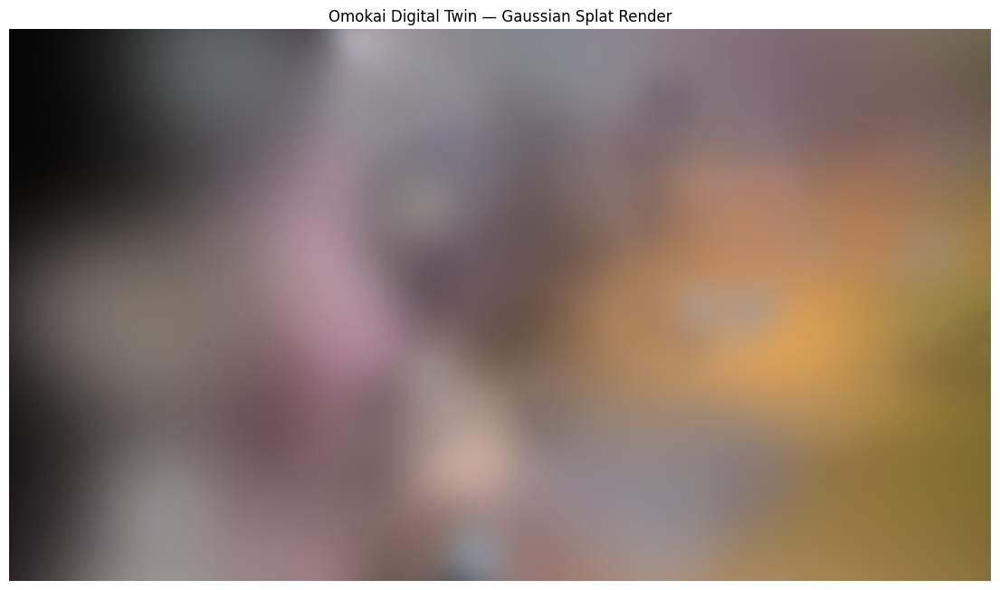


RENDER COMPLETE
RGB shape: (540, 960, 3)
Alpha min/max: 0.030480384826660156 0.9998999834060669
Mean alpha: 0.8543094992637634


In [ ]:
# ============================================================
# STEP 38 — Render Gaussian-Splat Digital Twin
# ============================================================

import torch
import numpy as np
import matplotlib.pyplot as plt
from gsplat import rasterization

# ------------------------------------------------------------
# Render resolution
#
# Start smaller than the original 1920x1080 to keep the T4
# comfortable. The geometry is unchanged.
# ------------------------------------------------------------
render_w = 960
render_h = 540

device = means.device

# ------------------------------------------------------------
# Camera intrinsics scaled to render resolution
# ------------------------------------------------------------
scale_x = render_w / width
scale_y = render_h / height

K = torch.tensor(
    [
        [fx * scale_x, 0.0, cx * scale_x],
        [0.0, fy * scale_y, cy * scale_y],
        [0.0, 0.0, 1.0],
    ],
    dtype=torch.float32,
    device=device
)

# ------------------------------------------------------------
# Convert camera-to-world into world-to-camera.
#
# gsplat expects view matrices as world -> camera.
# ------------------------------------------------------------
c2w = torch.tensor(
    camera_to_world,
    dtype=torch.float32,
    device=device
)

viewmat = torch.linalg.inv(
    c2w
).unsqueeze(0)

K_batch = K.unsqueeze(0)

# ------------------------------------------------------------
# Gaussian parameters
# ------------------------------------------------------------
N = means.shape[0]

# Brush stores logarithmic scale.
scales_linear = torch.exp(
    scales
)

# Brush stores opacity as logits.
opacity = torch.sigmoid(
    opacities
)

# ------------------------------------------------------------
# Normalize quaternions
# ------------------------------------------------------------
quats_normalized = (
    quats /
    torch.linalg.norm(
        quats,
        dim=1,
        keepdim=True
    ).clamp_min(1e-8)
)

# ------------------------------------------------------------
# Convert spherical harmonics into gsplat format.
#
# DC + 45 remaining coefficients = degree 3.
# 16 SH coefficients × 3 color channels.
# ------------------------------------------------------------
sh = torch.cat(
    [
        sh_dc.unsqueeze(1),
        sh_rest.reshape(
            N,
            15,
            3
        )
    ],
    dim=1
)

# ------------------------------------------------------------
# gsplat rasterization
# ------------------------------------------------------------
print("=" * 80)
print("RENDERING DIGITAL TWIN")
print("=" * 80)

print(
    "Gaussians:",
    N
)

print(
    "Resolution:",
    render_w,
    "x",
    render_h
)

print("Rendering...")

with torch.no_grad():

    renders, alphas, meta = rasterization(
        means=means,
        quats=quats_normalized,
        scales=scales_linear,
        opacities=opacity,
        colors=sh,
        viewmats=viewmat,
        Ks=K_batch,
        width=render_w,
        height=render_h,
        sh_degree=3,
    )

# ------------------------------------------------------------
# Extract RGB image
# ------------------------------------------------------------
render = renders[0]

render = torch.clamp(
    render,
    0.0,
    1.0
)

render_np = (
    render
    .detach()
    .cpu()
    .numpy()
)

# ------------------------------------------------------------
# Alpha
# ------------------------------------------------------------
alpha_np = (
    alphas[0]
    .detach()
    .cpu()
    .numpy()
)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------
plt.figure(
    figsize=(14, 8)
)

plt.imshow(
    render_np
)

plt.axis("off")

plt.title(
    "Omokai Digital Twin — Gaussian Splat Render"
)

plt.show()

# ------------------------------------------------------------
# Render statistics
# ------------------------------------------------------------
print()
print("=" * 80)
print("RENDER COMPLETE")
print("=" * 80)

print(
    "RGB shape:",
    render_np.shape
)

print(
    "Alpha min/max:",
    float(alpha_np.min()),
    float(alpha_np.max())
)

print(
    "Mean alpha:",
    float(alpha_np.mean())
)

RENDERING WITH CORRECTED CAMERA AXES


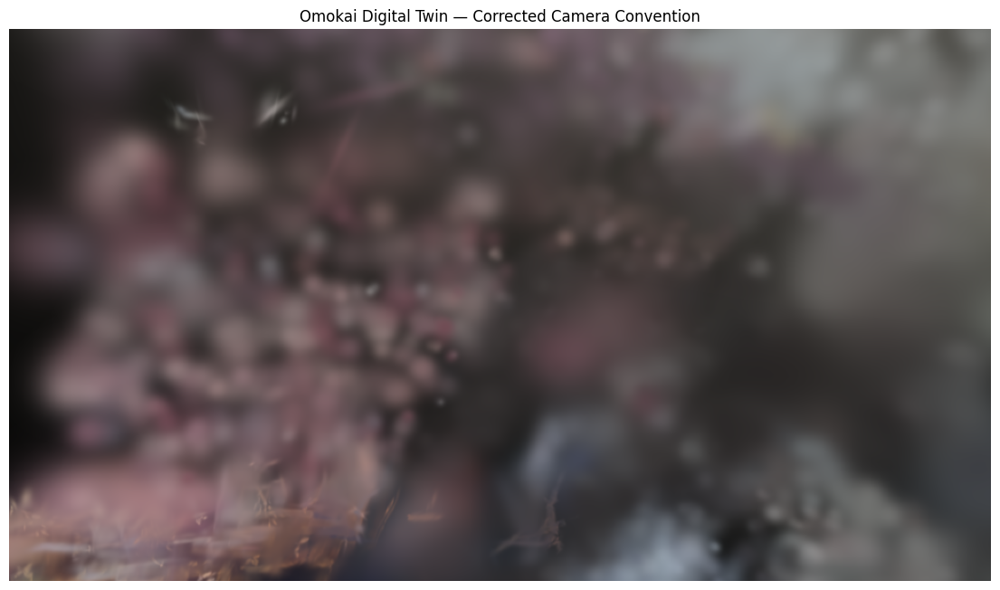


Mean alpha: 0.7533473968505859
Alpha range: 0.05795586109161377 to 0.9998998641967773


In [ ]:
# ============================================================
# STEP 39 — Correct NeRF/OpenGL -> OpenCV Camera Convention
# ============================================================

import torch
import matplotlib.pyplot as plt
from gsplat import rasterization

# NeRF-style camera coordinates:
#   X = right
#   Y = up
#   Z = backward
#
# gsplat/OpenCV-style camera coordinates:
#   X = right
#   Y = down
#   Z = forward
#
# Therefore flip Y and Z in the camera coordinate system.

opencv_from_nerf = torch.tensor(
    [
        [1.0,  0.0,  0.0, 0.0],
        [0.0, -1.0,  0.0, 0.0],
        [0.0,  0.0, -1.0, 0.0],
        [0.0,  0.0,  0.0, 1.0],
    ],
    dtype=torch.float32,
    device=means.device,
)

c2w_nerf = torch.tensor(
    camera_to_world,
    dtype=torch.float32,
    device=means.device,
)

# Convert camera-to-world pose to OpenCV convention
c2w_opencv = c2w_nerf @ opencv_from_nerf

# gsplat wants world -> camera
viewmat_corrected = torch.linalg.inv(
    c2w_opencv
).unsqueeze(0)

# Intrinsics from previous step
K_batch = K.unsqueeze(0)

print("=" * 80)
print("RENDERING WITH CORRECTED CAMERA AXES")
print("=" * 80)

with torch.no_grad():

    renders_corrected, alphas_corrected, meta_corrected = rasterization(
        means=means,
        quats=quats_normalized,
        scales=scales_linear,
        opacities=opacity,
        colors=sh,
        viewmats=viewmat_corrected,
        Ks=K_batch,
        width=render_w,
        height=render_h,
        sh_degree=3,
    )

render_corrected = torch.clamp(
    renders_corrected[0],
    0.0,
    1.0
)

render_corrected_np = (
    render_corrected
    .detach()
    .cpu()
    .numpy()
)

alpha_corrected_np = (
    alphas_corrected[0]
    .detach()
    .cpu()
    .numpy()
)

plt.figure(figsize=(14, 8))
plt.imshow(render_corrected_np)
plt.axis("off")
plt.title("Omokai Digital Twin — Corrected Camera Convention")
plt.show()

print()
print("Mean alpha:", float(alpha_corrected_np.mean()))
print(
    "Alpha range:",
    float(alpha_corrected_np.min()),
    "to",
    float(alpha_corrected_np.max())
)

In [ ]:
# ============================================================
# STEP 40 — Diagnose Gaussian / Camera Coordinate Alignment
# ============================================================

import torch
import numpy as np

print("=" * 80)
print("GAUSSIAN SCENE vs CAMERA ALIGNMENT")
print("=" * 80)

# ------------------------------------------------------------
# Gaussian position statistics
# ------------------------------------------------------------
xyz = means.detach().float()

xyz_min = xyz.min(dim=0).values.cpu().numpy()
xyz_max = xyz.max(dim=0).values.cpu().numpy()
xyz_mean = xyz.mean(dim=0).cpu().numpy()
xyz_median = xyz.median(dim=0).values.cpu().numpy()

print("\nGaussian position bounds:")
print("  min   :", xyz_min)
print("  max   :", xyz_max)
print("  mean  :", xyz_mean)
print("  median:", xyz_median)

print("\nGaussian scene extent:")
print(xyz_max - xyz_min)

# ------------------------------------------------------------
# Useful percentile bounds
# Avoid a few extreme Gaussians dominating the estimate.
# ------------------------------------------------------------
xyz_np = xyz.cpu().numpy()

p01 = np.percentile(xyz_np, 1, axis=0)
p99 = np.percentile(xyz_np, 99, axis=0)

print("\n1%-99% Gaussian bounds:")
print("  1% :", p01)
print(" 99% :", p99)
print("extent:", p99 - p01)

# ------------------------------------------------------------
# Camera position from transforms.json
# ------------------------------------------------------------
camera_pos = np.asarray(
    camera_to_world[:3, 3],
    dtype=np.float32
)

print("\nReference camera position:")
print(camera_pos)

# ------------------------------------------------------------
# Distance from camera to Gaussian centroid
# ------------------------------------------------------------
dist_centroid = np.linalg.norm(
    camera_pos - xyz_mean
)

dist_median = np.linalg.norm(
    camera_pos - xyz_median
)

print("\nCamera distance:")
print("  to Gaussian mean  :", dist_centroid)
print("  to Gaussian median:", dist_median)

# ------------------------------------------------------------
# Gaussian scale statistics
# ------------------------------------------------------------
scale_np = scales.detach().float().cpu().numpy()

linear_scale = np.exp(
    np.clip(scale_np, -20, 20)
)

print("\nGaussian linear scale statistics:")
print(
    "  median:",
    np.median(linear_scale, axis=0)
)

print(
    "  mean  :",
    np.mean(linear_scale, axis=0)
)

print(
    "  max   :",
    np.max(linear_scale, axis=0)
)

# ------------------------------------------------------------
# Opacity statistics
# ------------------------------------------------------------
opacity_np = torch.sigmoid(
    opacities
).detach().cpu().numpy()

print("\nOpacity statistics:")
print(
    "  median:",
    np.median(opacity_np)
)

print(
    "  >0.5 :",
    np.mean(opacity_np > 0.5) * 100,
    "%"
)

print(
    "  >0.9 :",
    np.mean(opacity_np > 0.9) * 100,
    "%"
)

# ------------------------------------------------------------
# Coordinate magnitude comparison
# ------------------------------------------------------------
print("\nCoordinate magnitude:")
print(
    "  Gaussian median |xyz|:",
    np.median(np.linalg.norm(xyz_np, axis=1))
)

print(
    "  Gaussian 95% |xyz|:",
    np.percentile(
        np.linalg.norm(xyz_np, axis=1),
        95
    )
)

print(
    "  Camera |xyz|:",
    np.linalg.norm(camera_pos)
)

print("\n" + "=" * 80)
print("DIAGNOSTIC COMPLETE")
print("=" * 80)

GAUSSIAN SCENE vs CAMERA ALIGNMENT

Gaussian position bounds:
  min   : [-76.54399  -34.906822 -80.51652 ]
  max   : [49.688534 38.57746  71.84602 ]
  mean  : [-0.73954064 -0.20589113  1.9363942 ]
  median: [-0.40985623 -0.57812536  2.029601  ]

Gaussian scene extent:
[126.23253  73.48428 152.36255]

1%-99% Gaussian bounds:
  1% : [-6.0519414 -1.7098715 -1.7632546]
 99% : [1.5043869 2.546369  9.755182 ]
extent: [ 7.5563283  4.256241  11.518436 ]

Reference camera position:
[1.5037746  0.24709764 0.6120429 ]

Camera distance:
  to Gaussian mean  : 2.6441574
  to Gaussian median: 2.520406

Gaussian linear scale statistics:
  median: [0.00554936 0.00508055 0.00535857]
  mean  : [0.01815012 0.01771243 0.02000506]
  max   : [6.220969 6.076131 7.407109]

Opacity statistics:
  median: 0.1470812
  >0.5 : 9.420436429710133 %
  >0.9 : 0.6112758626600614 %

Coordinate magnitude:
  Gaussian median |xyz|: 2.4110718
  Gaussian 95% |xyz|: 3.8718102
  Camera |xyz|: 1.6422521

DIAGNOSTIC COMPLETE


In [ ]:
# ============================================================
# STEP 41 — Camera Frustum / Gaussian Depth Diagnostic
# ============================================================

import numpy as np
import torch

xyz = means.detach().float()

# Use only the useful central 1%-99% Gaussian volume.
xyz_np = xyz.cpu().numpy()

p01 = np.percentile(xyz_np, 1, axis=0)
p99 = np.percentile(xyz_np, 99, axis=0)

mask = np.all(
    (xyz_np >= p01) &
    (xyz_np <= p99),
    axis=1
)

scene_xyz = xyz[mask]

print("=" * 80)
print("CAMERA / GAUSSIAN DEPTH DIAGNOSTIC")
print("=" * 80)

print()
print("Useful Gaussians:", scene_xyz.shape[0])

# ------------------------------------------------------------
# Camera poses
# ------------------------------------------------------------
c2w = torch.tensor(
    camera_to_world,
    dtype=torch.float32,
    device=means.device
)

# Original camera convention
view_original = torch.linalg.inv(c2w)

# Corrected convention from previous experiment
axis_flip = torch.tensor(
    [
        [1., 0., 0., 0.],
        [0., -1., 0., 0.],
        [0., 0., -1., 0.],
        [0., 0., 0., 1.]
    ],
    dtype=torch.float32,
    device=means.device
)

c2w_corrected = c2w @ axis_flip
view_corrected = torch.linalg.inv(
    c2w_corrected
)

# ------------------------------------------------------------
# Transform Gaussian positions into camera coordinates
# ------------------------------------------------------------
def camera_depths(points, view):
    R = view[:3, :3]
    t = view[:3, 3]
    return points @ R.T + t

cam_original = camera_depths(
    scene_xyz,
    view_original
)

cam_corrected = camera_depths(
    scene_xyz,
    view_corrected
)

# ------------------------------------------------------------
# Print depth statistics
# ------------------------------------------------------------
for name, cam in [
    ("ORIGINAL", cam_original),
    ("CORRECTED", cam_corrected),
]:

    x = cam[:, 0].detach().cpu().numpy()
    y = cam[:, 1].detach().cpu().numpy()
    z = cam[:, 2].detach().cpu().numpy()

    print()
    print("-" * 70)
    print(name)
    print("-" * 70)

    print("Depth Z:")
    print("  min   :", np.min(z))
    print("  median:", np.median(z))
    print("  max   :", np.max(z))

    print()
    print("Points in front (Z > 0):")
    print(
        f"  {np.mean(z > 0) * 100:.2f}%"
    )

    print()
    print("Points at useful camera distances:")
    print(
        "  Z > 0.1 m :",
        f"{np.mean(z > 0.1) * 100:.2f}%"
    )
    print(
        "  Z > 0.5 m :",
        f"{np.mean(z > 0.5) * 100:.2f}%"
    )
    print(
        "  Z > 1.0 m :",
        f"{np.mean(z > 1.0) * 100:.2f}%"
    )

    # --------------------------------------------------------
    # Approximate field-of-view test
    # --------------------------------------------------------
    fx_r = fx * (render_w / width)
    fy_r = fy * (render_h / height)
    cx_r = cx * (render_w / width)
    cy_r = cy * (render_h / height)

    valid = z > 0.1

    u = fx_r * (x[valid] / z[valid]) + cx_r
    v = fy_r * (y[valid] / z[valid]) + cy_r

    inside = (
        (u >= 0) &
        (u < render_w) &
        (v >= 0) &
        (v < render_h)
    )

    print()
    print("Projected into 960×540 image:")
    print(
        "  visible projected Gaussians:",
        int(np.sum(inside))
    )
    print(
        "  percentage of useful scene:",
        f"{np.mean(inside) * 100:.2f}%"
    )

print()
print("=" * 80)
print("DIAGNOSTIC COMPLETE")
print("=" * 80)

CAMERA / GAUSSIAN DEPTH DIAGNOSTIC

Useful Gaussians: 280752

----------------------------------------------------------------------
ORIGINAL
----------------------------------------------------------------------
Depth Z:
  min   : -2.790463
  median: 1.3033812
  max   : 9.141205

Points in front (Z > 0):
  84.11%

Points at useful camera distances:
  Z > 0.1 m : 84.07%
  Z > 0.5 m : 83.44%
  Z > 1.0 m : 68.52%

Projected into 960×540 image:
  visible projected Gaussians: 15379
  percentage of useful scene: 6.52%

----------------------------------------------------------------------
CORRECTED
----------------------------------------------------------------------
Depth Z:
  min   : -9.141205
  median: -1.3033812
  max   : 2.790463

Points in front (Z > 0):
  15.89%

Points at useful camera distances:
  Z > 0.1 m : 15.75%
  Z > 0.5 m : 14.20%
  Z > 1.0 m : 12.72%

Projected into 960×540 image:
  visible projected Gaussians: 1415
  percentage of useful scene: 3.20%

DIAGNOSTIC COMPLETE


RENDERING WITH CORRECT SH ORDERING

SH tensor:
  DC : (291685, 1, 3)
  Rest: (291685, 15, 3)
  Full: (291685, 16, 3)

Rendering 960 × 540...


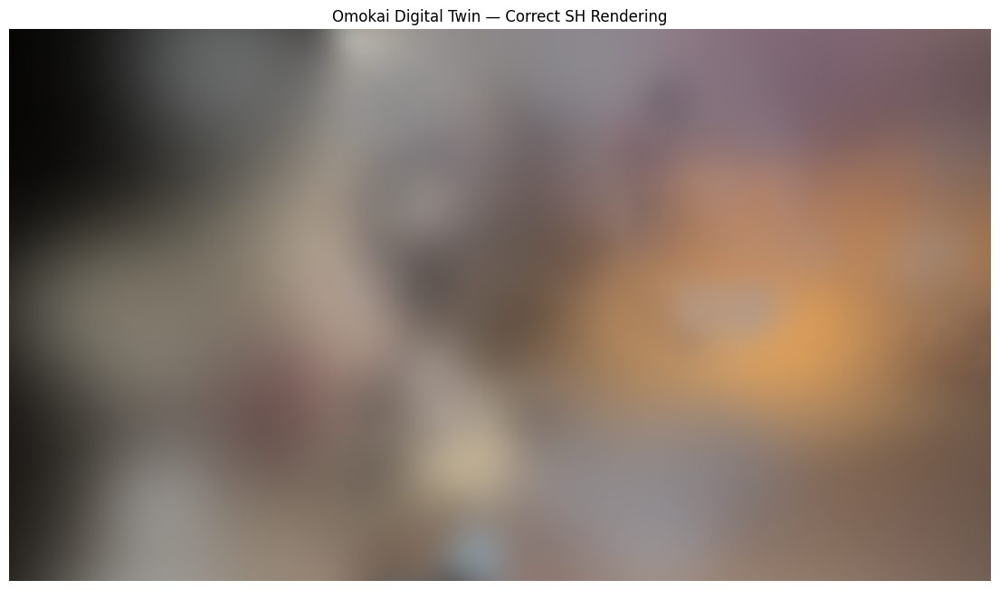


RENDER COMPLETE
Mean alpha: 0.8543094992637634
Visible alpha (>0.1): 98.12%


In [ ]:
# ============================================================
# STEP 42 — Correct Brush PLY SH Channel Ordering
# ============================================================

import torch
import matplotlib.pyplot as plt
from gsplat import rasterization

print("=" * 80)
print("RENDERING WITH CORRECT SH ORDERING")
print("=" * 80)

N = means.shape[0]

# ------------------------------------------------------------
# IMPORTANT:
# Brush / standard 3DGS PLY stores f_rest channel-major:
#
#   R0...R14, G0...G14, B0...B14
#
# gsplat expects:
#
#   coefficient 0: [R0,G0,B0]
#   coefficient 1: [R1,G1,B1]
#   ...
#
# ------------------------------------------------------------

f_rest_channel_major = sh_rest.reshape(
    N,
    3,
    15
)

f_rest_basis_major = (
    f_rest_channel_major
    .transpose(1, 2)
    .contiguous()
)

# DC coefficient
sh0 = sh_dc.unsqueeze(1)

# Complete degree-3 SH tensor
sh_correct = torch.cat(
    [
        sh0,
        f_rest_basis_major
    ],
    dim=1
)

print()
print("SH tensor:")
print("  DC :", tuple(sh0.shape))
print("  Rest:", tuple(f_rest_basis_major.shape))
print("  Full:", tuple(sh_correct.shape))

# ------------------------------------------------------------
# IMPORTANT:
# Use the ORIGINAL ARCore/OpenGL camera convention.
#
# rumahku explicitly records ARCore camera-to-world poses
# using OpenGL convention: +Y up, camera looks down -Z.
# ------------------------------------------------------------

c2w = torch.tensor(
    camera_to_world,
    dtype=torch.float32,
    device=means.device
)

viewmat = torch.linalg.inv(
    c2w
).unsqueeze(0)

# ------------------------------------------------------------
# Intrinsics
# ------------------------------------------------------------

K_batch = K.unsqueeze(0)

# ------------------------------------------------------------
# Render
# ------------------------------------------------------------

print()
print("Rendering 960 × 540...")

with torch.no_grad():

    renders_sh, alphas_sh, meta_sh = rasterization(
        means=means,
        quats=quats_normalized,
        scales=scales_linear,
        opacities=opacity,
        colors=sh_correct,
        viewmats=viewmat,
        Ks=K_batch,
        width=render_w,
        height=render_h,
        sh_degree=3,
    )

render_sh = torch.clamp(
    renders_sh[0],
    0.0,
    1.0
)

render_sh_np = (
    render_sh
    .detach()
    .cpu()
    .numpy()
)

alpha_sh_np = (
    alphas_sh[0]
    .detach()
    .cpu()
    .numpy()
)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

plt.figure(figsize=(14, 8))

plt.imshow(render_sh_np)

plt.axis("off")

plt.title(
    "Omokai Digital Twin — Correct SH Rendering"
)

plt.show()

print()
print("=" * 80)
print("RENDER COMPLETE")
print("=" * 80)

print(
    "Mean alpha:",
    float(alpha_sh_np.mean())
)

print(
    "Visible alpha (>0.1):",
    f"{(alpha_sh_np > 0.1).mean() * 100:.2f}%"
)

FILTERING EXTREME GAUSSIANS

Gaussian scale percentiles:
  P90.0: 0.039728988
  P95.0: 0.072466485
  P97.0: 0.120891616
  P98.0: 0.18889731
  P99.0: 0.33643287
  P99.5: 0.51654553
  P99.9: 1.978405

Scale cutoff: 0.5165455341339111
Original Gaussians: 291685
Filtered Gaussians: 288160
Removed: 3525

Rendering filtered scene...


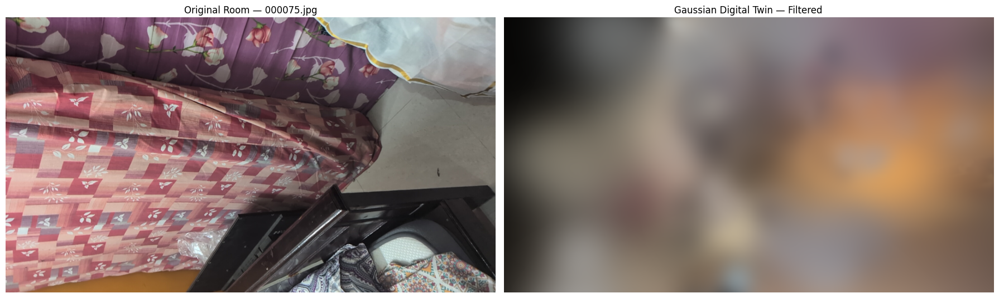


FILTERED RENDER COMPLETE
Mean alpha: 0.8514853119850159


In [ ]:
# ============================================================
# STEP 43 — Filter Extreme Gaussian Splats + Compare to Photo
# ============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from gsplat import rasterization

print("=" * 80)
print("FILTERING EXTREME GAUSSIANS")
print("=" * 80)

# ------------------------------------------------------------
# Convert log-scales to actual Gaussian sizes
# ------------------------------------------------------------
linear_scales = torch.exp(scales)

max_scale = linear_scales.max(dim=1).values

max_scale_np = max_scale.detach().cpu().numpy()

print()
print("Gaussian scale percentiles:")

for p in [90, 95, 97, 98, 99, 99.5, 99.9]:
    print(
        f"  P{p:4.1f}:",
        np.percentile(max_scale_np, p)
    )

# ------------------------------------------------------------
# Use the 99.5th percentile as an adaptive cutoff.
#
# This removes only the largest 0.5% of splats instead of
# arbitrarily deleting a large portion of the reconstruction.
# ------------------------------------------------------------
scale_cutoff = float(
    np.percentile(max_scale_np, 99.5)
)

opacity_values = torch.sigmoid(opacities)

mask = (
    (max_scale <= scale_cutoff) &
    (opacity_values > 0.01)
)

print()
print("Scale cutoff:", scale_cutoff)

print(
    "Original Gaussians:",
    means.shape[0]
)

print(
    "Filtered Gaussians:",
    int(mask.sum())
)

print(
    "Removed:",
    int((~mask).sum())
)

# ------------------------------------------------------------
# Apply filter
# ------------------------------------------------------------
means_f = means[mask]
scales_f = linear_scales[mask]
quats_f = quats_normalized[mask]
opacity_f = opacity_values[mask]
sh_f = sh_correct[mask]

# ------------------------------------------------------------
# Original ARCore / OpenGL camera convention
# ------------------------------------------------------------
c2w = torch.tensor(
    camera_to_world,
    dtype=torch.float32,
    device=means.device
)

viewmat = torch.linalg.inv(
    c2w
).unsqueeze(0)

# ------------------------------------------------------------
# Render
# ------------------------------------------------------------
print()
print("Rendering filtered scene...")

with torch.no_grad():

    renders_f, alphas_f, meta_f = rasterization(
        means=means_f,
        quats=quats_f,
        scales=scales_f,
        opacities=opacity_f,
        colors=sh_f,
        viewmats=viewmat,
        Ks=K_batch,
        width=render_w,
        height=render_h,
        sh_degree=3,
    )

render_f = torch.clamp(
    renders_f[0],
    0.0,
    1.0
)

render_f_np = (
    render_f
    .detach()
    .cpu()
    .numpy()
)

# ------------------------------------------------------------
# Load original photograph
# ------------------------------------------------------------
original = np.asarray(
    Image.open(
        "/content/room_001/images/000075.jpg"
    ).resize(
        (render_w, render_h)
    )
)

# ------------------------------------------------------------
# Side-by-side comparison
# ------------------------------------------------------------
fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 7)
)

axes[0].imshow(original)
axes[0].set_title(
    "Original Room — 000075.jpg"
)
axes[0].axis("off")

axes[1].imshow(render_f_np)
axes[1].set_title(
    "Gaussian Digital Twin — Filtered"
)
axes[1].axis("off")

plt.tight_layout()
plt.show()

print()
print("=" * 80)
print("FILTERED RENDER COMPLETE")
print("=" * 80)

print(
    "Mean alpha:",
    float(
        alphas_f[0].detach().cpu().mean()
    )
)

KNOWN-CAMERA GAUSSIAN TEST
Scene mean: [-0.73954064 -0.20589113  1.9363942 ]


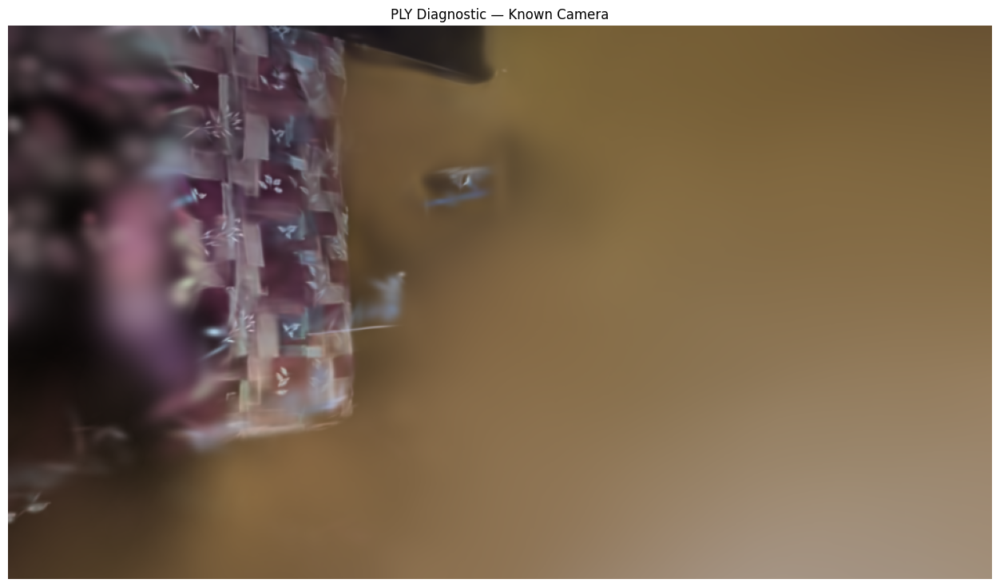


Mean alpha: 0.8407857418060303
Render range: 0.02391193062067032 to 0.8879718780517578

If this is STILL a smooth color wash,
the problem is almost certainly in the PLY/training output,
not the ARCore camera pose.


In [ ]:
# ============================================================
# STEP 44 — Render PLY From a Simple Known Camera
# ============================================================

import torch
import numpy as np
import matplotlib.pyplot as plt
from gsplat import rasterization

print("=" * 80)
print("KNOWN-CAMERA GAUSSIAN TEST")
print("=" * 80)

# Use the already-loaded Gaussian tensors.
# Put the camera near the center of the useful scene.

scene_mean = means.mean(dim=0)

print("Scene mean:", scene_mean.detach().cpu().numpy())

# Camera looking toward the scene mean.
camera_pos = torch.tensor(
    [0.0, 0.0, 0.0],
    dtype=torch.float32,
    device=means.device,
)

target = scene_mean

forward = target - camera_pos
forward = forward / torch.linalg.norm(forward)

# OpenGL-style camera basis:
# camera looks along -Z, +Y is up.
up_world = torch.tensor(
    [0.0, 1.0, 0.0],
    dtype=torch.float32,
    device=means.device,
)

right = torch.linalg.cross(forward, up_world)
right = right / torch.linalg.norm(right)

up = torch.linalg.cross(right, forward)
up = up / torch.linalg.norm(up)

# Camera-to-world rotation.
# Columns are camera right, up, and backward (-forward).
R = torch.stack(
    [right, up, -forward],
    dim=1,
)

c2w_test = torch.eye(4, dtype=torch.float32, device=means.device)
c2w_test[:3, :3] = R
c2w_test[:3, 3] = camera_pos

viewmat_test = torch.linalg.inv(c2w_test).unsqueeze(0)

render_w = 960
render_h = 540

# Simple focal length for this diagnostic.
fx_test = 700.0
fy_test = 700.0
cx_test = render_w / 2
cy_test = render_h / 2

K_test = torch.tensor(
    [[fx_test, 0, cx_test],
     [0, fy_test, cy_test],
     [0, 0, 1]],
    dtype=torch.float32,
    device=means.device,
).unsqueeze(0)

# Use correct SH ordering from Step 42.
with torch.no_grad():
    render_test, alpha_test, meta_test = rasterization(
        means=means,
        quats=quats_normalized,
        scales=torch.exp(scales),
        opacities=torch.sigmoid(opacities),
        colors=sh_correct,
        viewmats=viewmat_test,
        Ks=K_test,
        width=render_w,
        height=render_h,
        sh_degree=3,
        near_plane=0.01,
        far_plane=1000.0,
    )

img_test = torch.clamp(render_test[0], 0.0, 1.0)
img_test = img_test.detach().cpu().numpy()

plt.figure(figsize=(16, 9))
plt.imshow(img_test)
plt.title("PLY Diagnostic — Known Camera")
plt.axis("off")
plt.show()

print()
print("Mean alpha:", float(alpha_test.mean()))
print("Render range:", float(img_test.min()), "to", float(img_test.max()))
print()
print("If this is STILL a smooth color wash,")
print("the problem is almost certainly in the PLY/training output,")
print("not the ARCore camera pose.")

In [ ]:
# ============================================================
# STANDUP DEMO — LOCALIZATION PROTOTYPE SUMMARY
# ============================================================

import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

query_path = "/content/room_001/images/000054.jpg"

query_img = np.asarray(Image.open(query_path))

fig = plt.figure(figsize=(16, 9))

# ------------------------------------------------------------
# LEFT: Actual held-out phone frame
# ------------------------------------------------------------
ax1 = fig.add_axes([0.03, 0.18, 0.45, 0.68])
ax1.imshow(query_img)
ax1.set_title(
    "HELD-OUT PHONE FRAME\n000054.jpg",
    fontsize=18,
    fontweight="bold"
)
ax1.axis("off")

# ------------------------------------------------------------
# RIGHT: Results
# ------------------------------------------------------------
ax2 = fig.add_axes([0.54, 0.18, 0.43, 0.68])
ax2.axis("off")

results = [
    ("Room images captured", "152"),
    ("SfM map images", "41 / 41"),
    ("3D map points", "12,909"),
    ("Held-out query", "000054.jpg"),
    ("2D → 3D correspondences", "543"),
    ("PnP RANSAC inliers", "398"),
    ("PnP inlier ratio", "73.3%"),
    ("Mean reprojection error", "1.87 px"),
]

y = 0.93

for label, value in results:
    ax2.text(
        0.02, y,
        label,
        fontsize=14,
        va="center"
    )
    ax2.text(
        0.98, y,
        value,
        fontsize=15,
        fontweight="bold",
        ha="right",
        va="center"
    )

    ax2.plot(
        [0.02, 0.98],
        [y - 0.035, y - 0.035],
        linewidth=0.7,
        alpha=0.25
    )

    y -= 0.105

ax2.text(
    0.02, 0.04,
    "GPS-denied visual localization prototype",
    fontsize=17,
    fontweight="bold"
)

ax2.text(
    0.02, -0.015,
    "Phone image → visual map → 2D/3D matching → PnP pose",
    fontsize=12
)

fig.suptitle(
    "DIGITAL TWIN TRAINING SIMULATION — MILESTONE",
    fontsize=23,
    fontweight="bold"
)

plt.show()